##CONFIGURATION ENVIRONNEMENT

In [ ]:
 !pip install rasterio
 !pip install tensorflow==2.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.8/589.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.1
    Uninstalling tensorboard-2.17.1:
      Successfully uninstalled tensorboard-2.17.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.17.1
    Uninstalling tensorflow-2.17.1:
      Successfully uninstalled tensorflow-2.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf

In [ ]:
import os
import pickle
import rasterio
import numpy as np
import seaborn as sns
import tensorflow as tf
import geopandas as gpd
import ipywidgets as widgets
from google.colab import drive
from google.colab import files
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from tensorflow.keras.models import Model
from rasterio.features import geometry_mask
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
from IPython.display import display, clear_output
from tensorflow.keras.initializers import HeNormal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model, backend as K
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Input, BatchNormalization, UpSampling2D, Layer, Multiply, Add, Activation

##IMPORT DES DATA

Import des images au format ".tif" et des masks au format ".geojson"  
Séparation des images et des masks dans deux dictionnaires en les stockant
dans le meme ordre (image de l'année X au même rang que le mask de l'année X)

In [ ]:
# Chemins d'accès aux dossiers contenant les fichiers
path_data = [os.path.join('..', 'data', 'dataset')]

In [ ]:
def import_fichier(paths):
    # Dictionnaires pour stocker les fichiers .tif et .geojson par nom de base
    tif_files = {}
    geojson_files = {}

    # Récupération de tous les fichiers .tif et .geojson
    for path in paths:
        for file_name in os.listdir(path):
            full_path = os.path.join(path, file_name)
            base_name, ext = os.path.splitext(file_name)
            if ext == '.tif':
                tif_files[base_name] = full_path
            elif ext == '.geojson':
                geojson_files[base_name] = full_path

    # Associer les fichiers .tif et .geojson ayant le même nom de base
    paired_files = [
        (tif_files[base_name], geojson_files[base_name])
        for base_name in tif_files.keys() & geojson_files.keys()
    ]

    # Chargement des fichiers GeoJSON et TIFF
    geo_dfs = [(gpd.read_file(geojson_file), geojson_file) for _, geojson_file in paired_files]
    raster_data = [(rasterio.open(tif_file), tif_file) for tif_file, _ in paired_files]

    # Affichage des informations
    print(f"Nombre de paires TIFF-GEOJSON chargées: {len(paired_files)}")

  return paired_files, geo_dfs, raster_data

In [ ]:
paired_files, geo_dfs, raster_data = import_fichier(paths_p)

Nombre de paires TIFF-GEOJSON chargées: 108


Fonction pour connaitre le nombre de classe dans les mask (5 ou 6)

In [ ]:
def geojson_to_numpy_masks_and_find_max(geo_dfs, raster_data):
    max_value = 0  # Initialiser la valeur maximale

    for (geo_df, _), (raster, _) in zip(geo_dfs, raster_data):
        Y_shape = (raster.height, raster.width)
        transform = raster.transform
        mask_full_image = np.full(Y_shape, fill_value=0, dtype=int)

        # Créer un masque global avec les annotations GeoJSON
        for _, row in geo_df.iterrows():
            geometry = row['geometry']
            if 'type' in row:
                label = row['type']
            elif 'Type' in row:
                label = row['Type']
            else:
                continue  # Ignore si ni "type" ni "Type" n'est trouvé

            mask = geometry_mask([geometry], transform=transform, invert=True, out_shape=Y_shape)
            if mask.any():
                mask_full_image[mask] = label  # Assigner l'étiquette du polygone

        # Mettre à jour la valeur maximale trouvée
        max_value = max(max_value, mask_full_image.max())

    return max_value

## DECLARATION DES VARIABLES & CREATION DU DATASET

In [ ]:
vmax = vmax = geojson_to_numpy_masks_and_find_max(geo_dfs, raster_data) #valeur maximal dans le label
if vmax == 5:
  colors = ['black', 'green', 'blue', 'yellow', 'gray', 'brown']
  echelle = ['Vide', 'Oasis', 'Eau', 'Sable', 'Montagne', 'Habitation']
  ticks = [0,1,2,3,4,5]
elif vmax == 6:
  colors = ['black', 'green', 'blue', 'yellow', 'gray', 'brown', 'white']
  echelle = ['Vide', 'Oasis', 'Eau', 'Sable', 'Montagne', 'Habitation', 'Vraie montagne']
  ticks = [0,1,2,3,4,5,6]
cmap = ListedColormap(colors)
bands = (4,3,5) # a changer selon sujet à mettre en avant lors du visionnage

In [ ]:
# variable pour la creation du dataset
batch_size = 15
validation_split = 0.12  # taille dataset validation

In [ ]:
# nb filtre
nb_filtre_1 = 64
nb_filtre_2 = nb_filtre_1*2
nb_filtre_3 = nb_filtre_2*2
nb_filtre_4 = nb_filtre_3*2

# kernel des filtres
kernel_1 = 5
kernel_2 = 5
kernel_3 = 5
kernel_4 = 5

# size of input & nb de classe
input_size = (104, 104, 7)  # Exemple de taille d'entrée (hauteur, largeur, canaux)
num_classes = 6#vmax+1  # Nombre de classes

##TRANSFORMATION DES DONNEES

In [ ]:
def generate_mask_for_image(src, X, Y_shape):
    transform = src.transform
    mask_full_image = np.full(Y_shape, fill_value=0, dtype=int)

    # Créer un masque global avec les annotations GeoJSON
    for _, row in X.iterrows():
        geometry = row['geometry']
        if 'type' in row:
            label = row['type']
        elif 'Type' in row:
            label = row['Type']
        else:
            continue  # Ignore si ni "type" ni "Type" n'est trouvé
        mask = geometry_mask([geometry], transform=transform, invert=True, out_shape=Y_shape)
        if mask.any():
            mask_full_image[mask] = label  # Assigner l'étiquette du polygone
    return mask_full_image

In [ ]:
def affichage_mask(geojson_file, tif_file,paired_files,image_label):
    # Charger les annotations GeoJSON et le raster
    #X = gpd.read_file(geojson_file)  # GeoJSON correspondant
    for i, (tif_file, geojson_file) in enumerate(paired_files):
        print(f"Traitement de l'image TIFF {i+1}...")

        # Charger les annotations GeoJSON et le raster
        X = gpd.read_file(geojson_file)  # GeoJSON correspondant
        with rasterio.open(tif_file) as dataset:
            Y_shape = dataset.shape  # Shape de l'image .tif (hauteur, largeur)

            # Générer le masque pour l'image actuelle
            mask_full_image = generate_mask_for_image(dataset, X, Y_shape)
            image_label.append(mask_full_image)

            # Lire les données raster pour affichage
            raster_image = dataset.read(1)  # Lecture de la première bande de l'image .tif

        # Afficher l'image raster et le masque côte à côte
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # Deux sous-graphes (1 ligne, 2 colonnes)

        # Affichage de l'image TIFF
        ax[0].imshow(raster_image, cmap='gray')
        ax[0].set_title(f'Image TIFF {i+1}')
        ax[0].axis('off')

        # Affichage du masque de segmentation avec les couleurs spécifiques
        im = ax[1].imshow(mask_full_image, cmap=cmap, vmin=0, vmax=vmax)
        ax[1].set_title(f'Masque de segmentation pour l\'image {i+1}')
        ax[1].axis('off')

        # Ajouter une barre de couleurs pour voir les classes dans le masque
        cbar = plt.colorbar(im, ax=ax[1], ticks=ticks)
        cbar.ax.set_yticklabels(echelle)

        # Afficher les deux images
        plt.show()
    return image_label

Traitement de l'image TIFF 1...


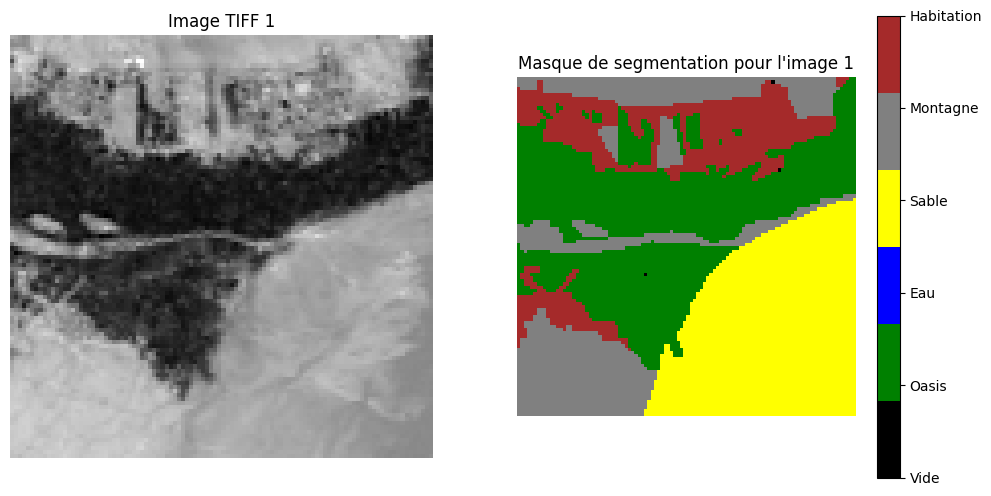

Traitement de l'image TIFF 2...


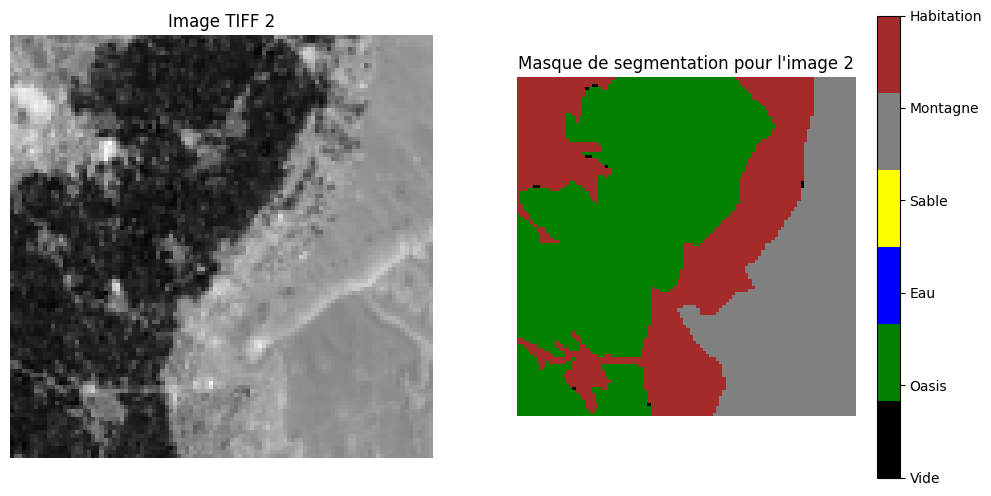

Traitement de l'image TIFF 3...


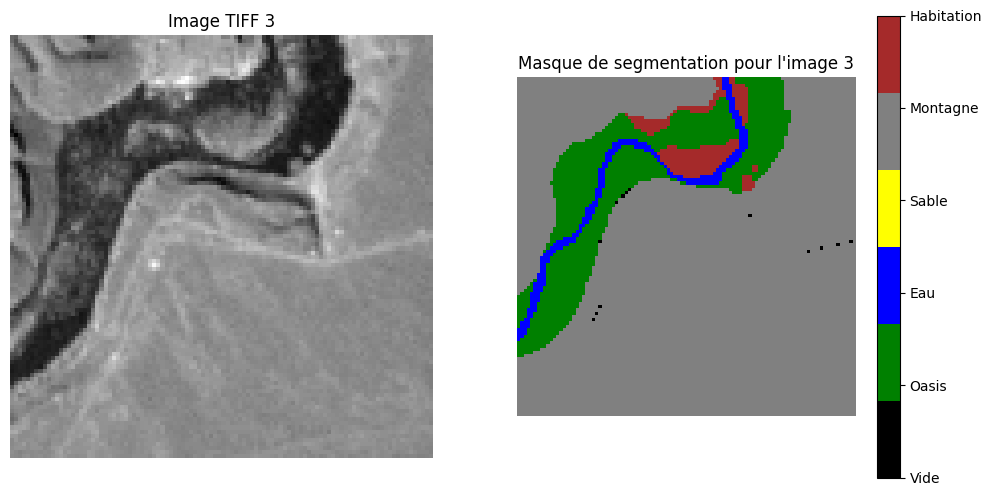

Traitement de l'image TIFF 4...


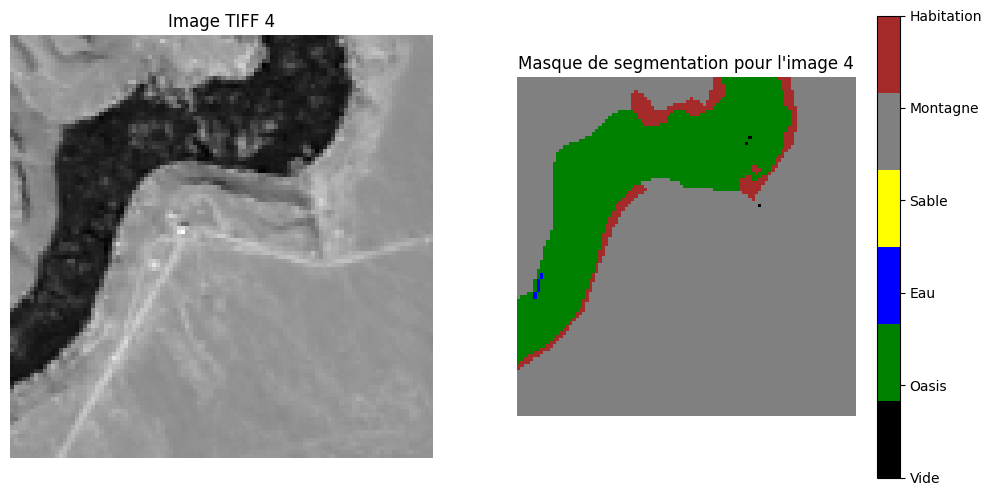

Traitement de l'image TIFF 5...


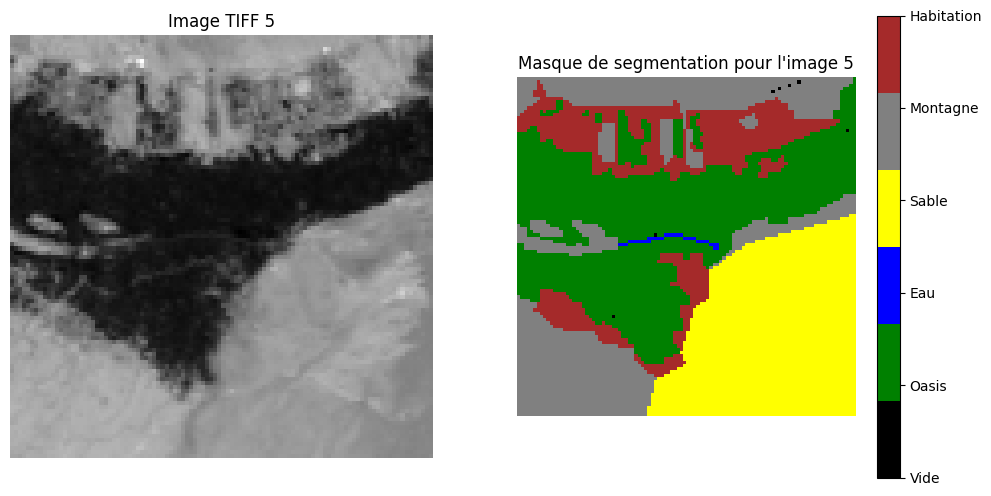

Traitement de l'image TIFF 6...


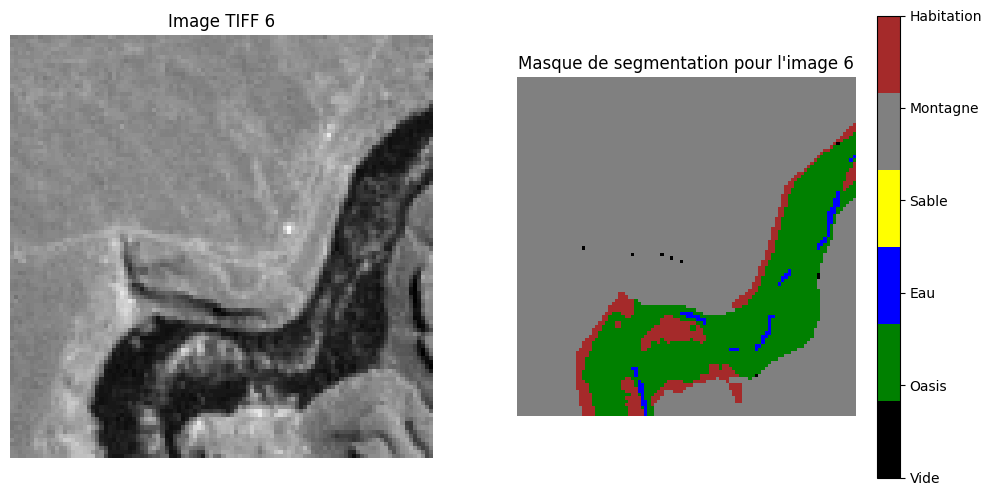

Traitement de l'image TIFF 7...


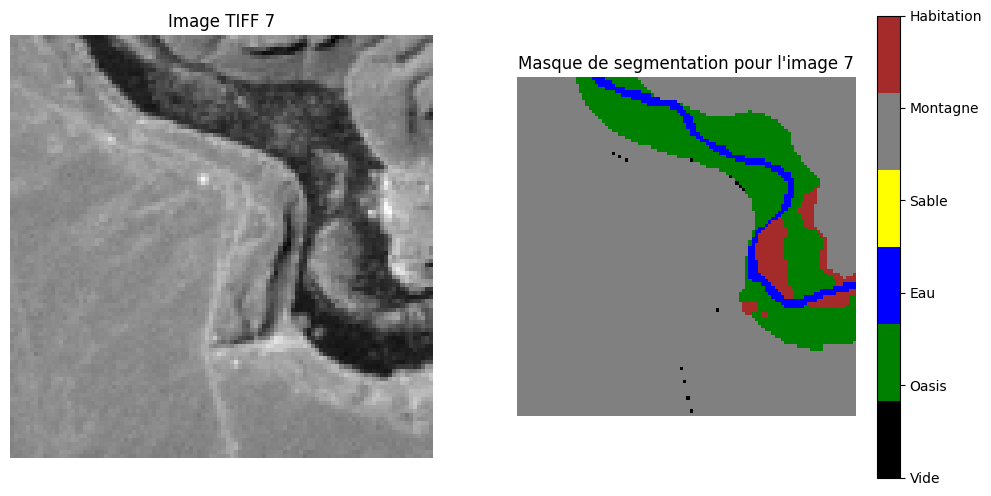

Traitement de l'image TIFF 8...


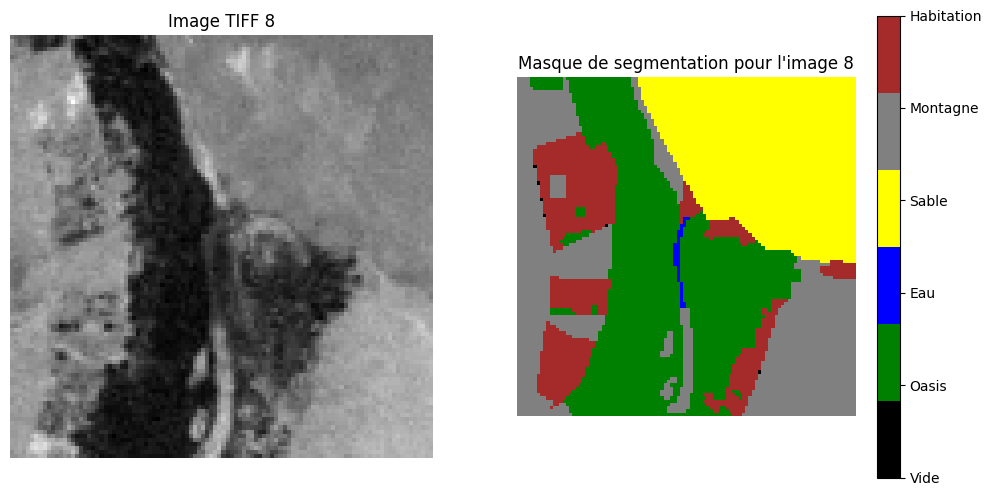

Traitement de l'image TIFF 9...


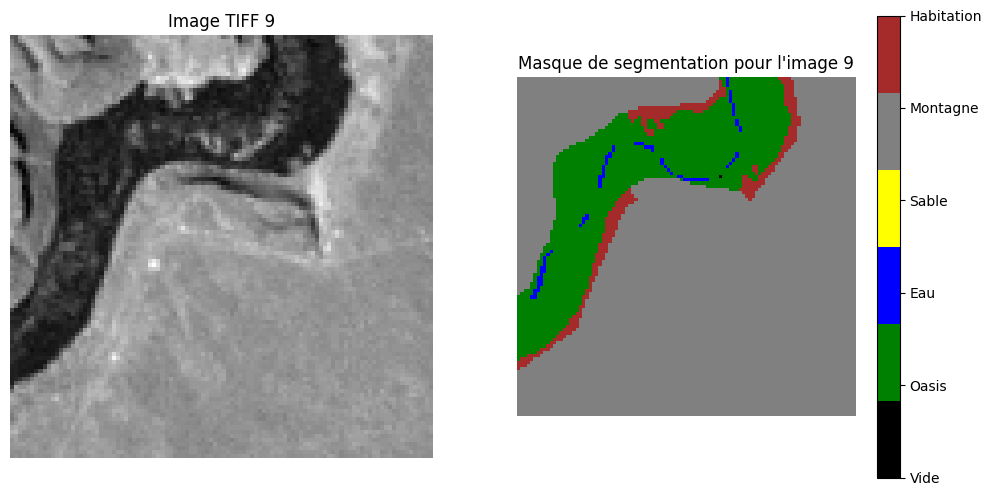

Traitement de l'image TIFF 10...


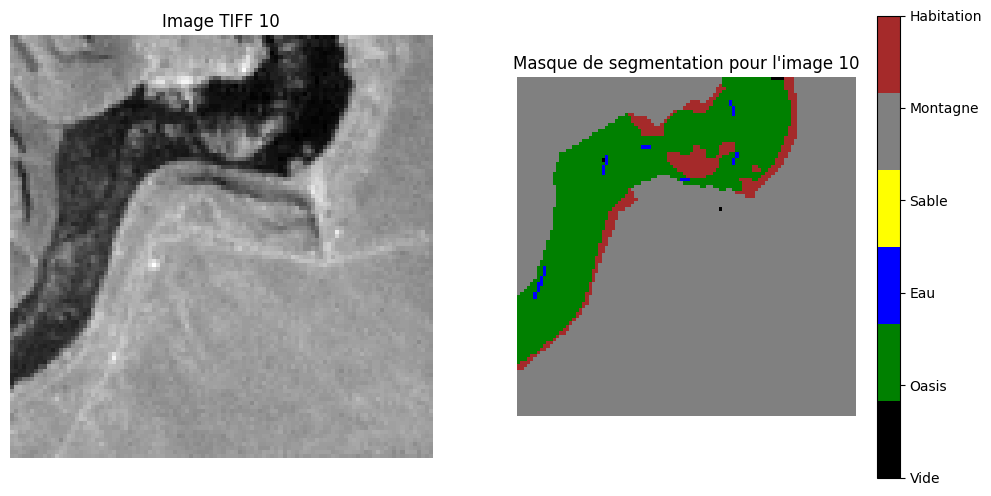

Traitement de l'image TIFF 11...


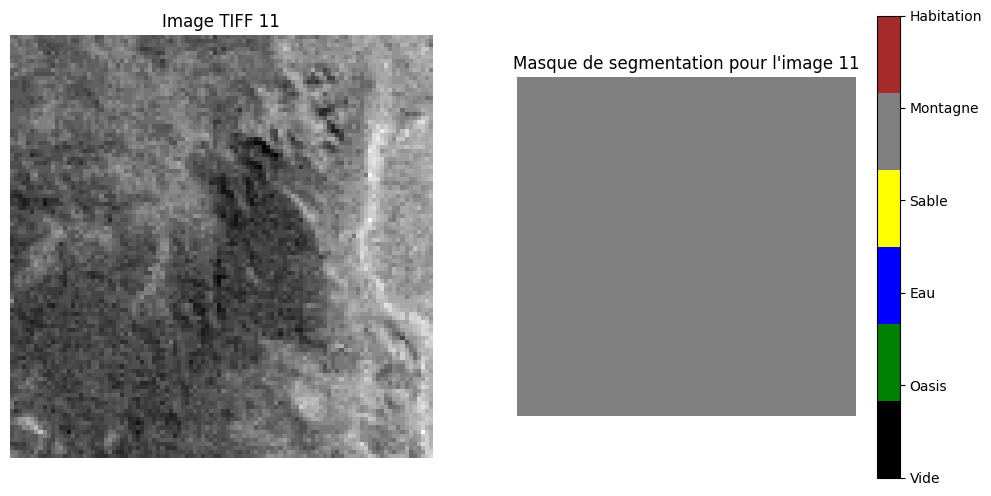

Traitement de l'image TIFF 12...


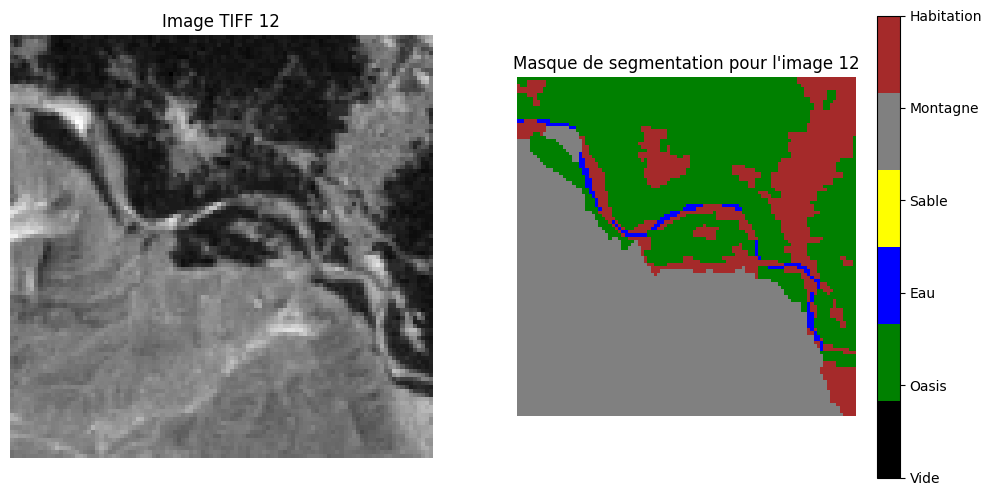

Traitement de l'image TIFF 13...


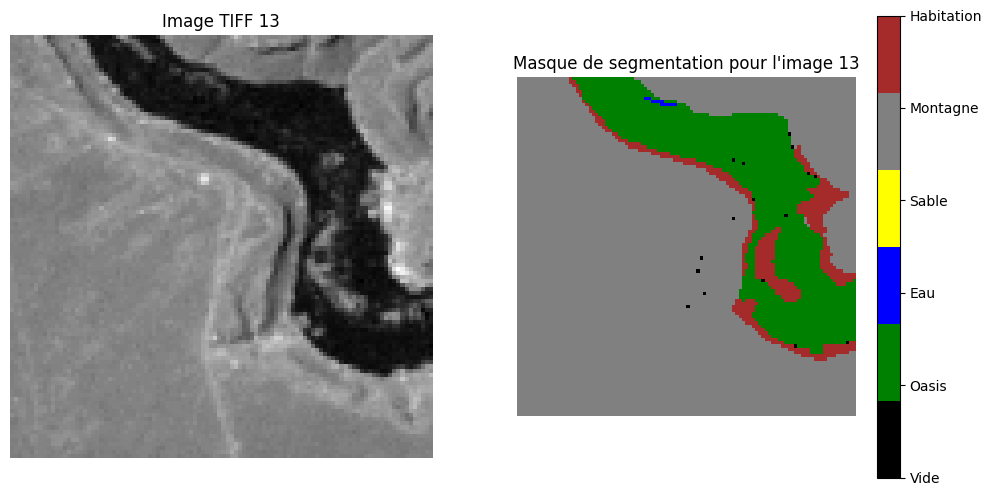

Traitement de l'image TIFF 14...


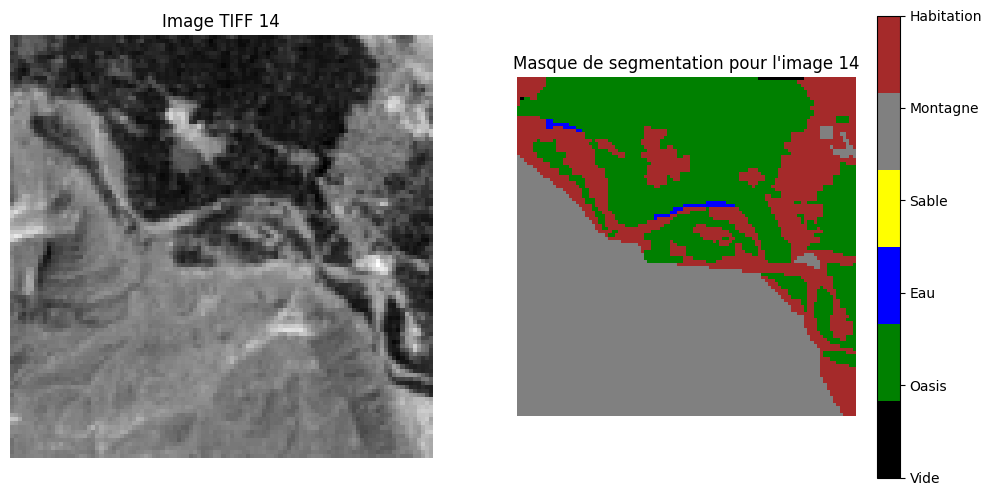

Traitement de l'image TIFF 15...


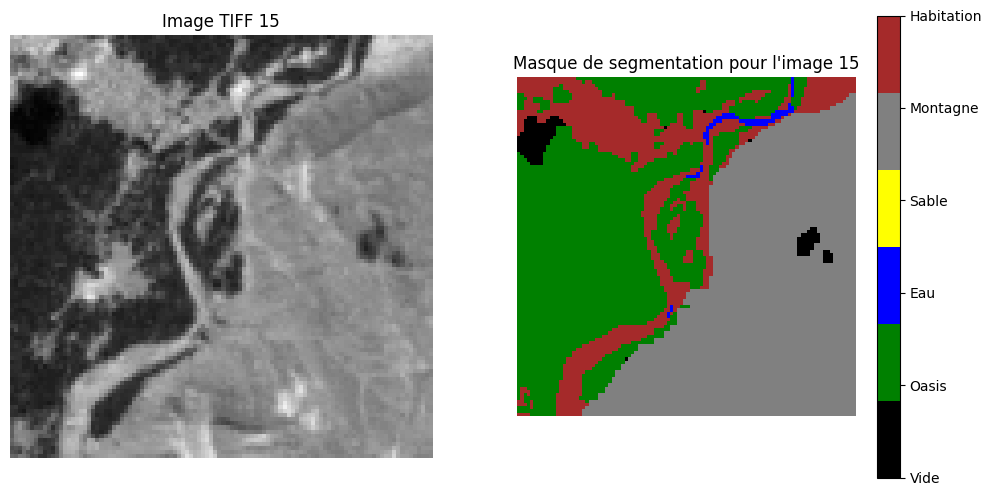

Traitement de l'image TIFF 16...


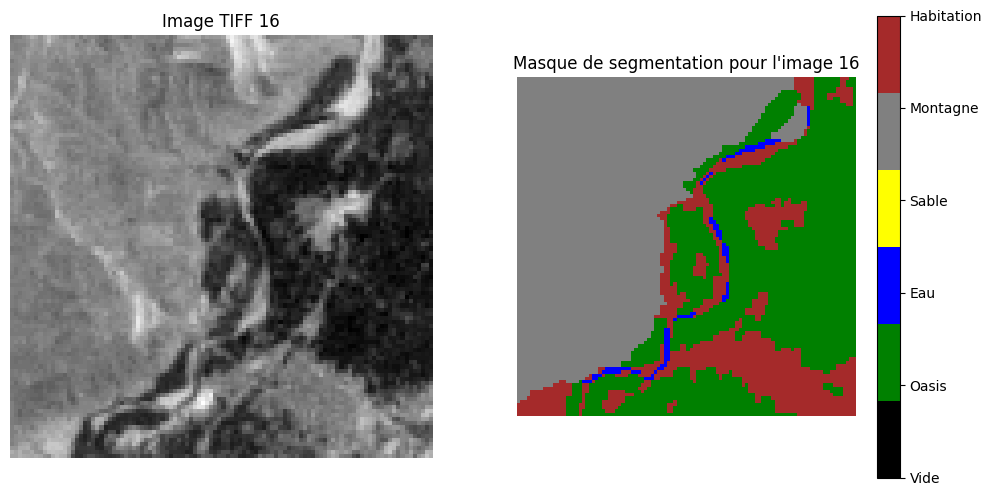

Traitement de l'image TIFF 17...


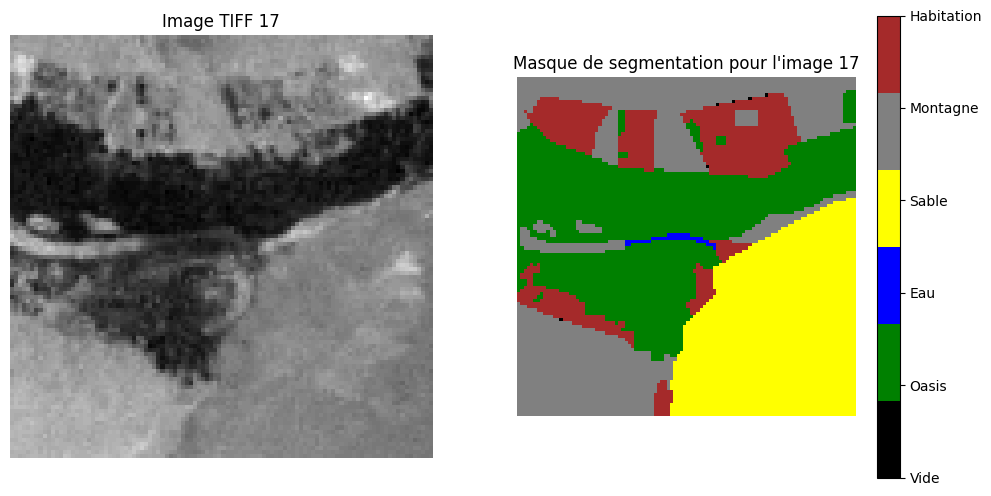

Traitement de l'image TIFF 18...


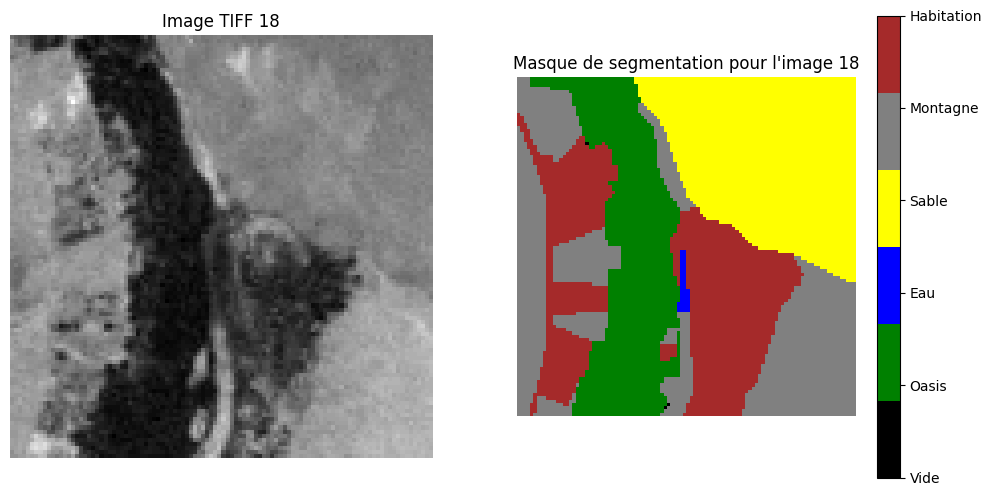

Traitement de l'image TIFF 19...


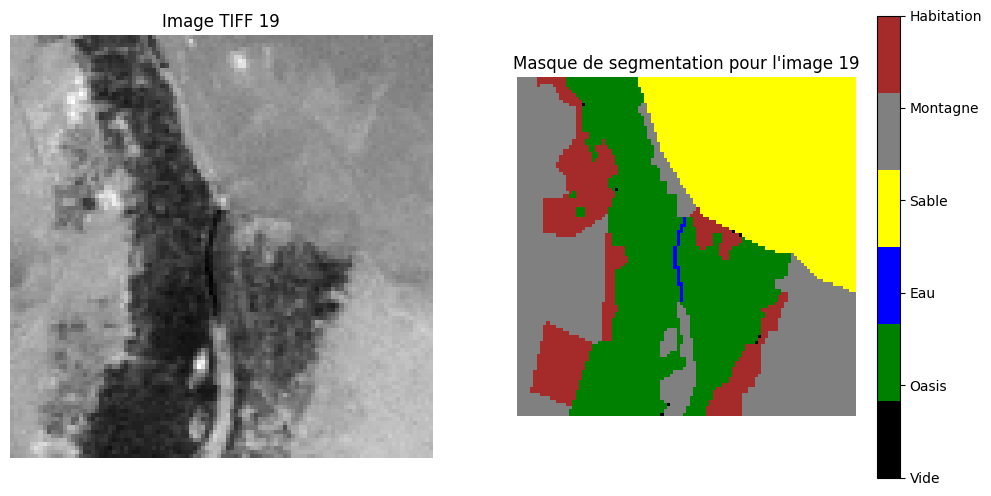

Traitement de l'image TIFF 20...


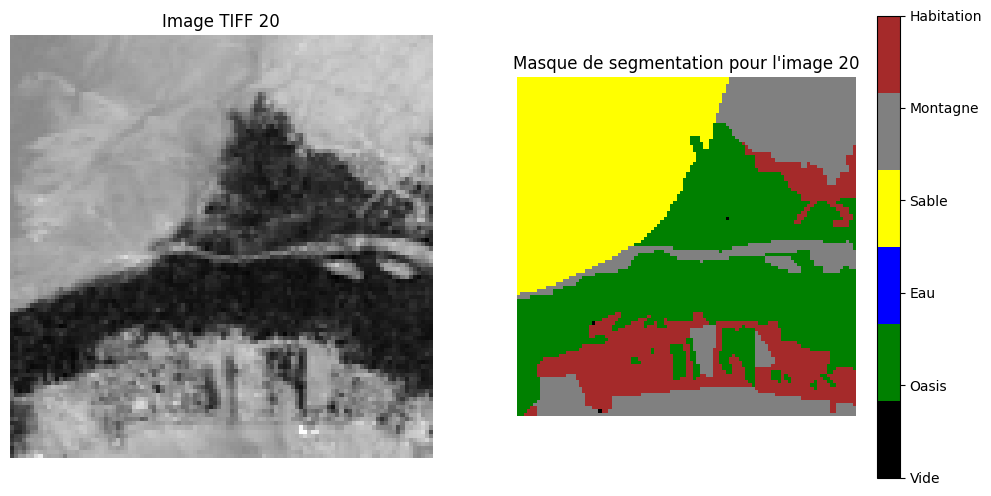

Traitement de l'image TIFF 21...


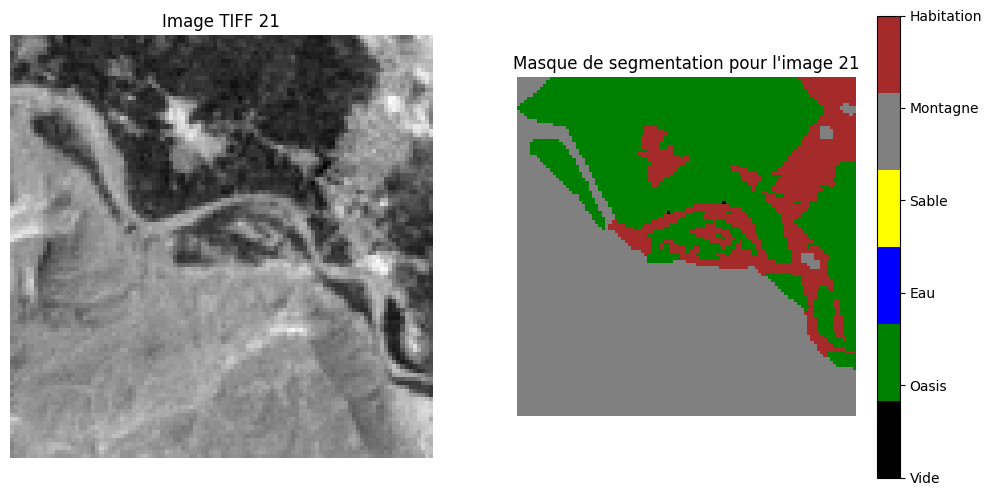

Traitement de l'image TIFF 22...


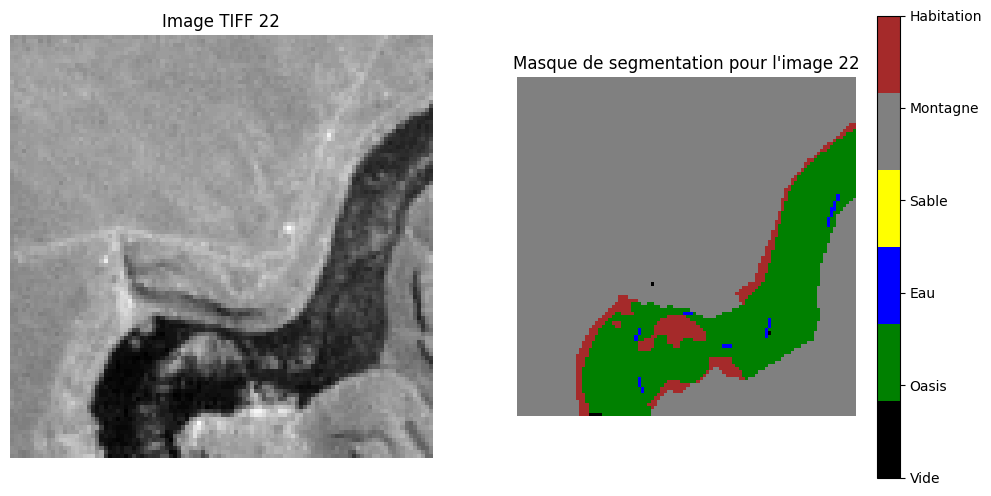

Traitement de l'image TIFF 23...


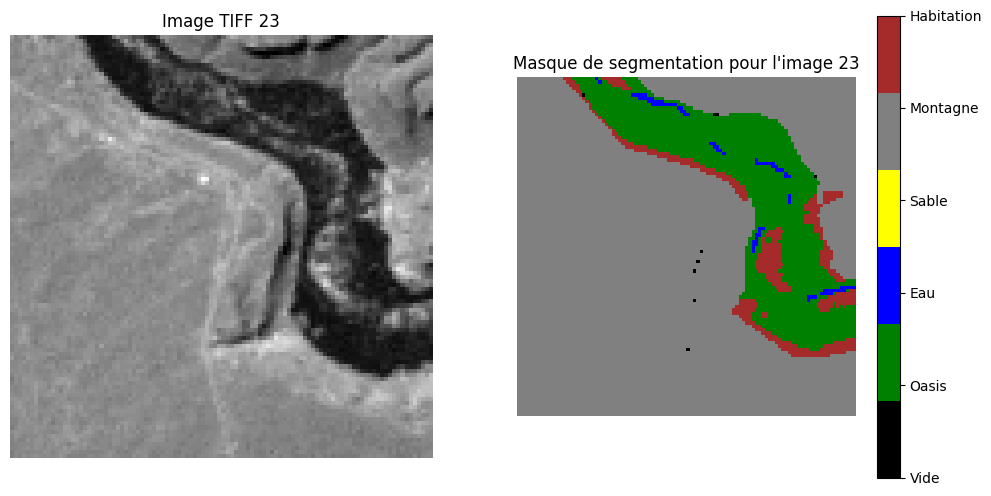

Traitement de l'image TIFF 24...


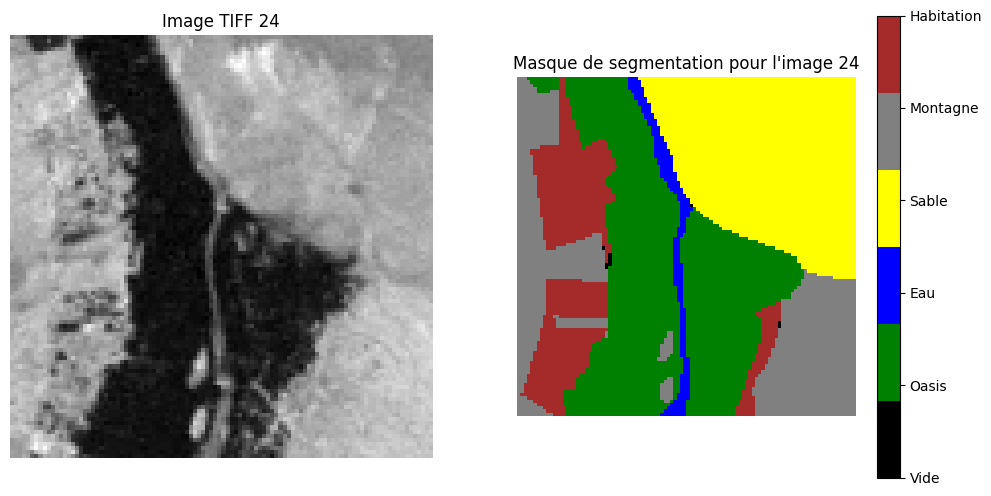

Traitement de l'image TIFF 25...


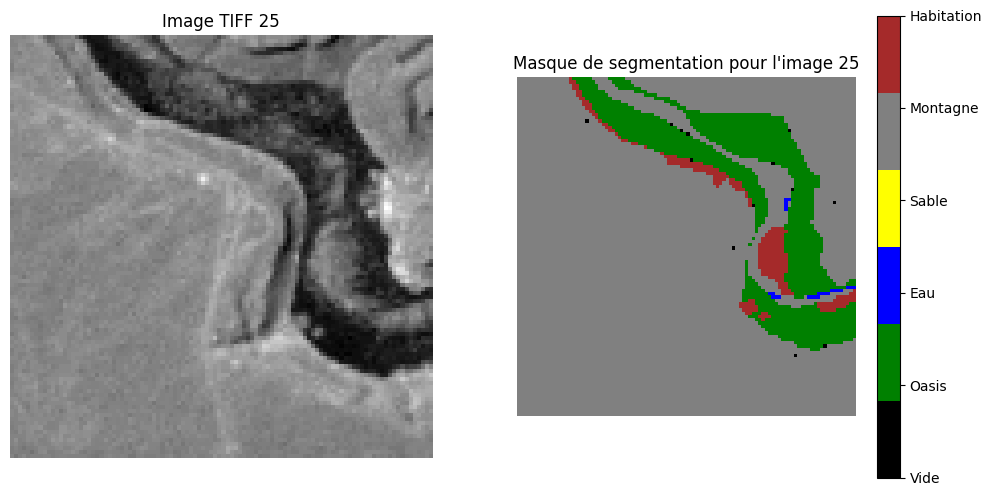

Traitement de l'image TIFF 26...


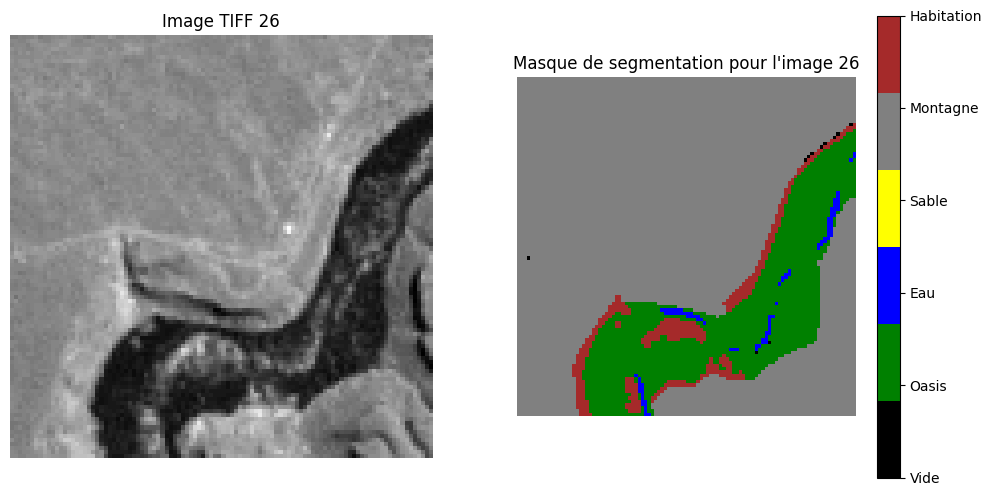

Traitement de l'image TIFF 27...


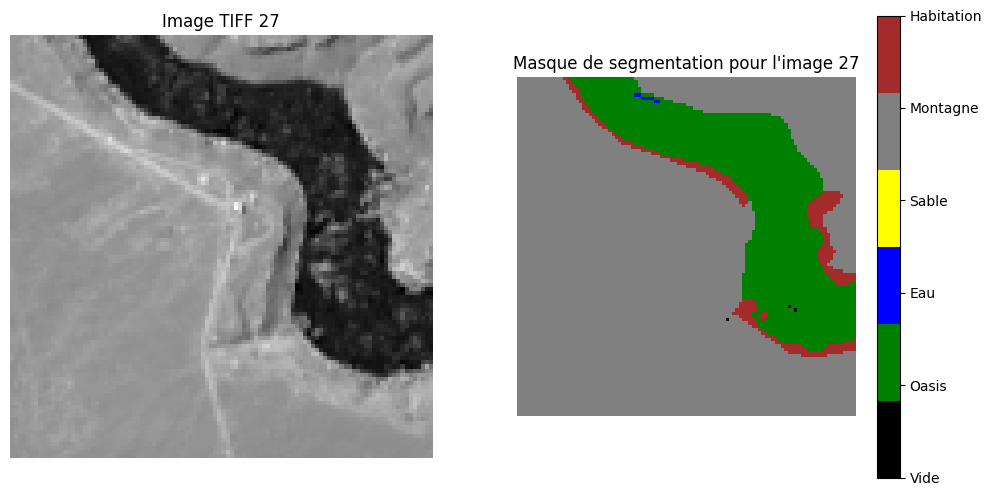

Traitement de l'image TIFF 28...


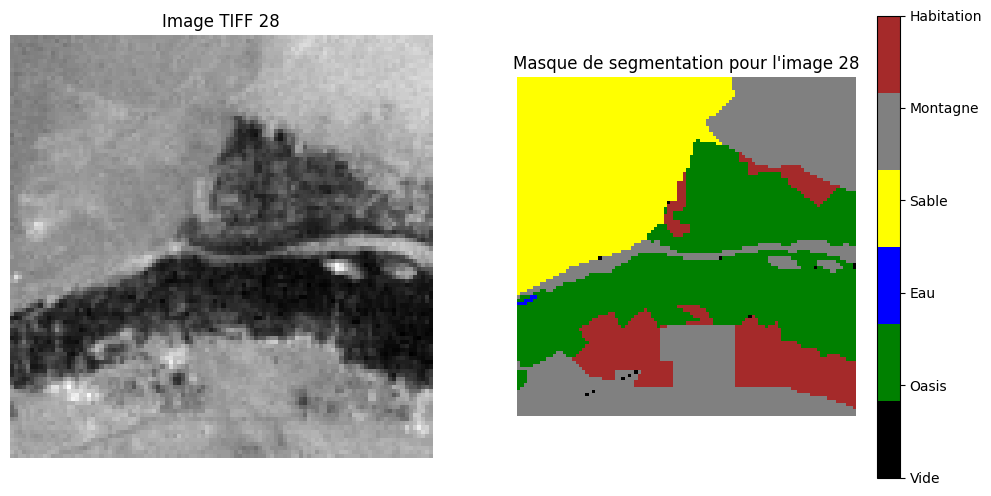

Traitement de l'image TIFF 29...


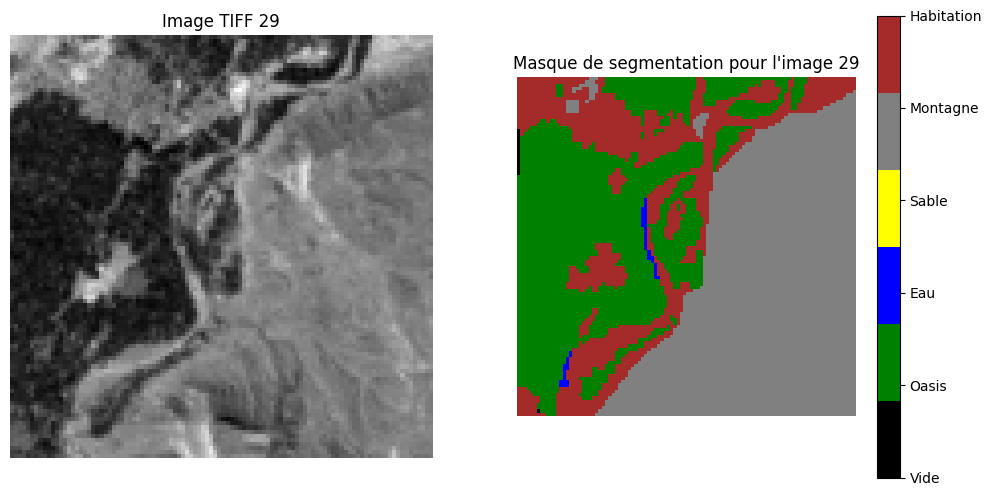

Traitement de l'image TIFF 30...


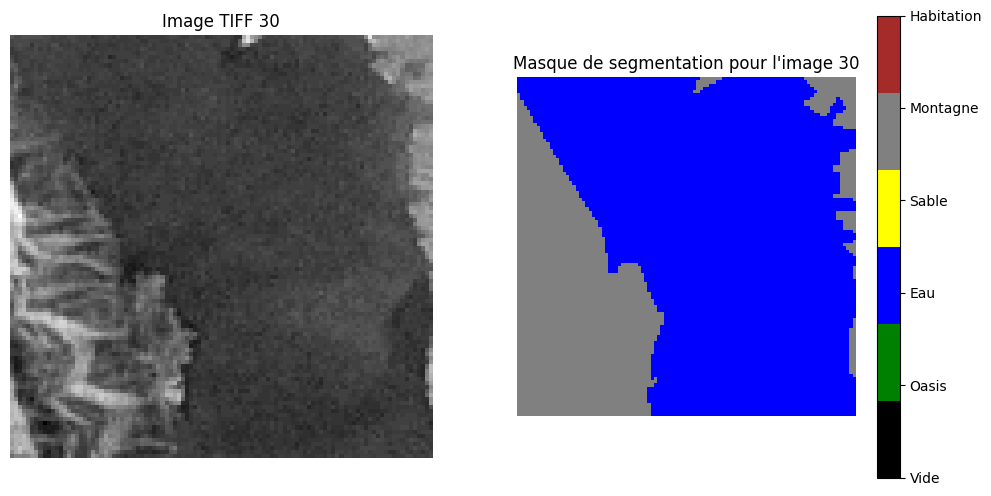

Traitement de l'image TIFF 31...


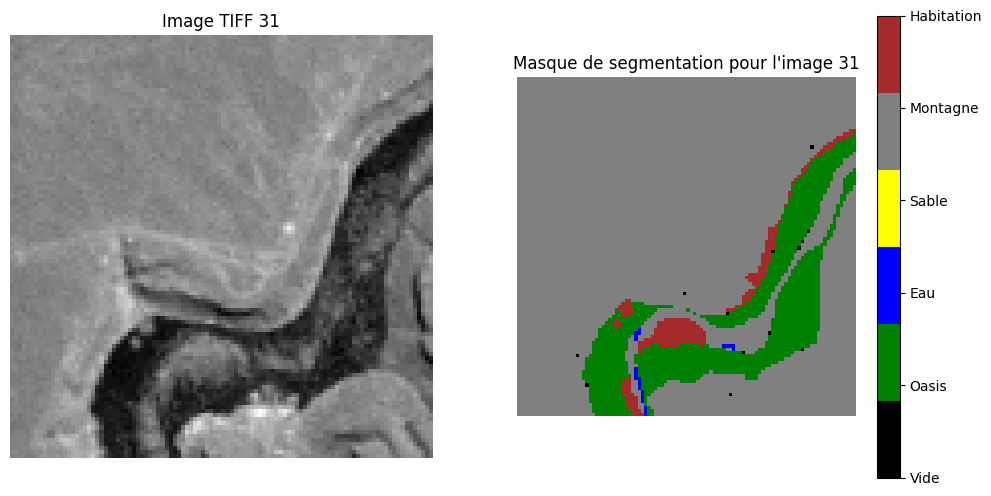

Traitement de l'image TIFF 32...


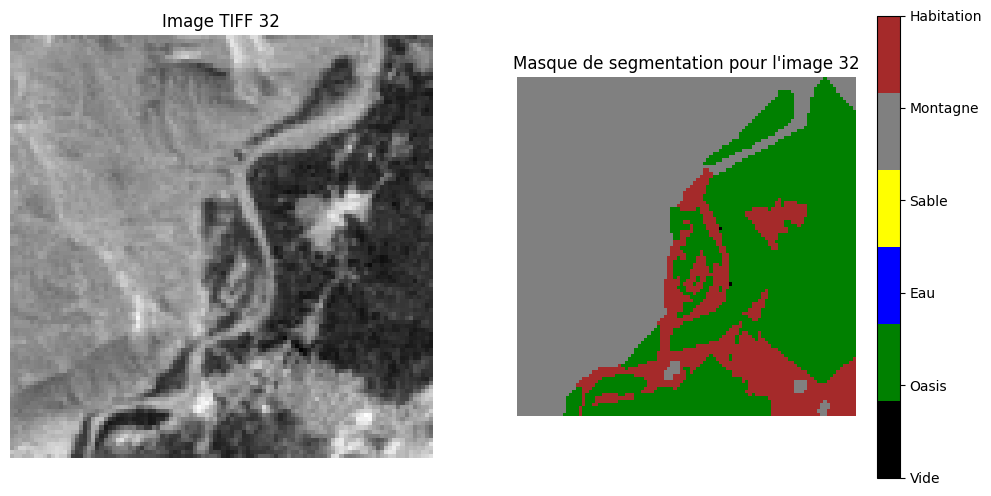

Traitement de l'image TIFF 33...


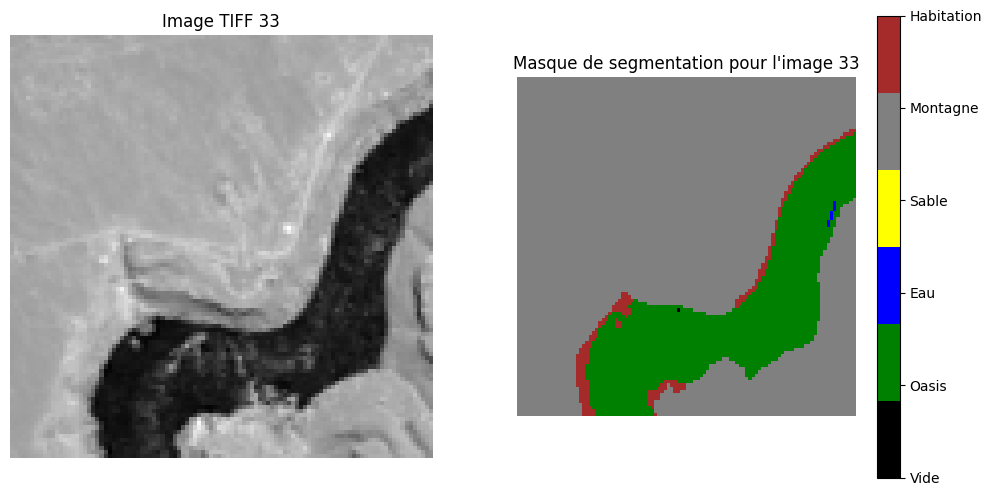

Traitement de l'image TIFF 34...


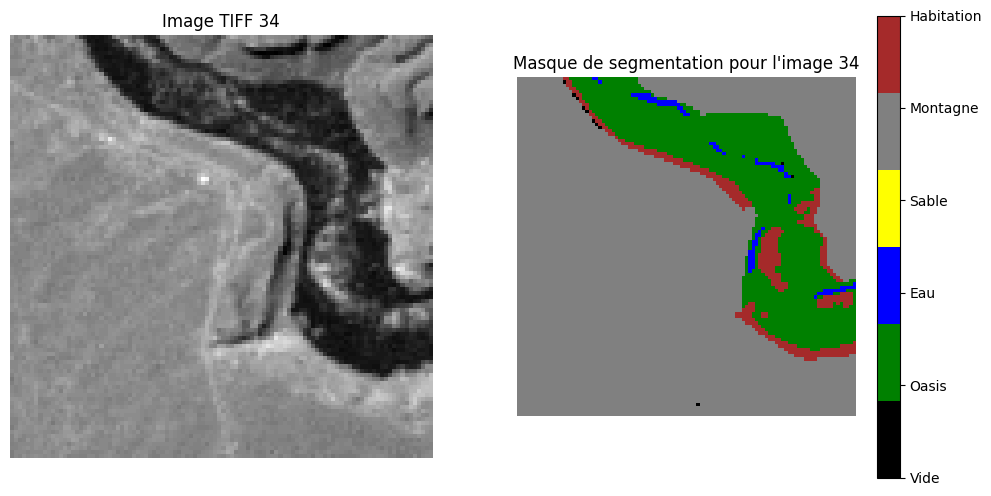

Traitement de l'image TIFF 35...


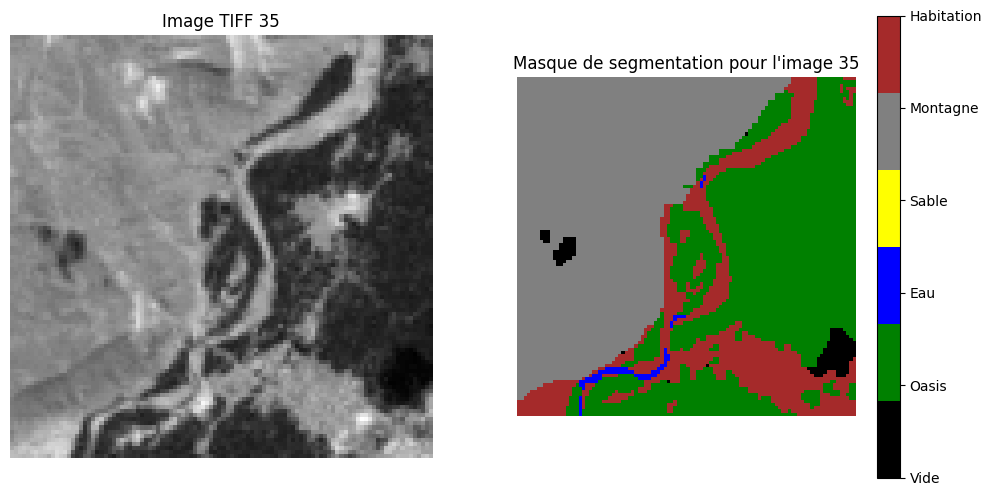

Traitement de l'image TIFF 36...


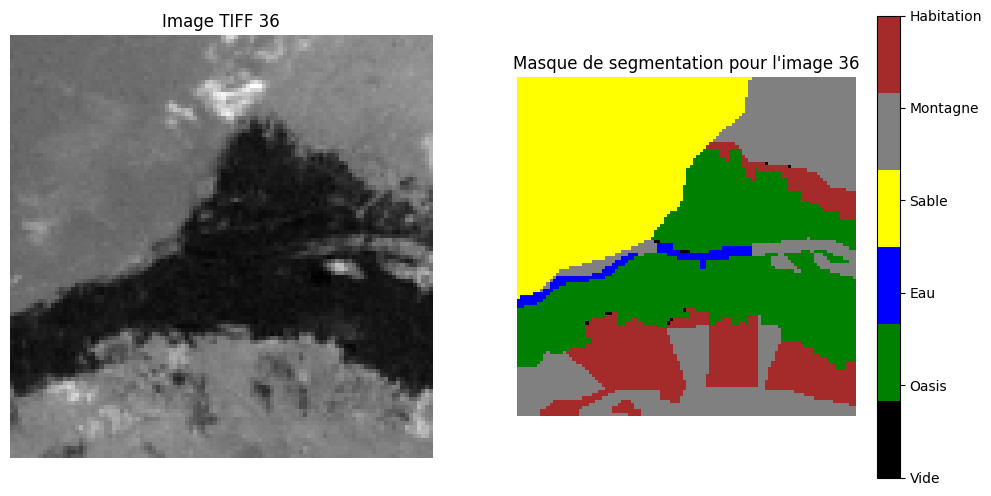

Traitement de l'image TIFF 37...


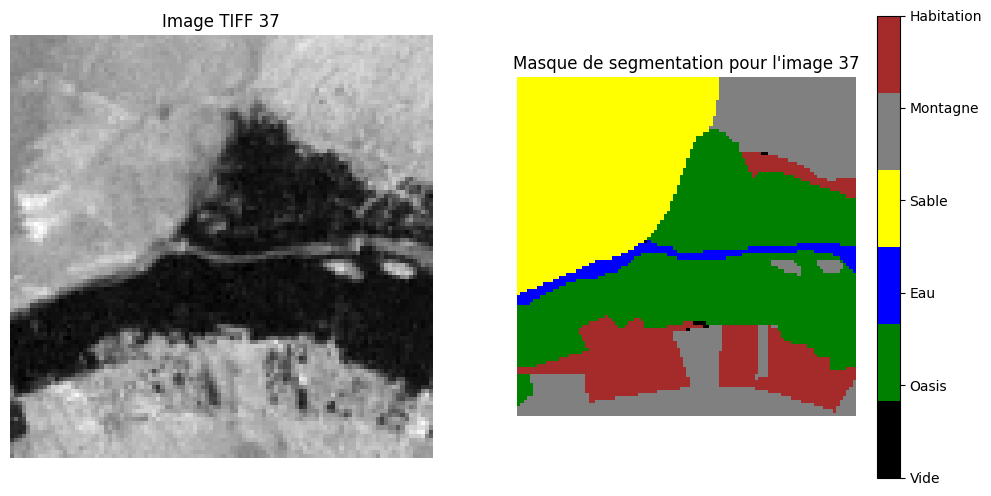

Traitement de l'image TIFF 38...


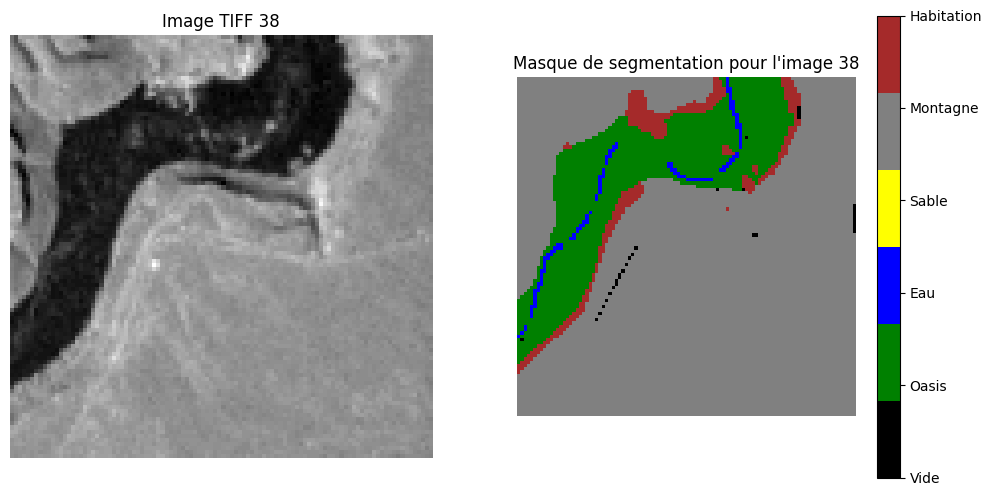

Traitement de l'image TIFF 39...


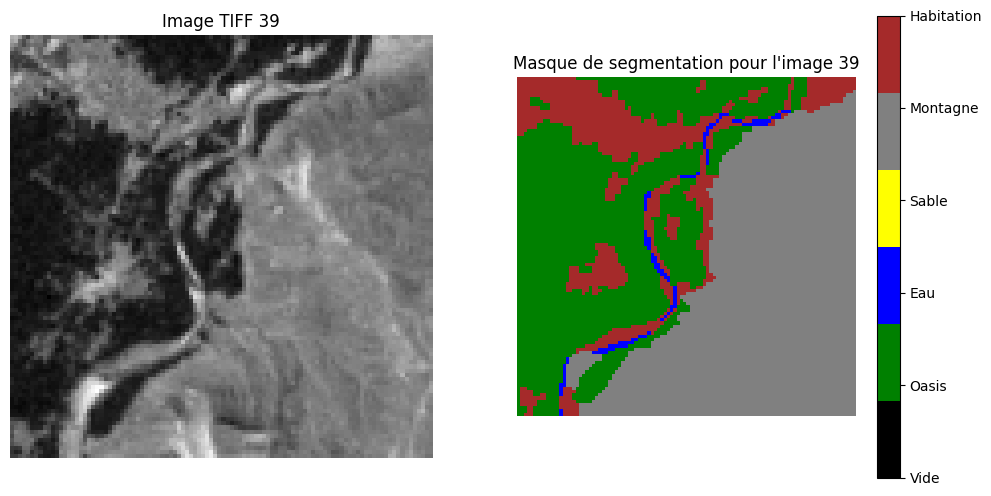

Traitement de l'image TIFF 40...


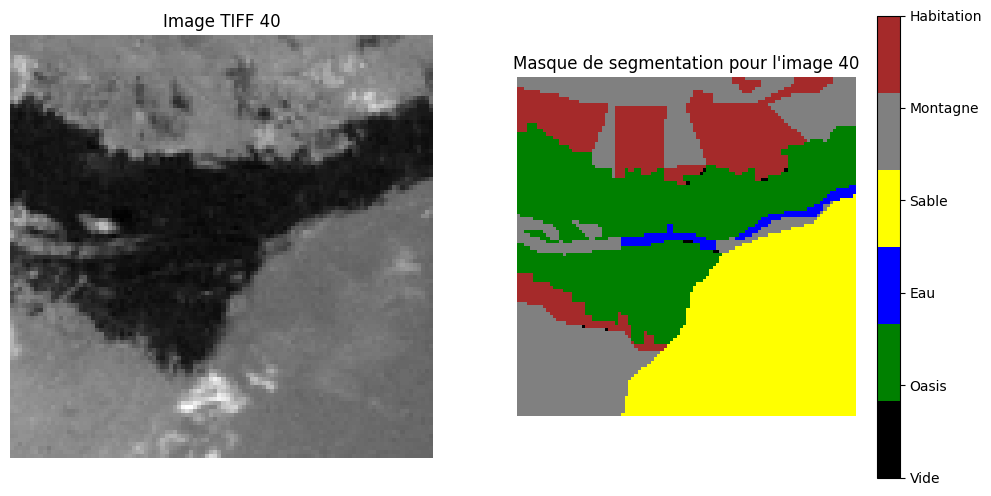

Traitement de l'image TIFF 41...


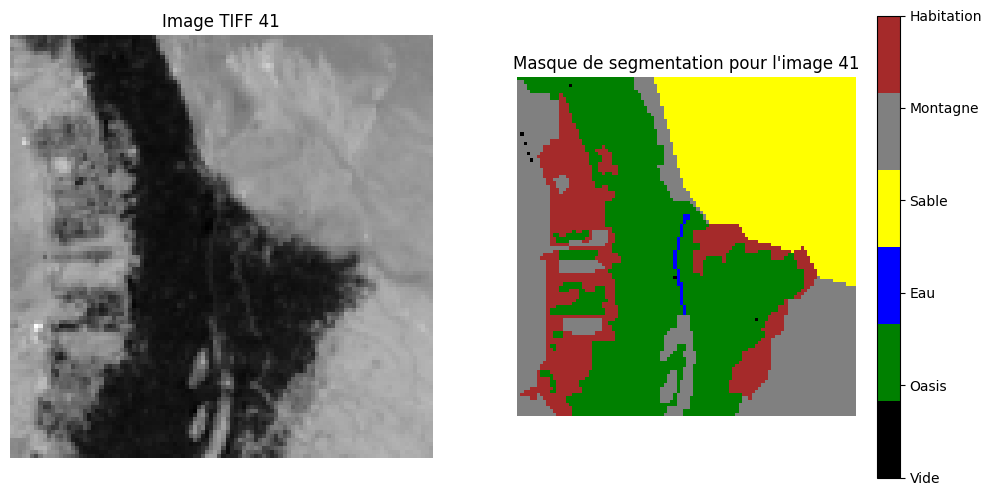

Traitement de l'image TIFF 42...


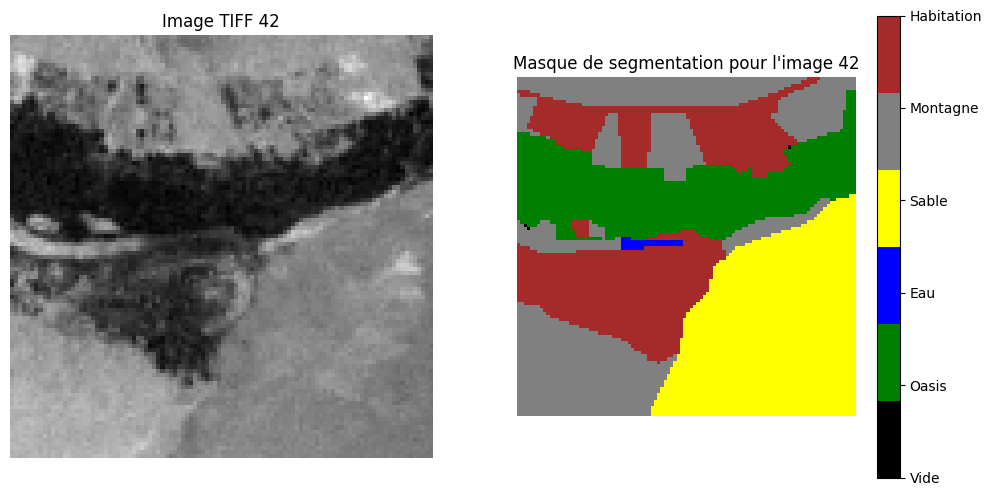

Traitement de l'image TIFF 43...


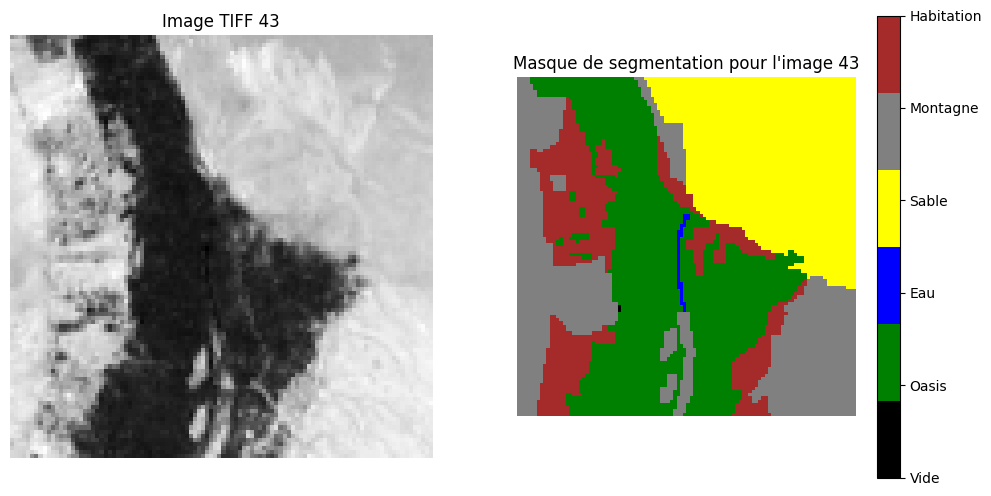

Traitement de l'image TIFF 44...


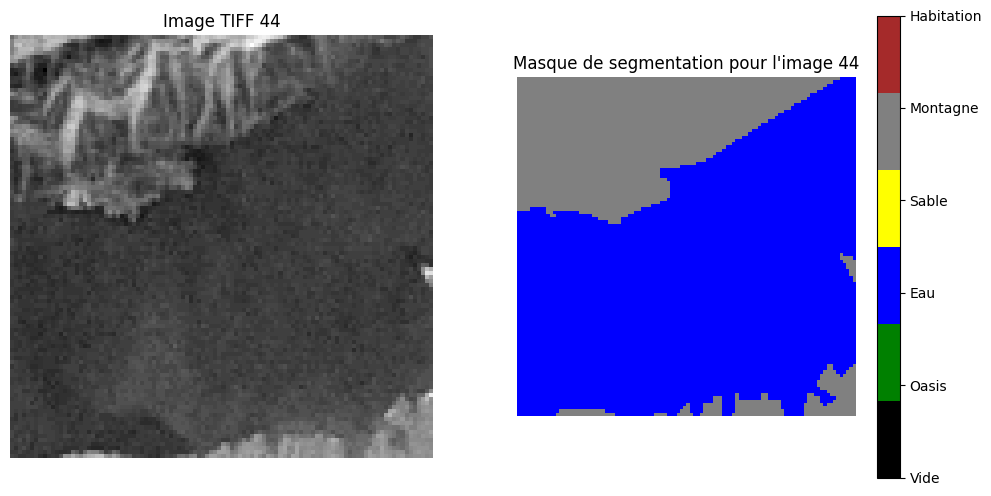

Traitement de l'image TIFF 45...


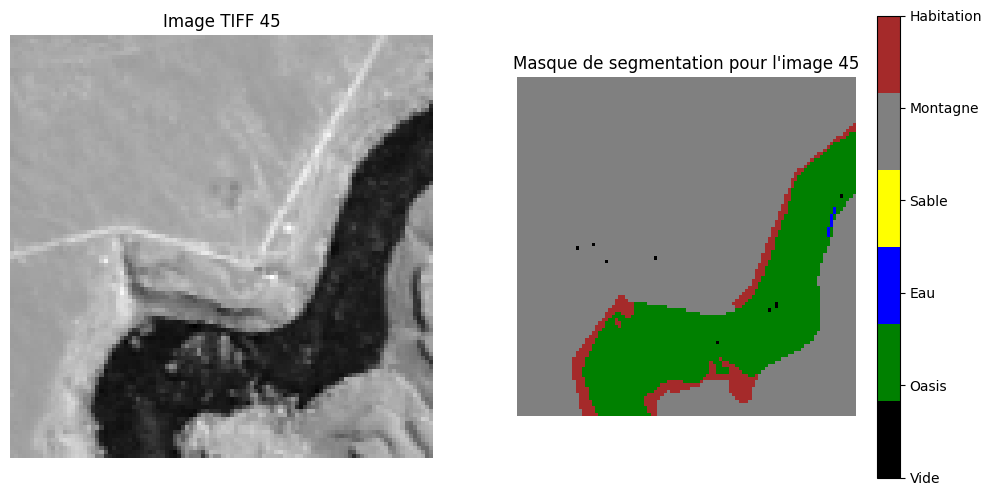

Traitement de l'image TIFF 46...


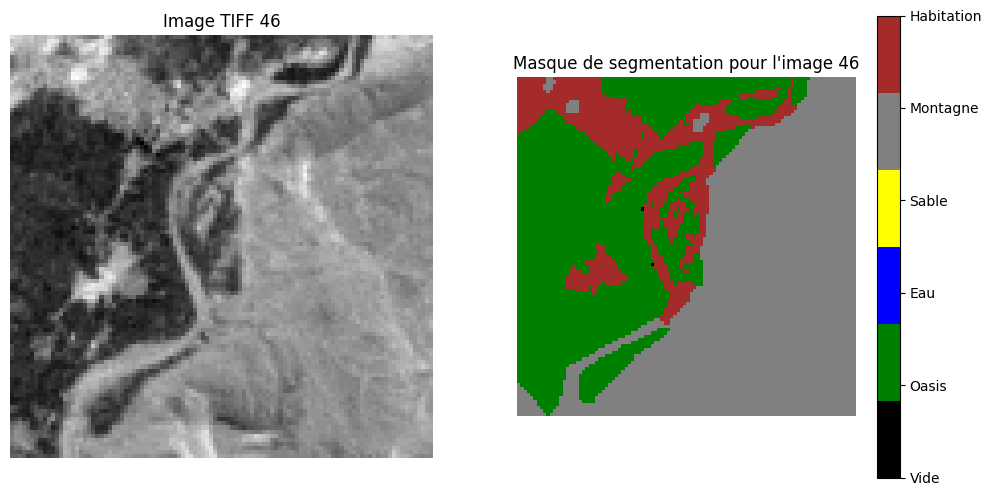

Traitement de l'image TIFF 47...


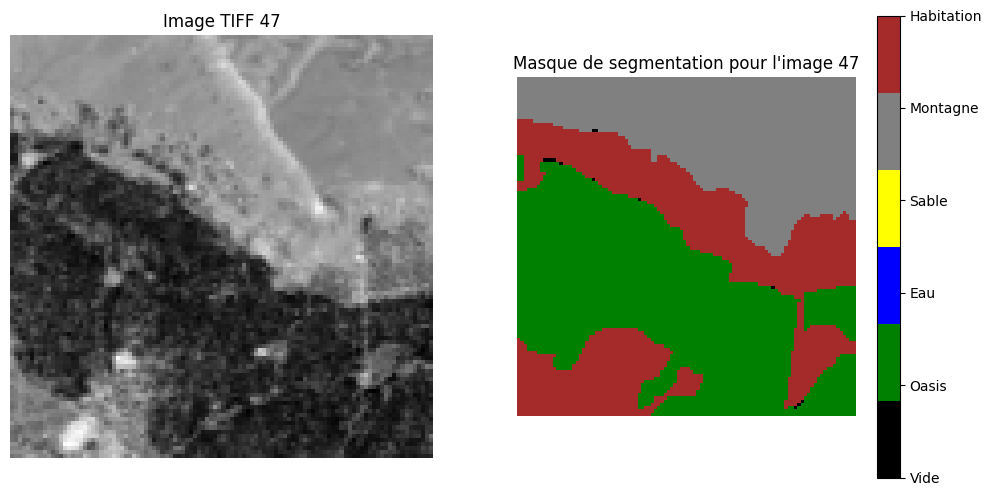

Traitement de l'image TIFF 48...


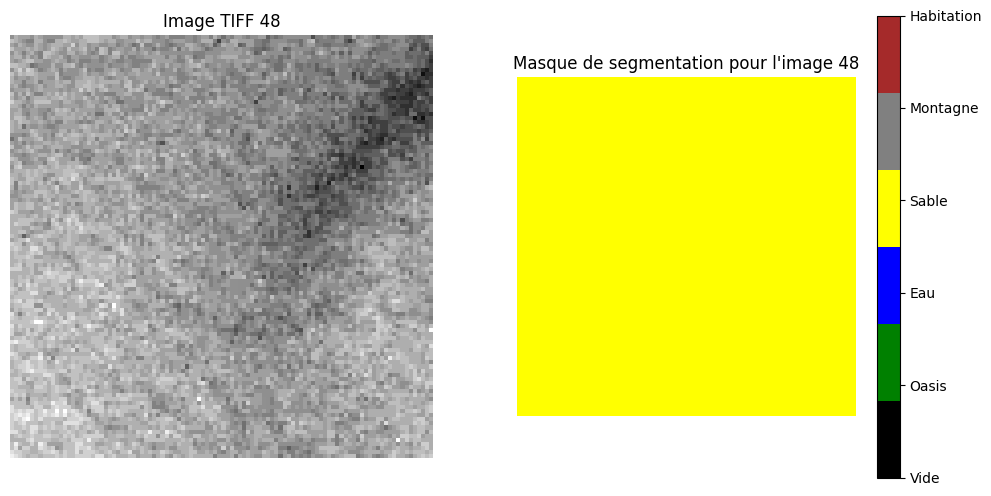

Traitement de l'image TIFF 49...


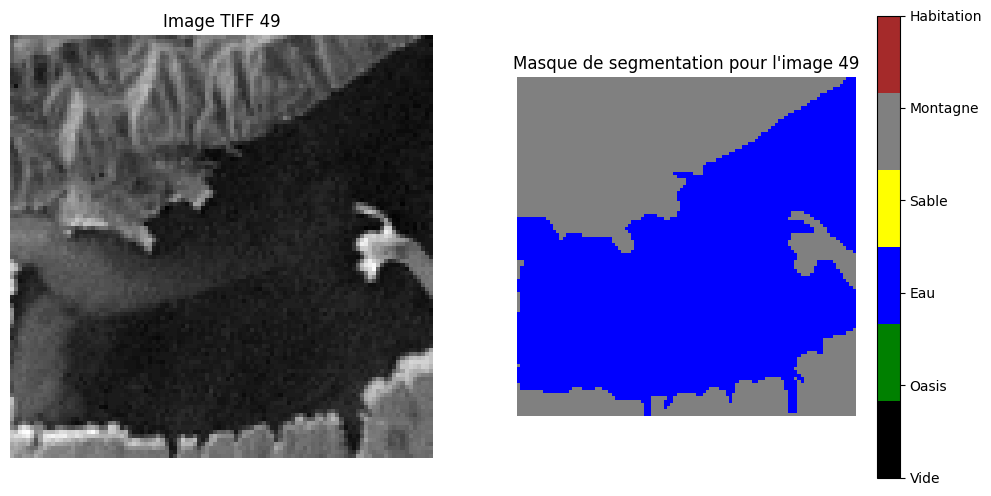

Traitement de l'image TIFF 50...


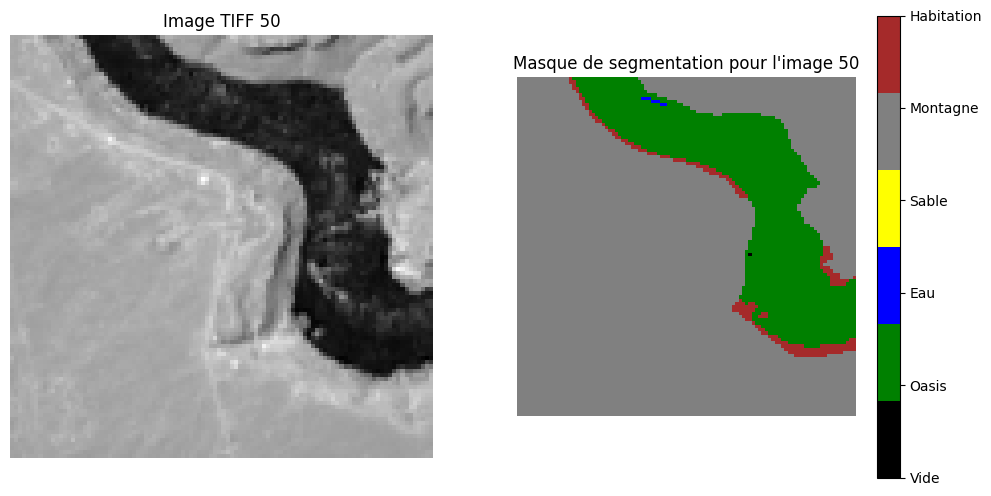

Traitement de l'image TIFF 51...


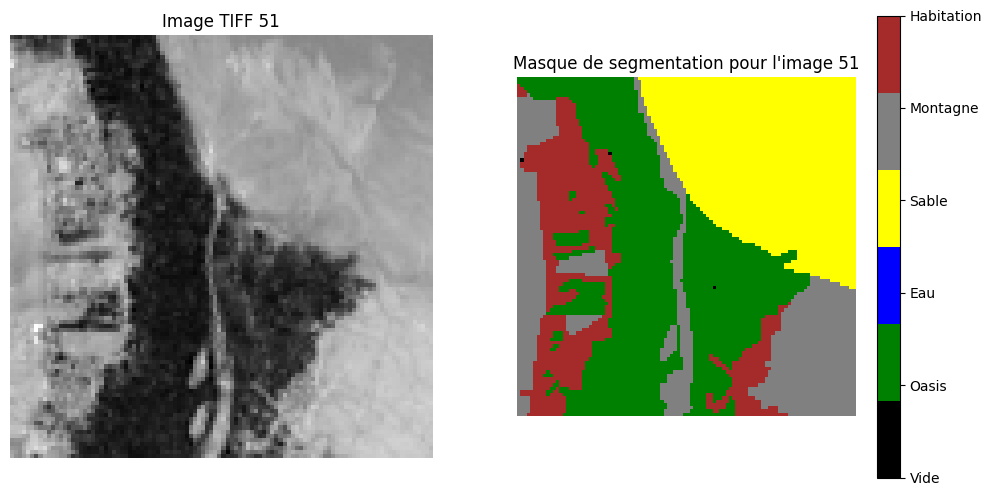

Traitement de l'image TIFF 52...


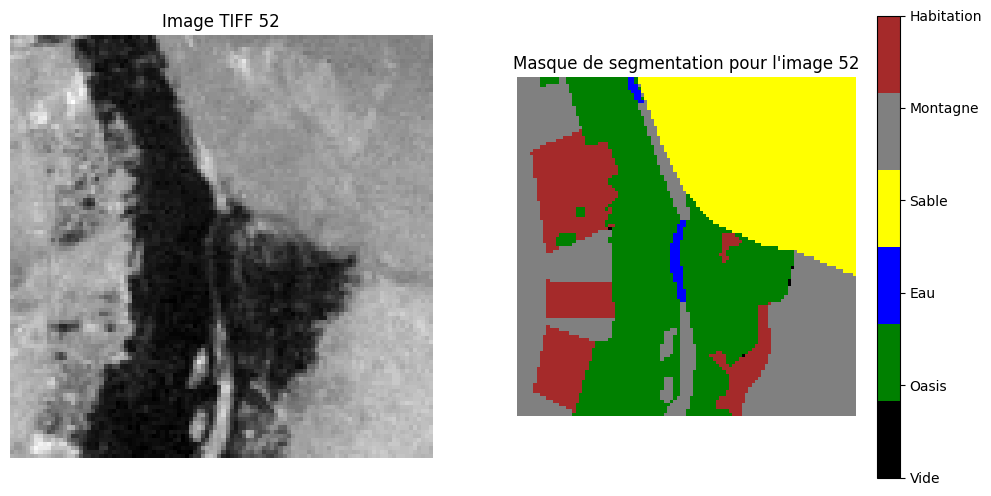

Traitement de l'image TIFF 53...


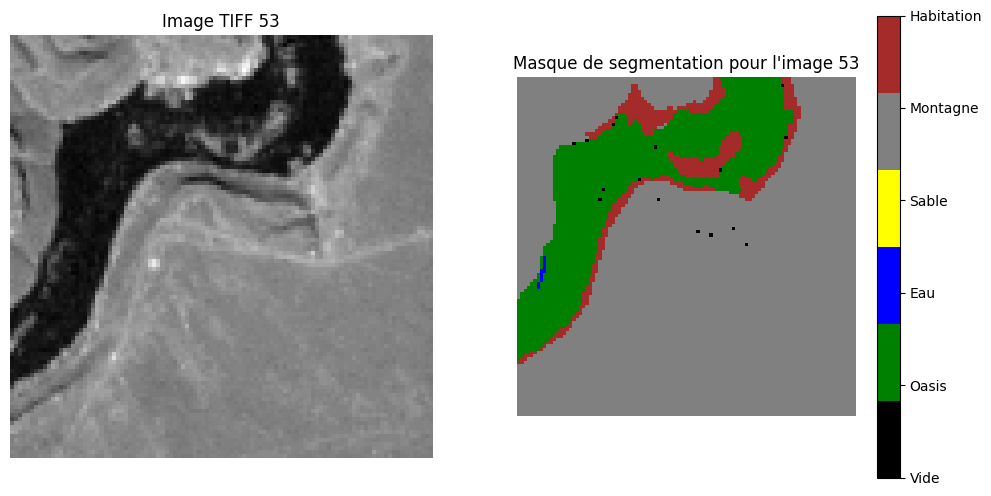

Traitement de l'image TIFF 54...


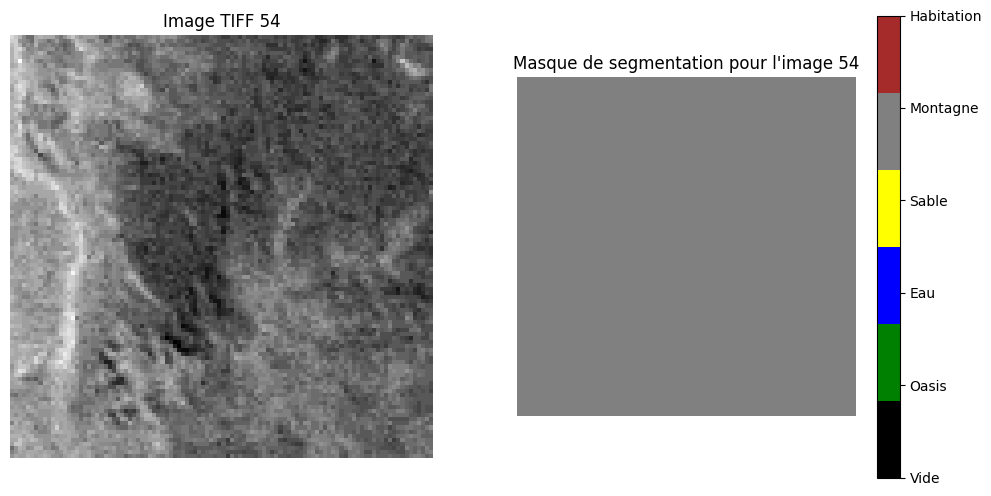

Traitement de l'image TIFF 55...


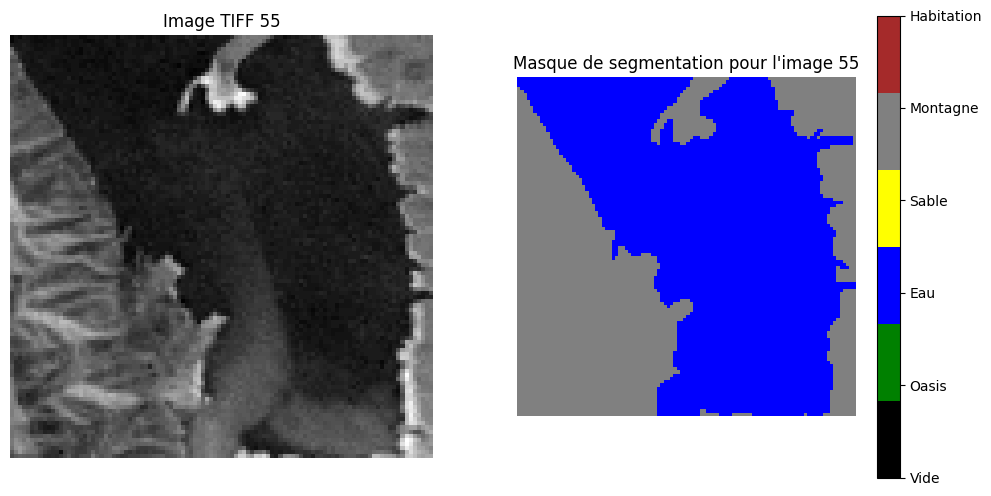

Traitement de l'image TIFF 56...


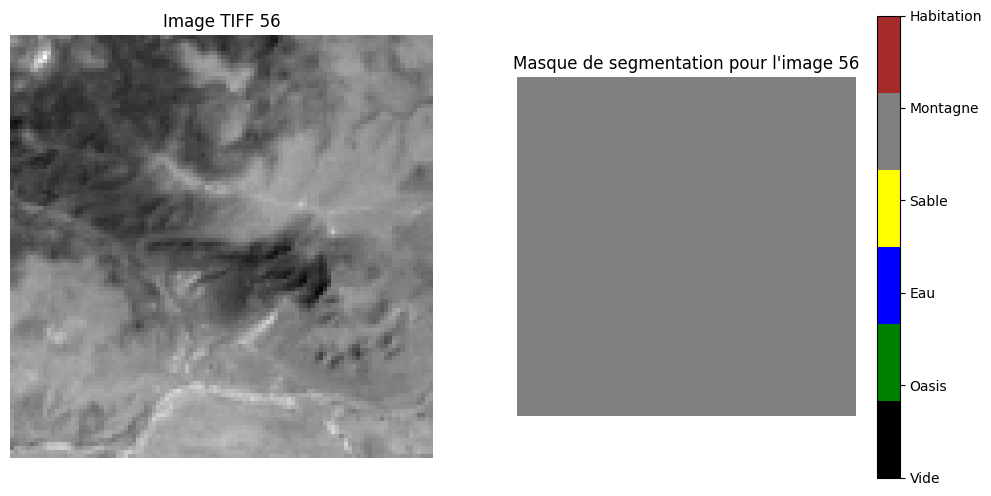

Traitement de l'image TIFF 57...


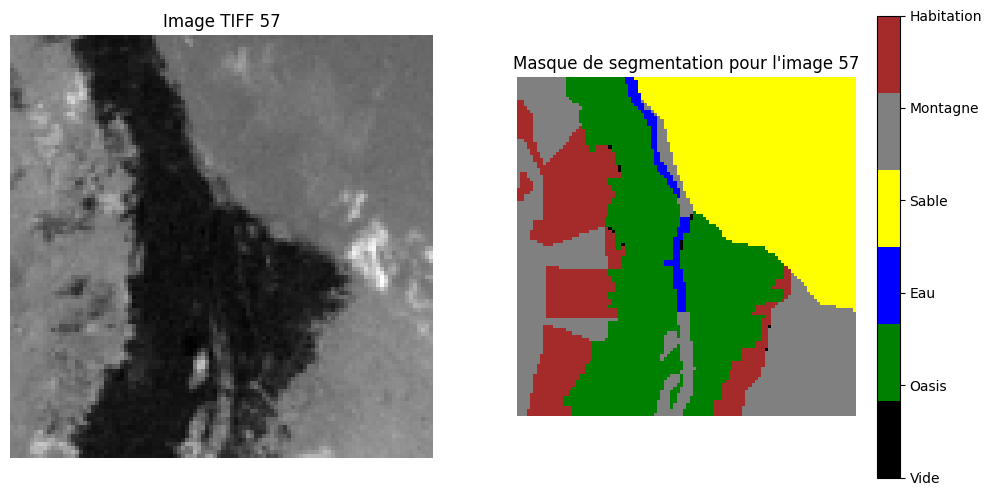

Traitement de l'image TIFF 58...


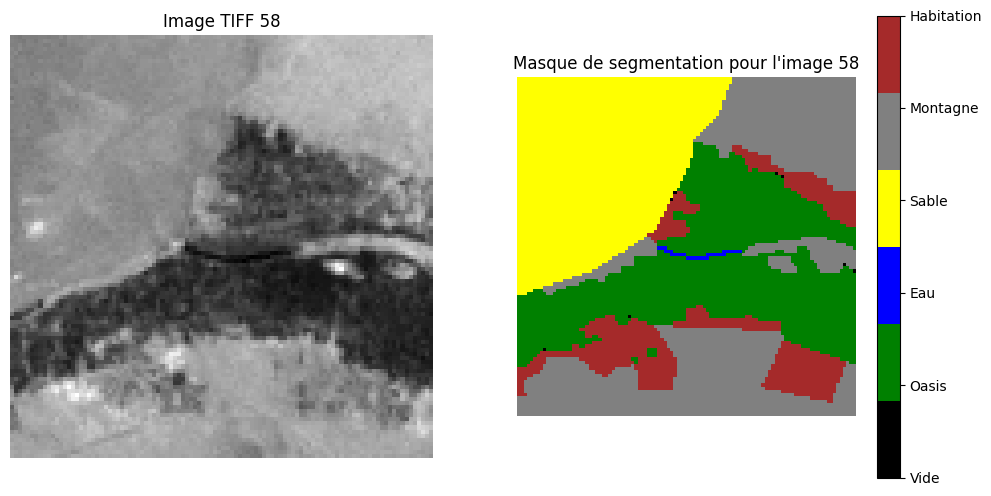

Traitement de l'image TIFF 59...


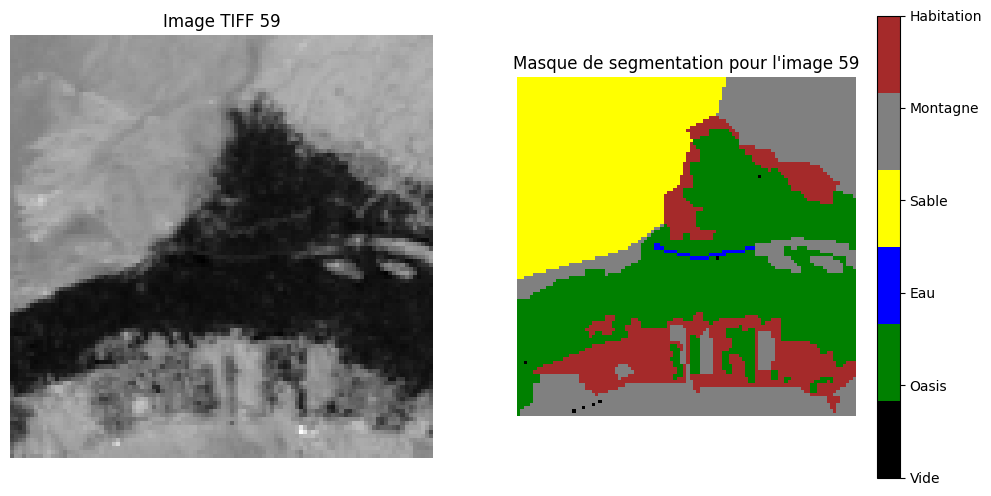

Traitement de l'image TIFF 60...


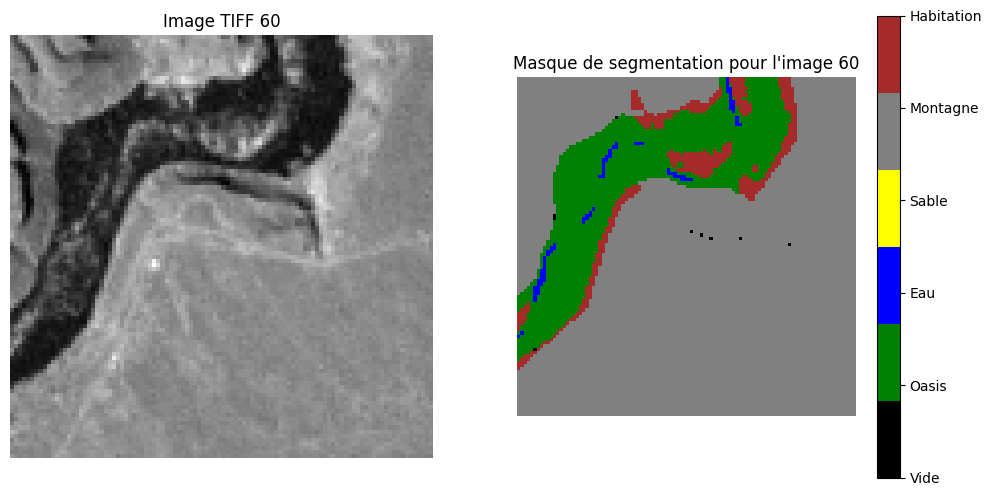

Traitement de l'image TIFF 61...


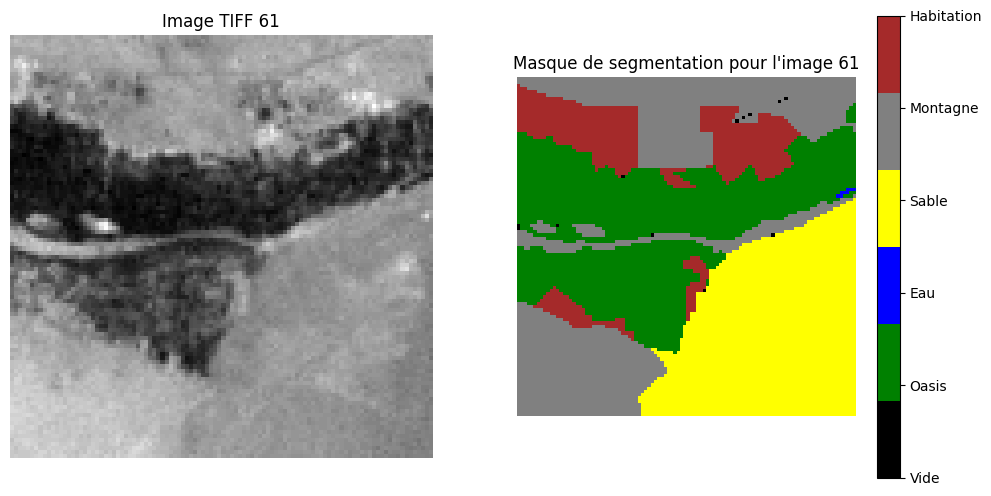

Traitement de l'image TIFF 62...


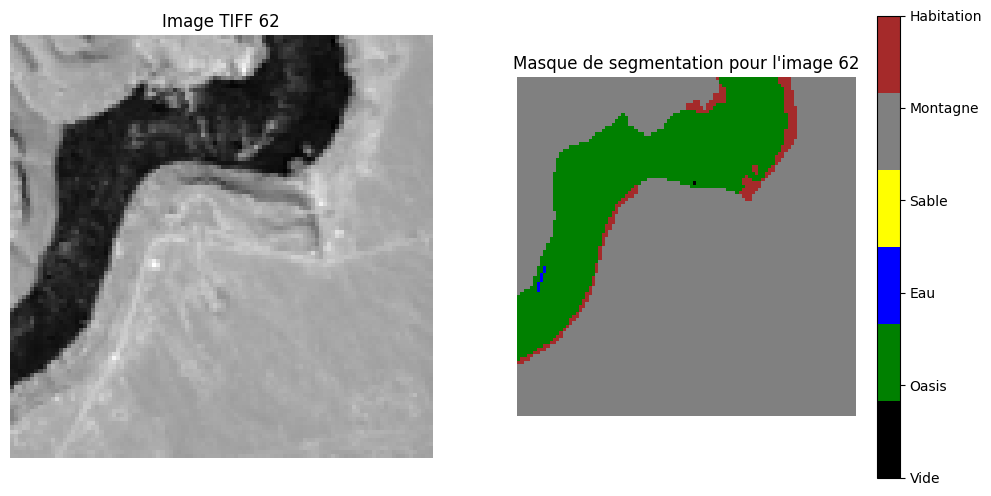

Traitement de l'image TIFF 63...


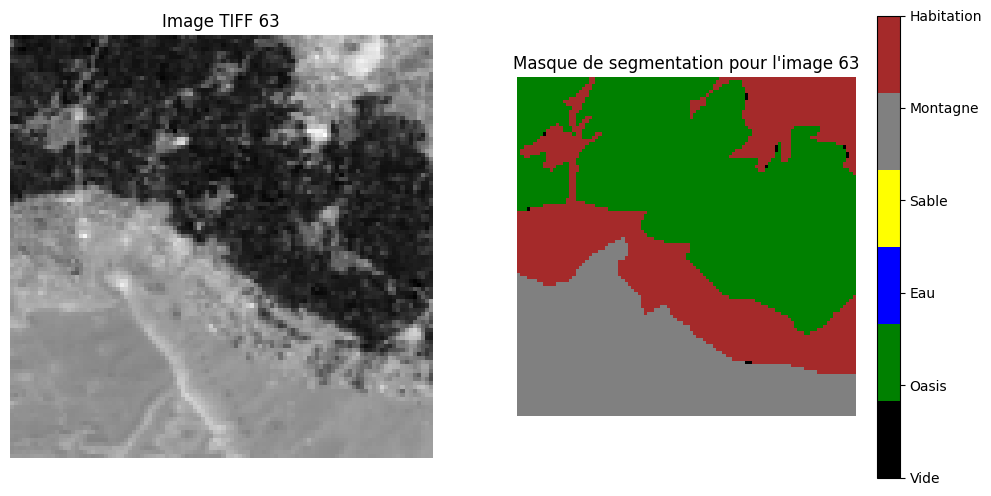

Traitement de l'image TIFF 64...


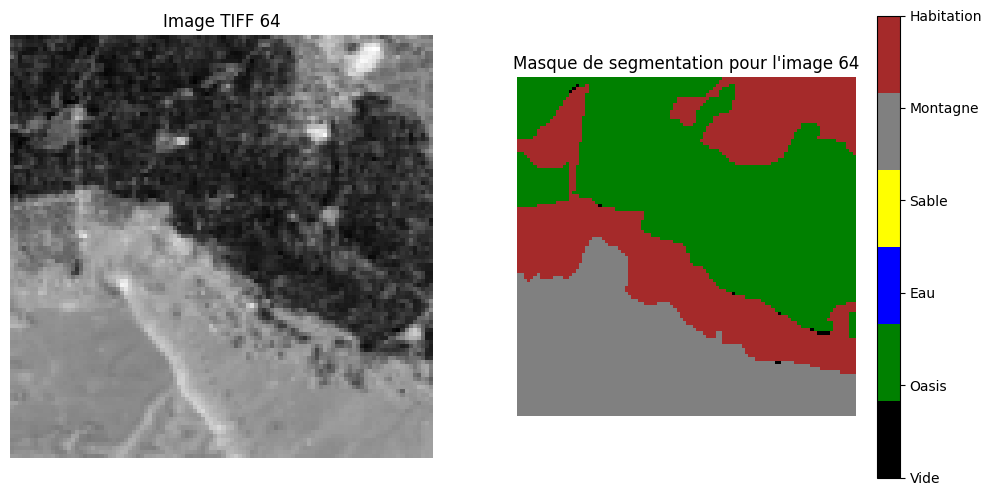

Traitement de l'image TIFF 65...


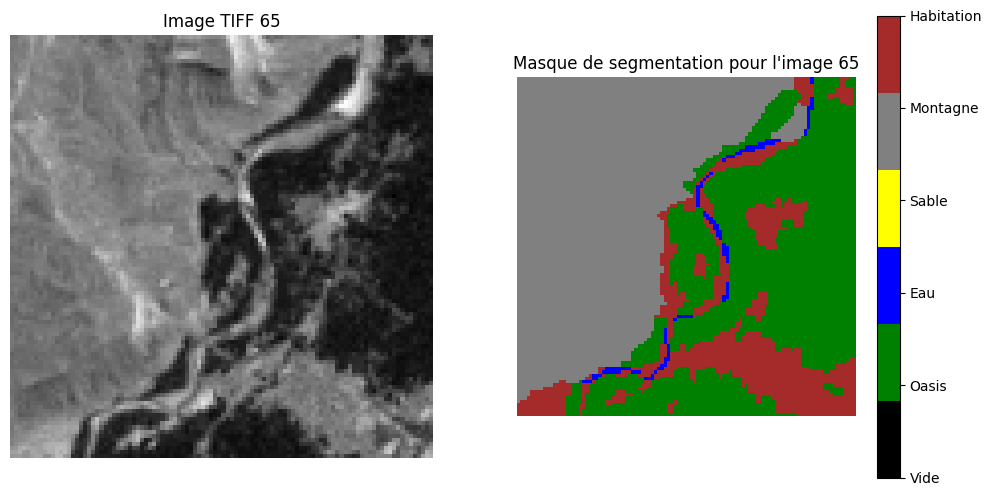

Traitement de l'image TIFF 66...


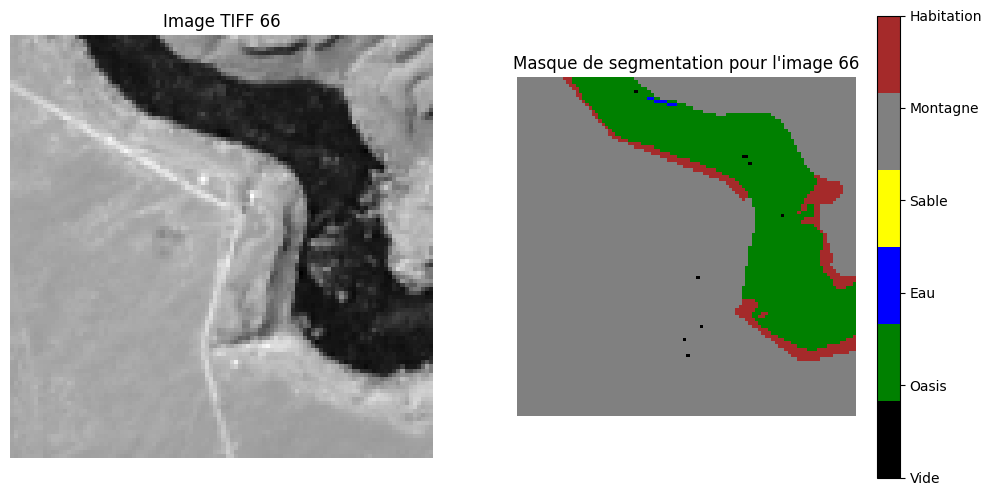

Traitement de l'image TIFF 67...


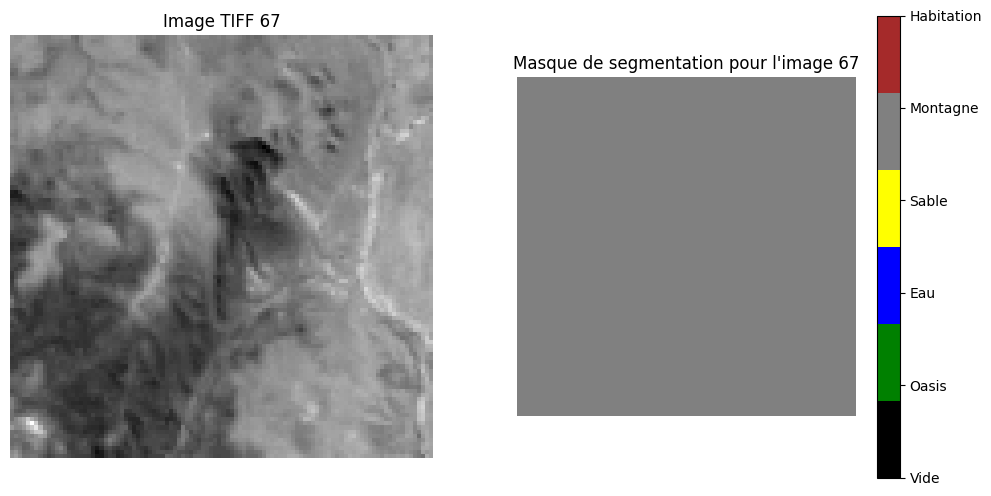

Traitement de l'image TIFF 68...


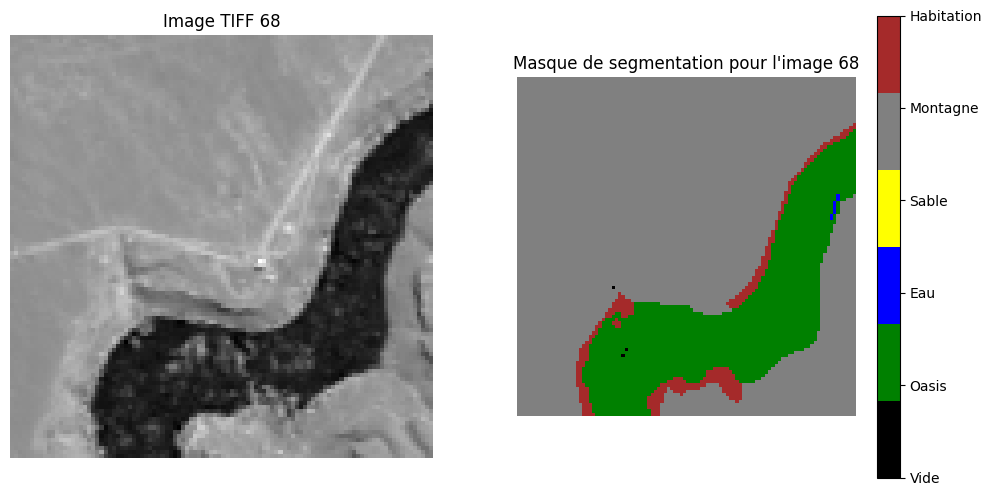

Traitement de l'image TIFF 69...


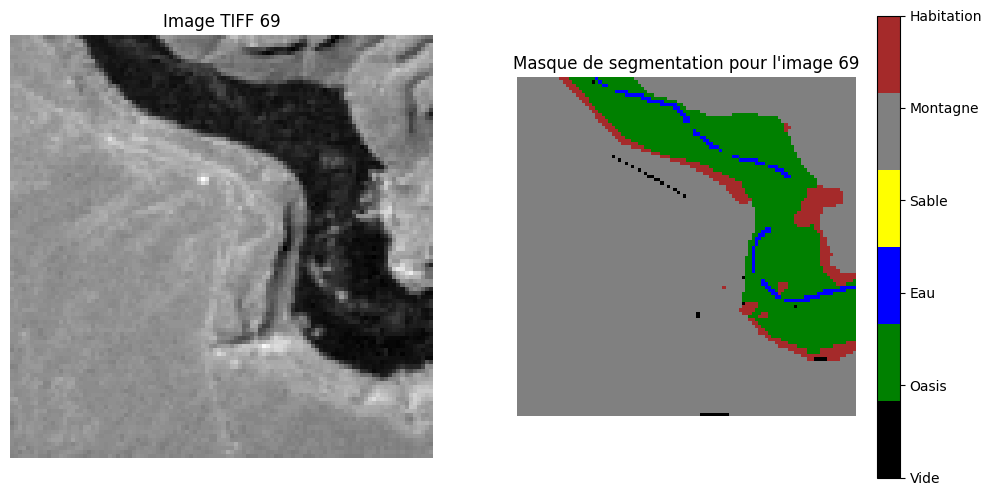

Traitement de l'image TIFF 70...


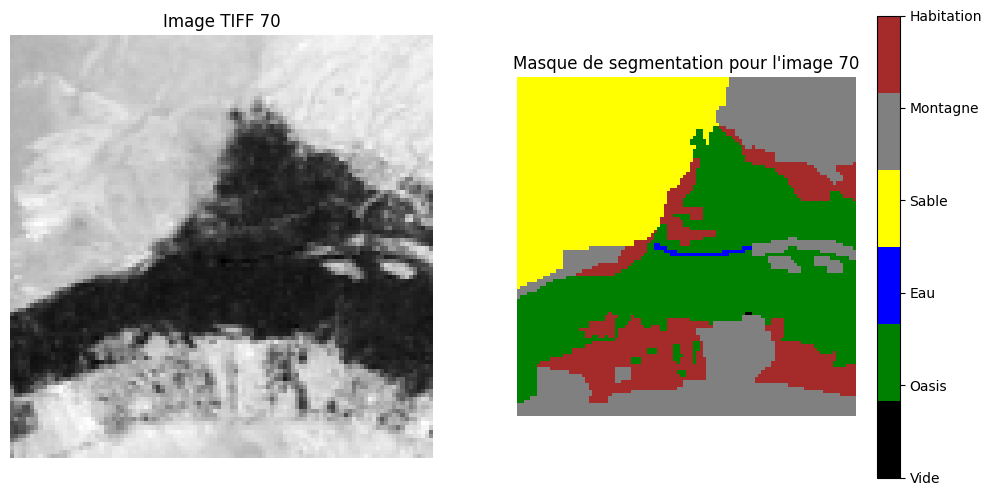

Traitement de l'image TIFF 71...


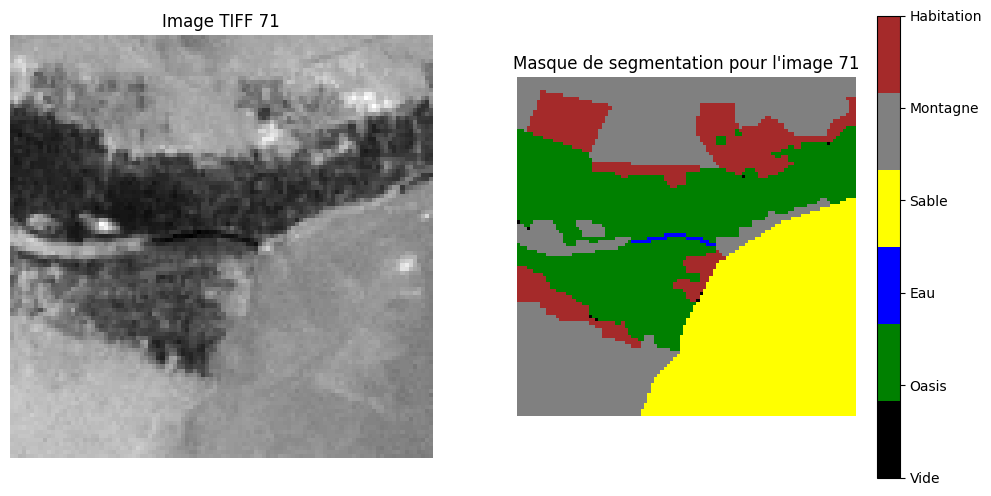

Traitement de l'image TIFF 72...


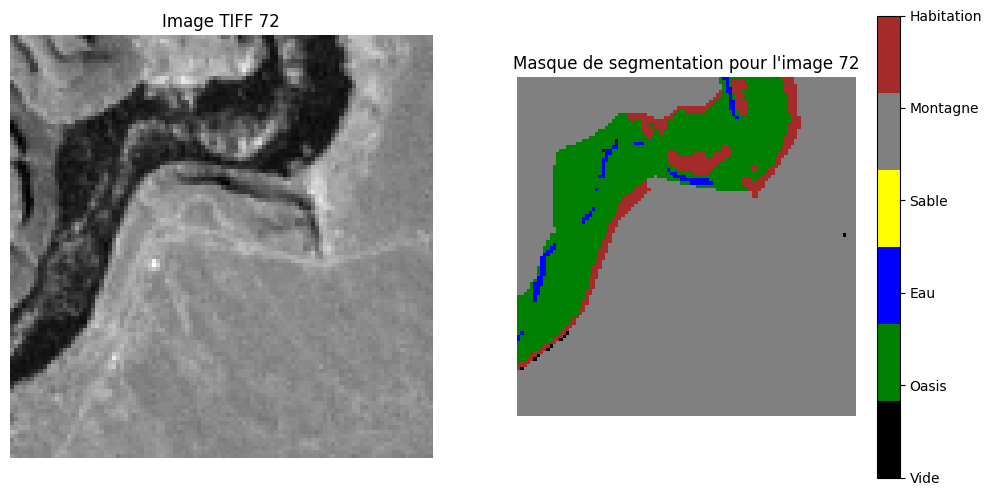

Traitement de l'image TIFF 73...


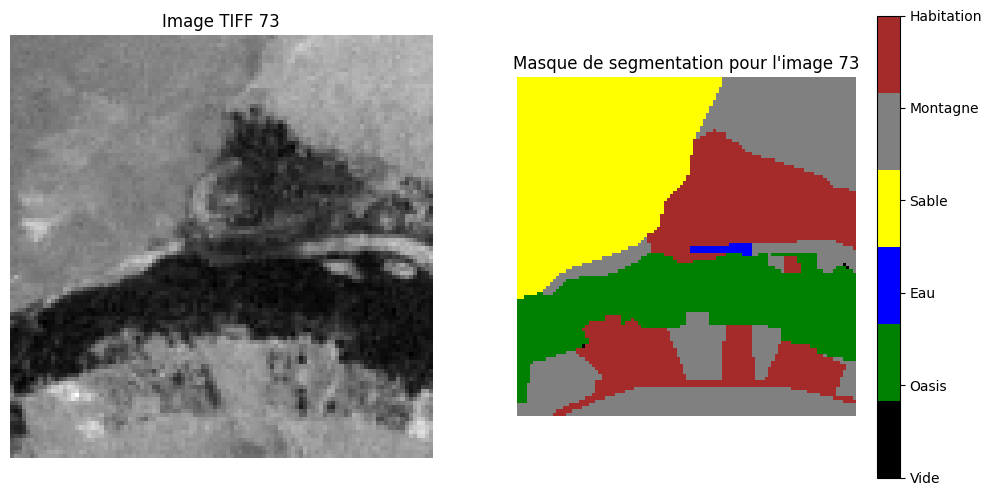

Traitement de l'image TIFF 74...


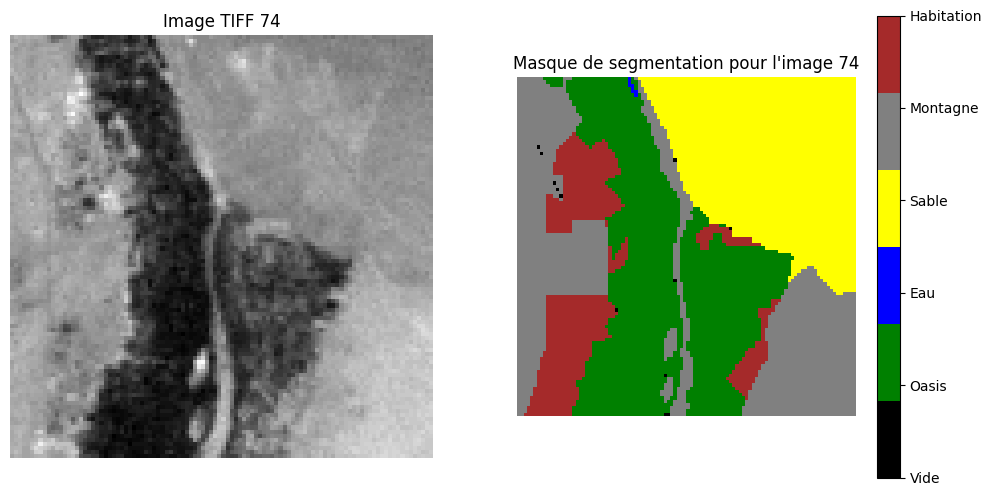

Traitement de l'image TIFF 75...


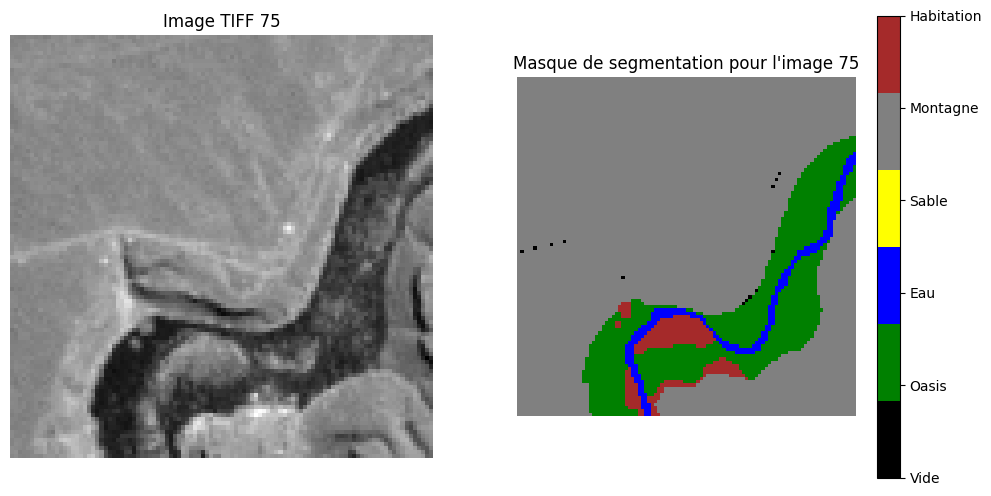

Traitement de l'image TIFF 76...


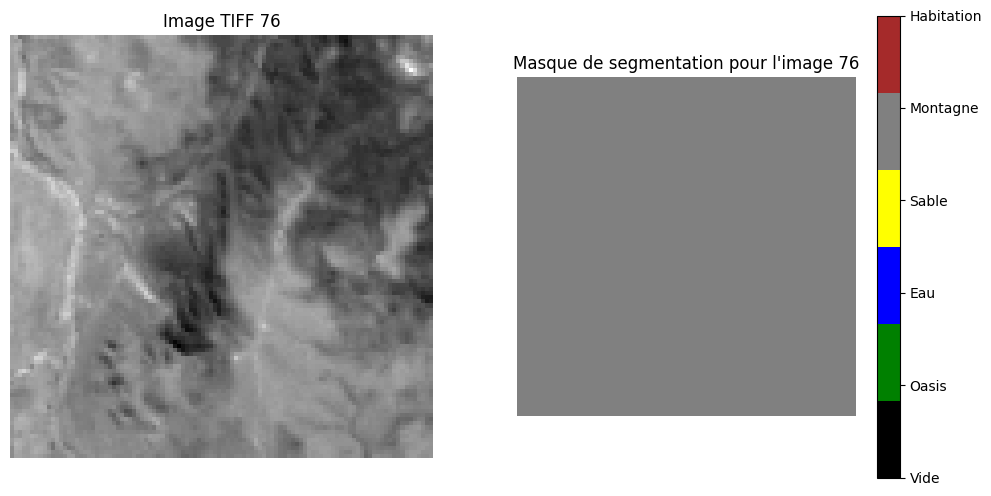

Traitement de l'image TIFF 77...


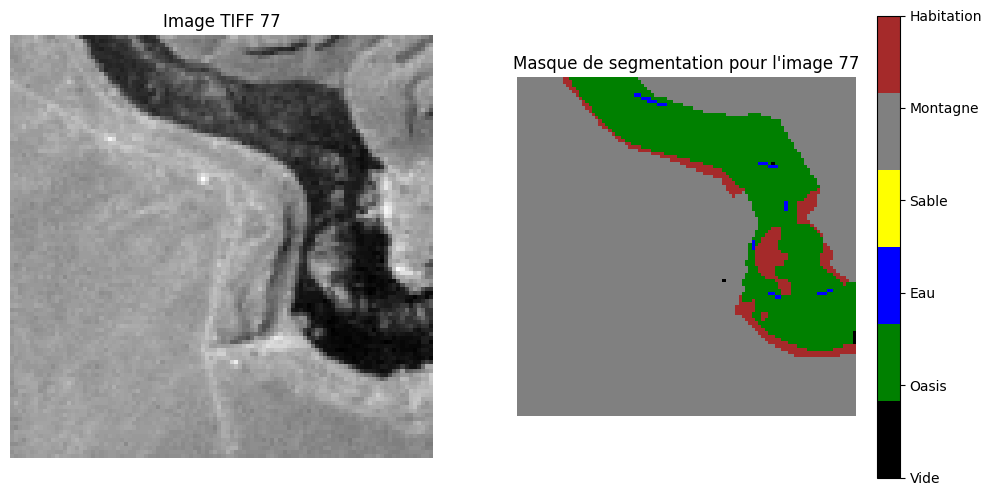

Traitement de l'image TIFF 78...


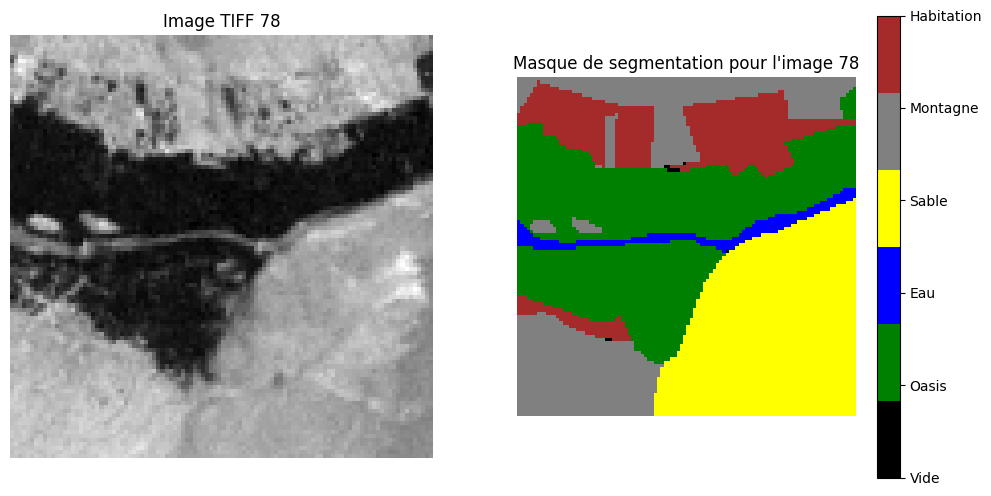

Traitement de l'image TIFF 79...


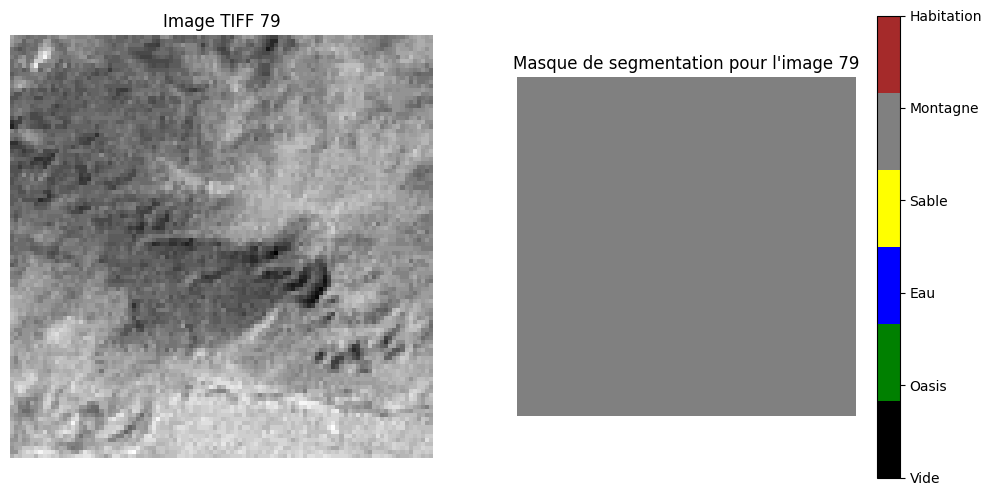

Traitement de l'image TIFF 80...


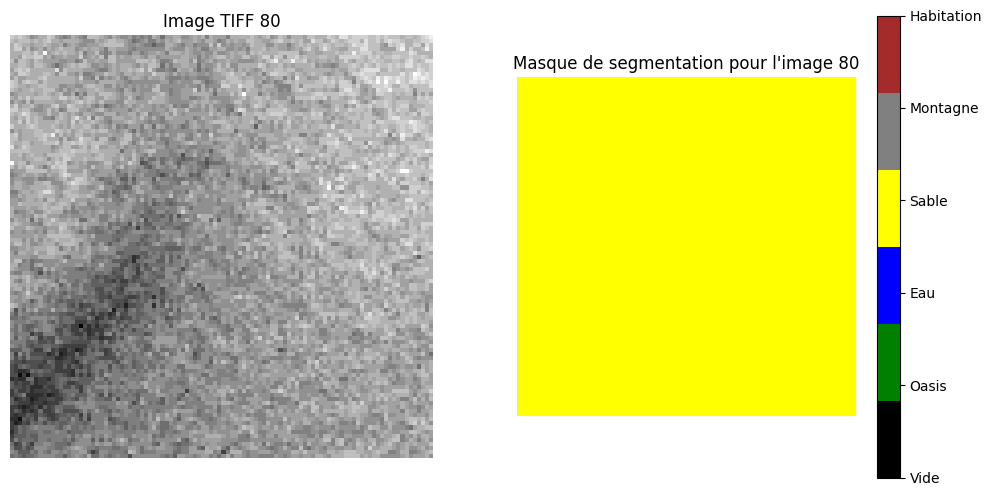

Traitement de l'image TIFF 81...


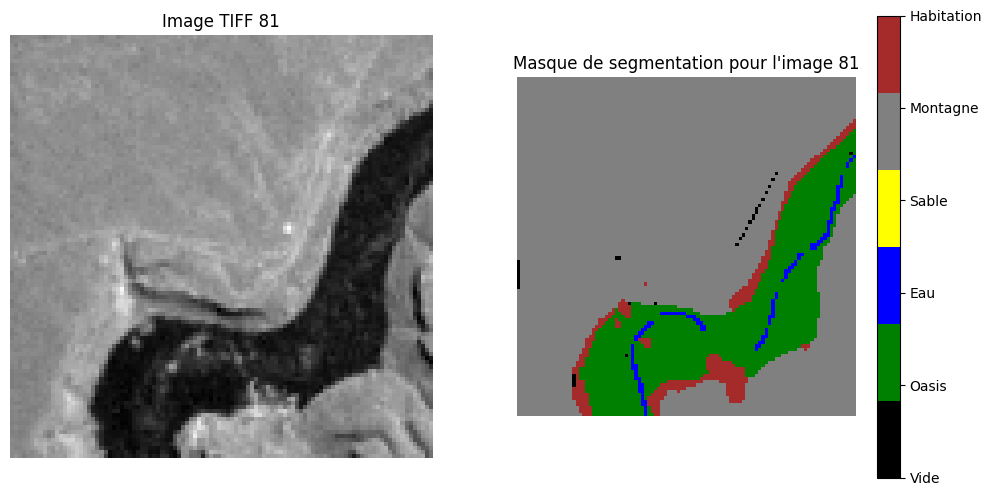

Traitement de l'image TIFF 82...


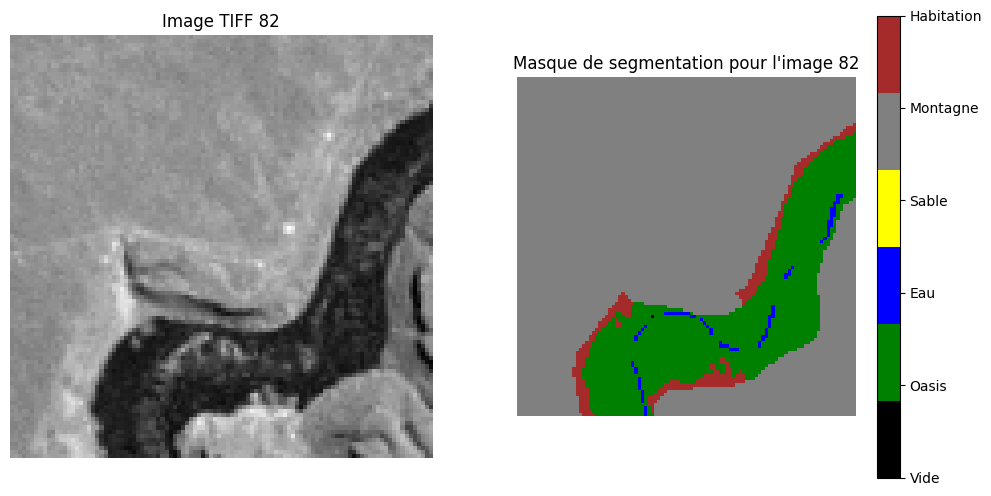

Traitement de l'image TIFF 83...


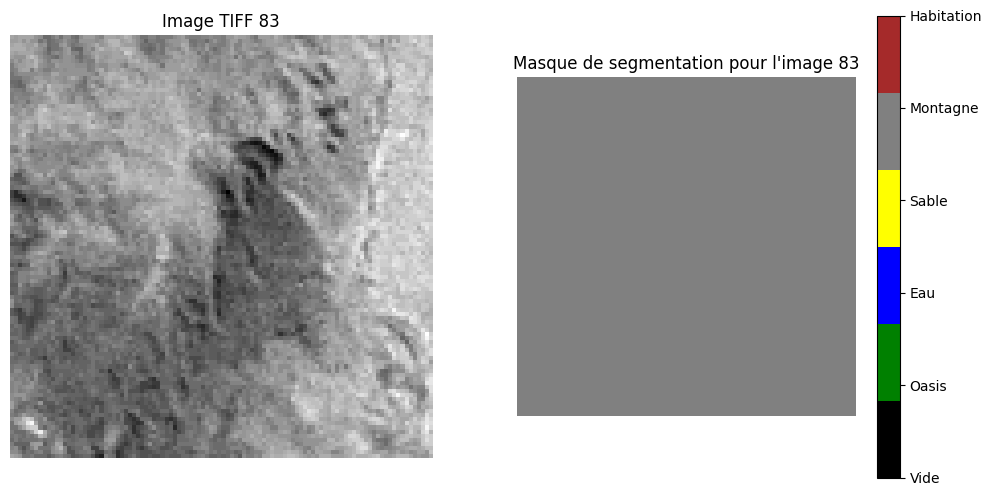

Traitement de l'image TIFF 84...


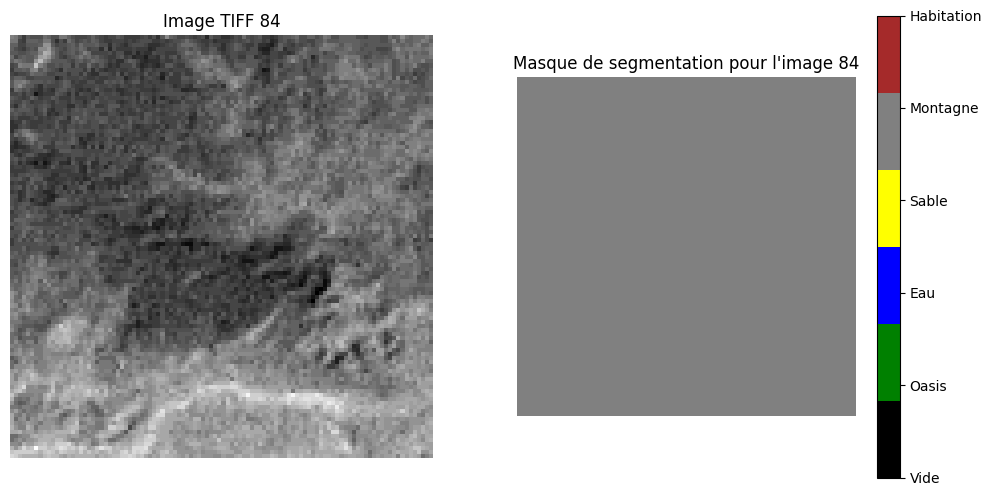

Traitement de l'image TIFF 85...


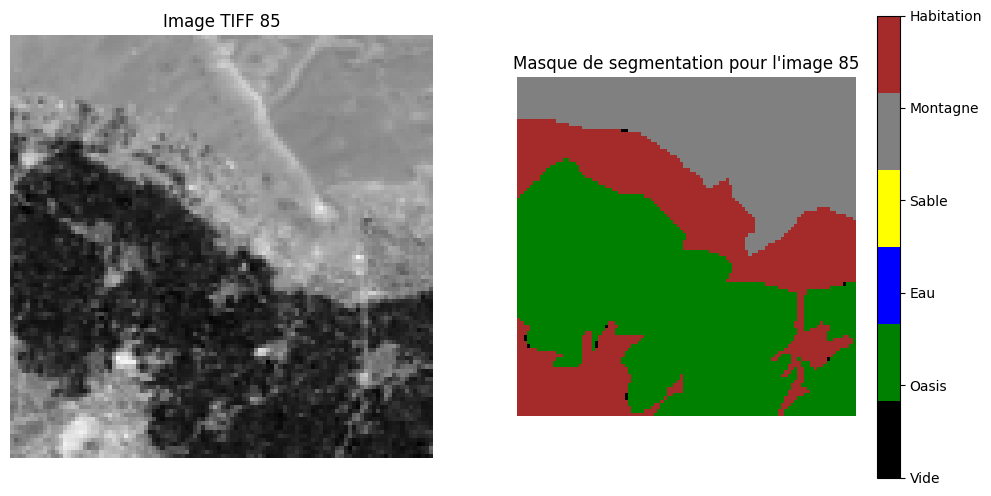

Traitement de l'image TIFF 86...


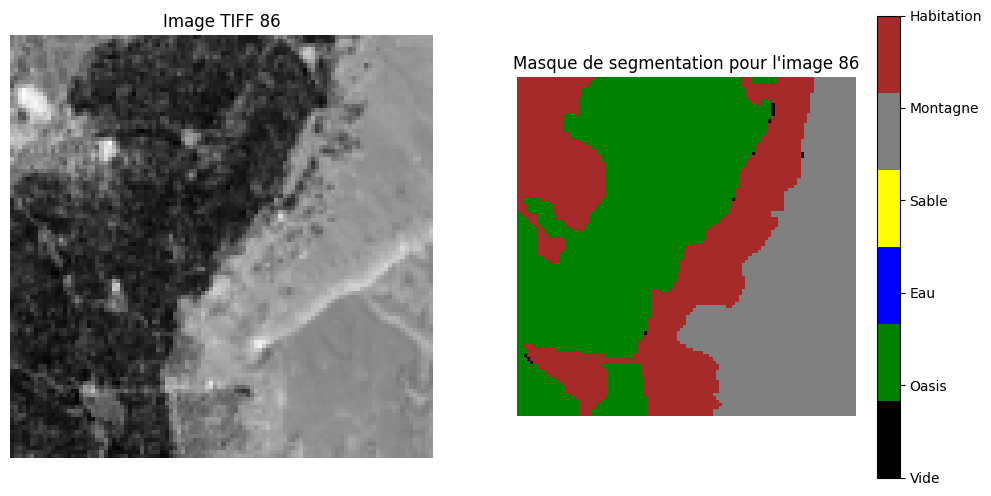

Traitement de l'image TIFF 87...


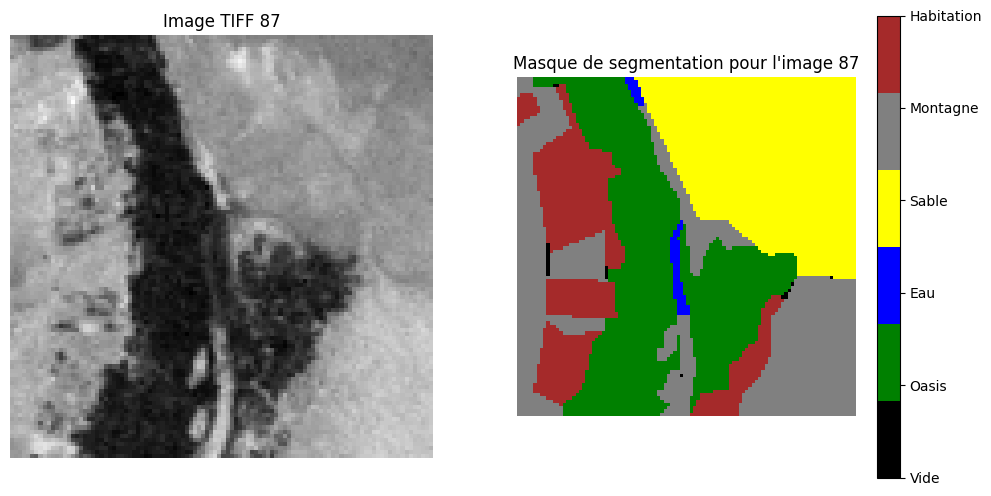

Traitement de l'image TIFF 88...


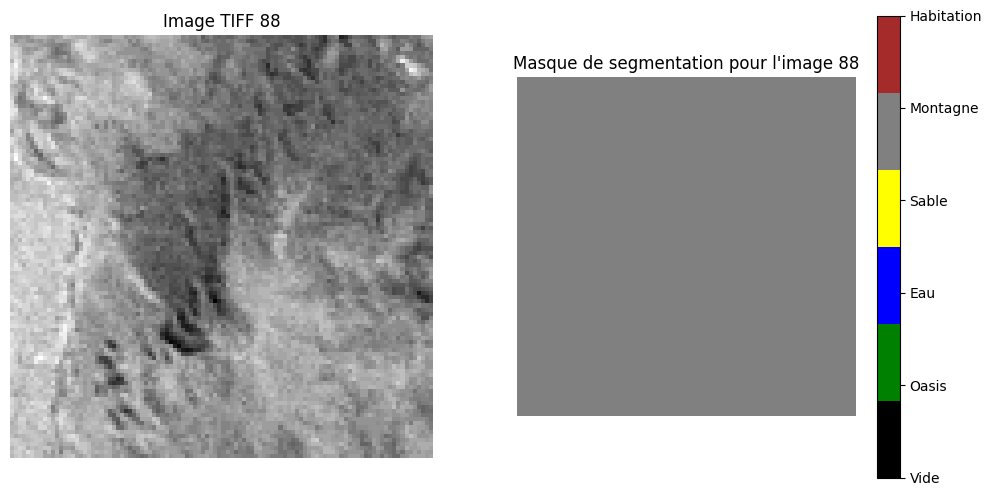

Traitement de l'image TIFF 89...


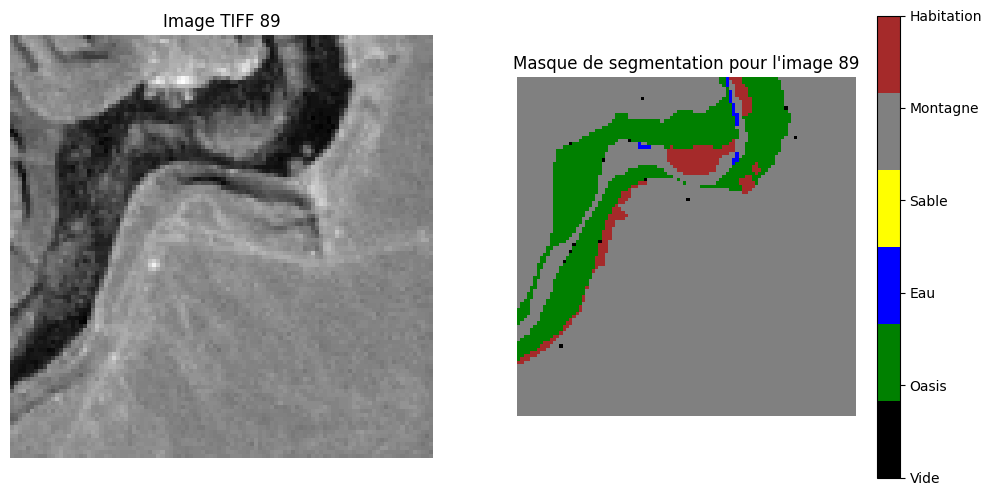

Traitement de l'image TIFF 90...


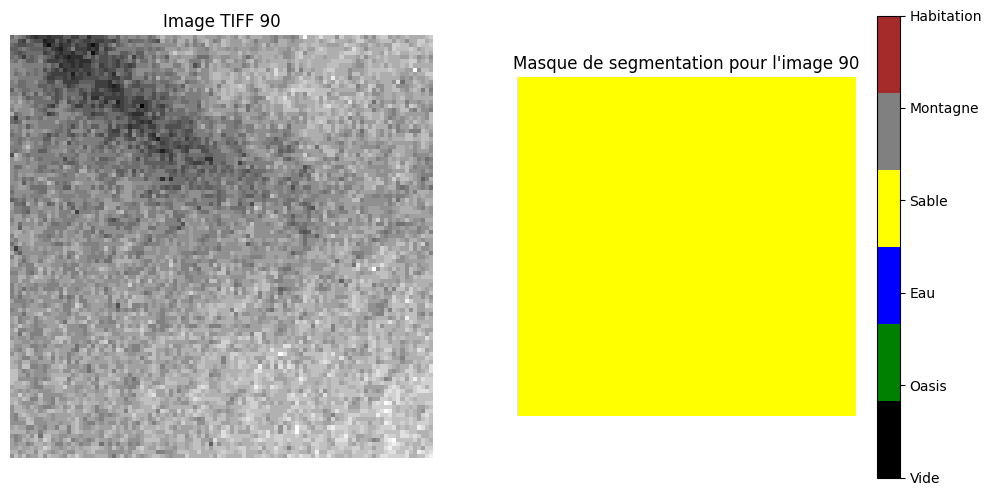

Traitement de l'image TIFF 91...


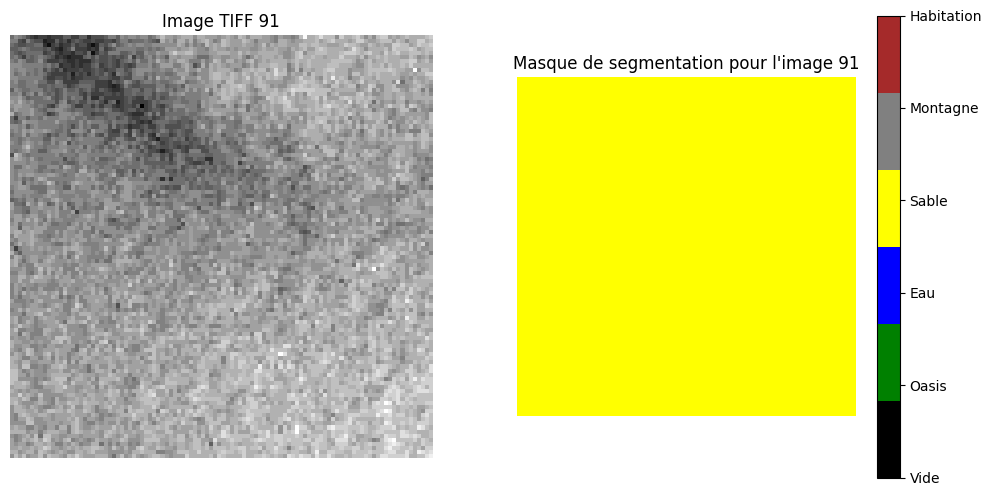

Traitement de l'image TIFF 92...


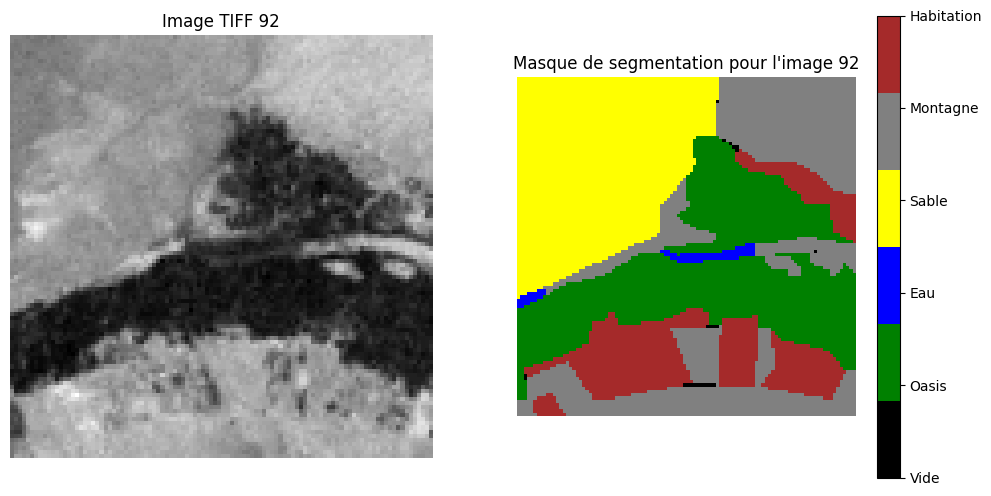

Traitement de l'image TIFF 93...


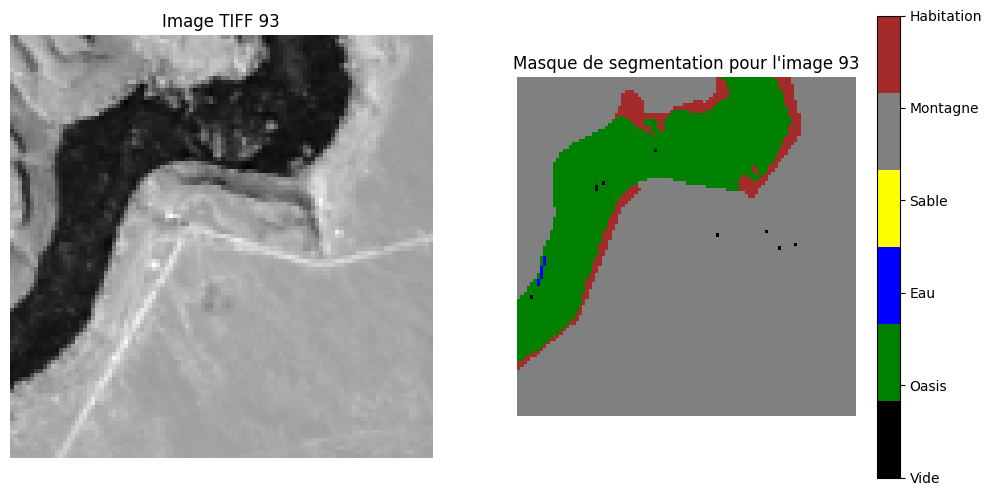

Traitement de l'image TIFF 94...


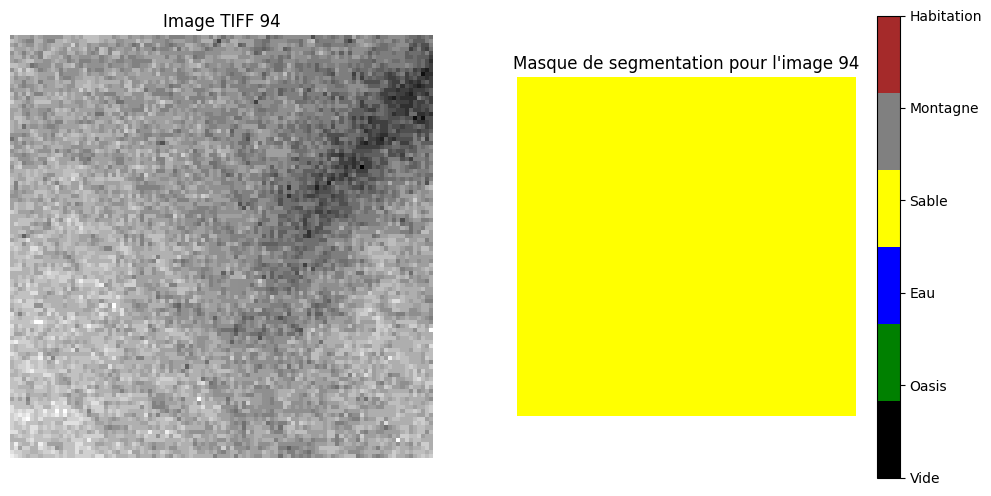

Traitement de l'image TIFF 95...


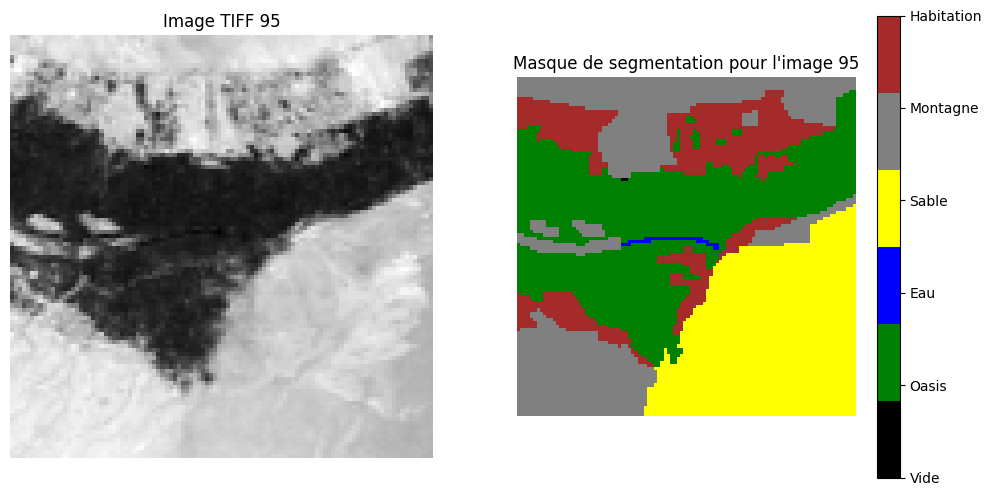

Traitement de l'image TIFF 96...


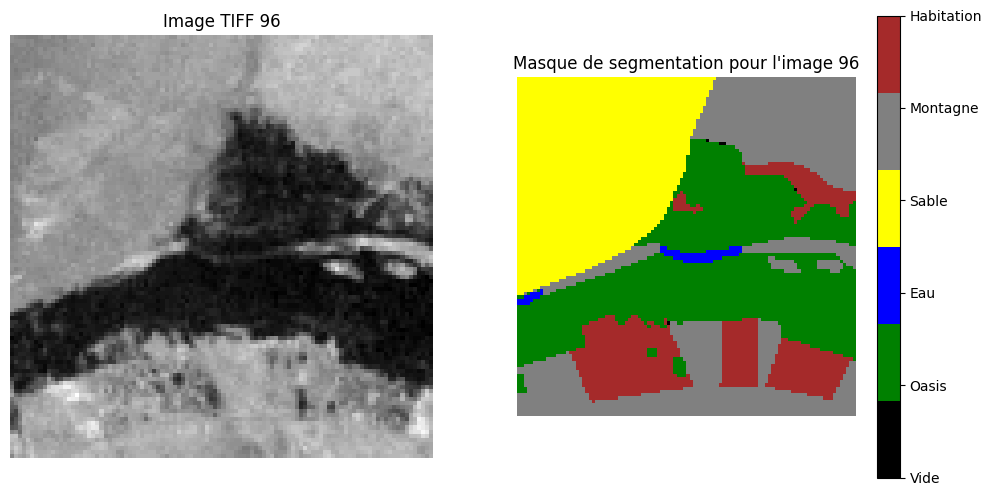

Traitement de l'image TIFF 97...


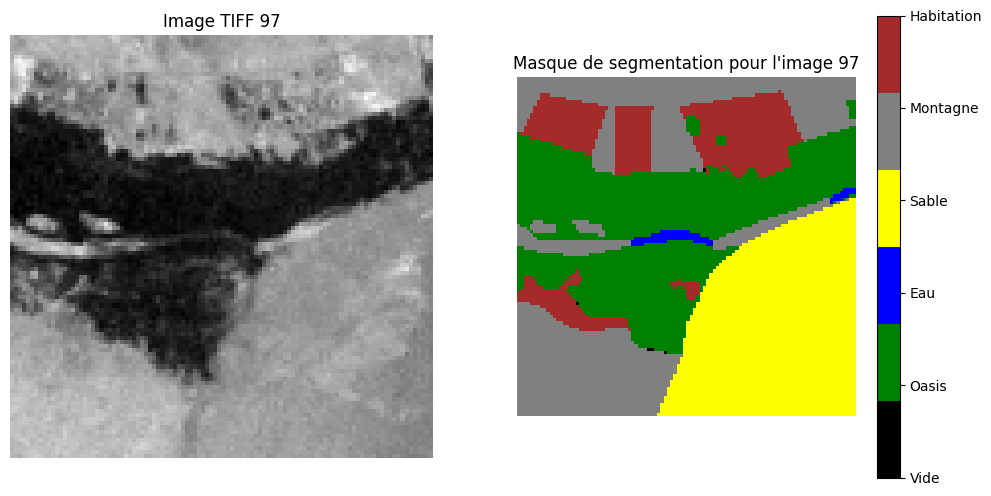

Traitement de l'image TIFF 98...


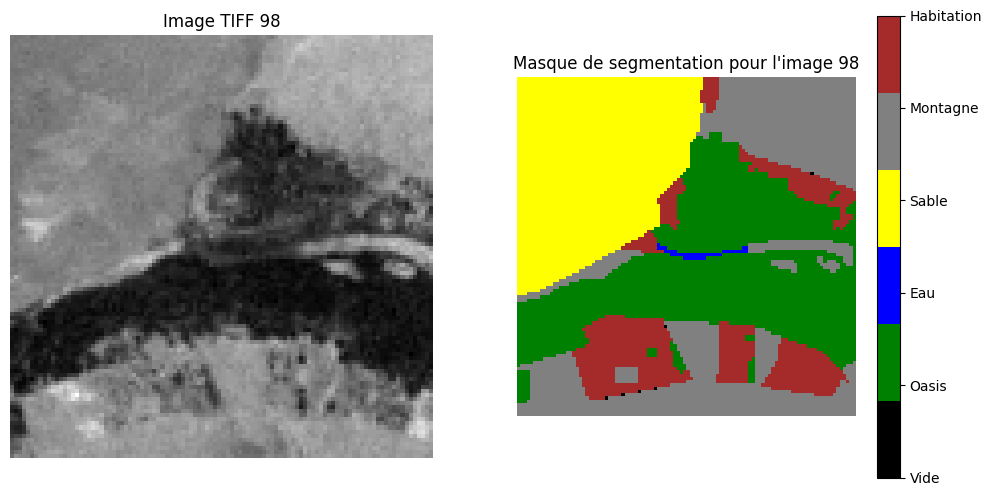

Traitement de l'image TIFF 99...


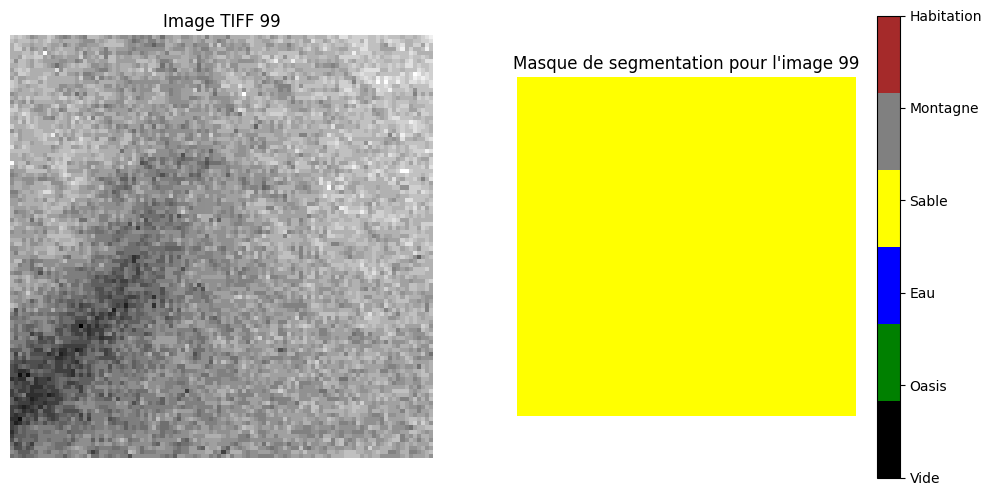

Traitement de l'image TIFF 100...


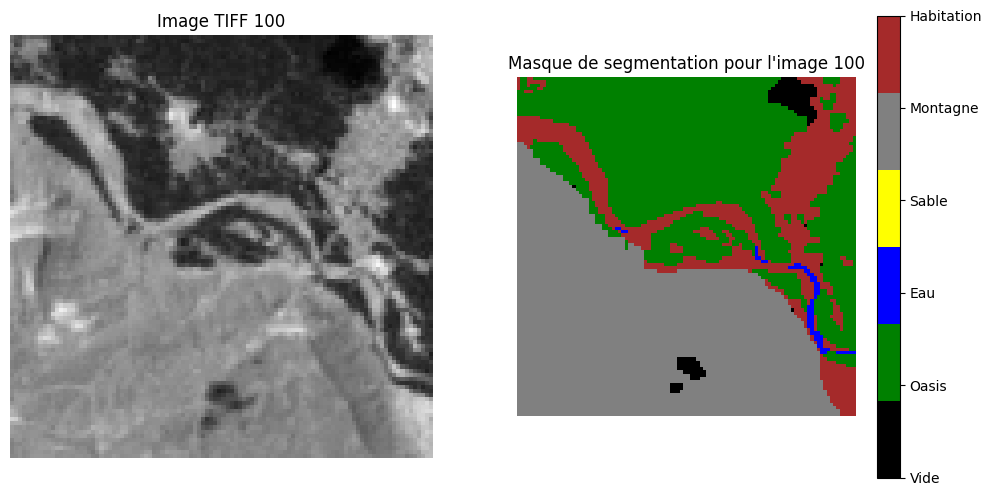

Traitement de l'image TIFF 101...


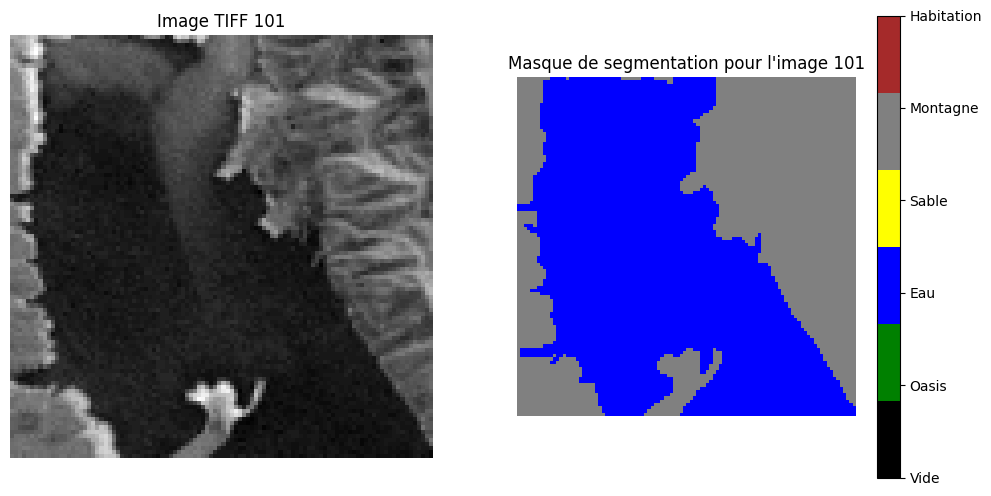

Traitement de l'image TIFF 102...


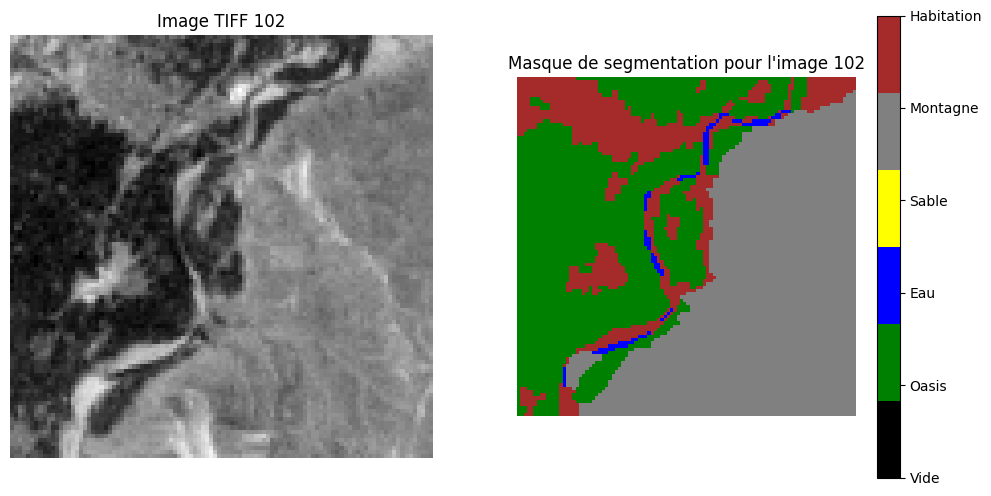

Traitement de l'image TIFF 103...


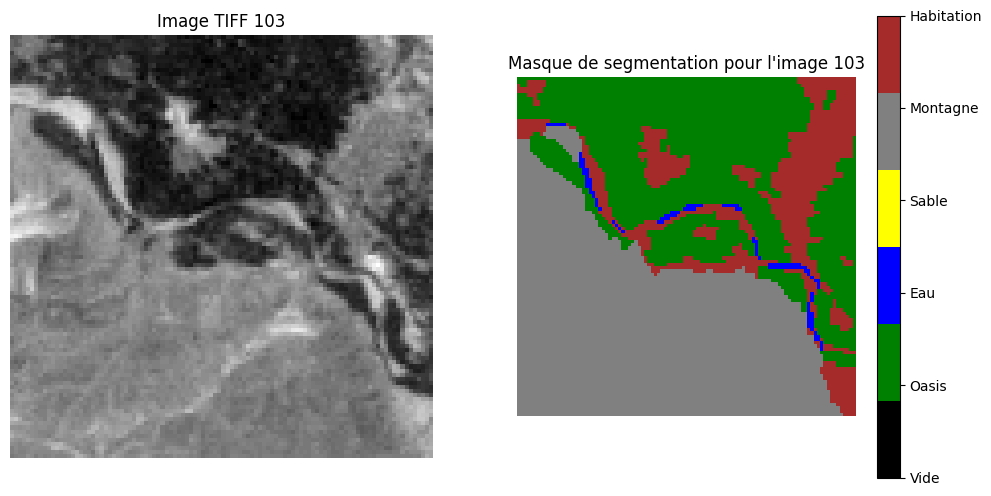

Traitement de l'image TIFF 104...


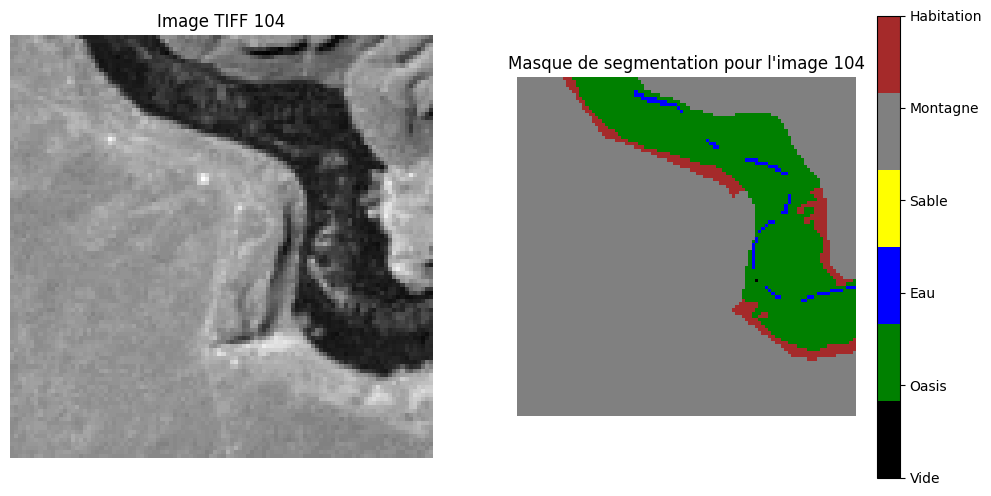

Traitement de l'image TIFF 105...


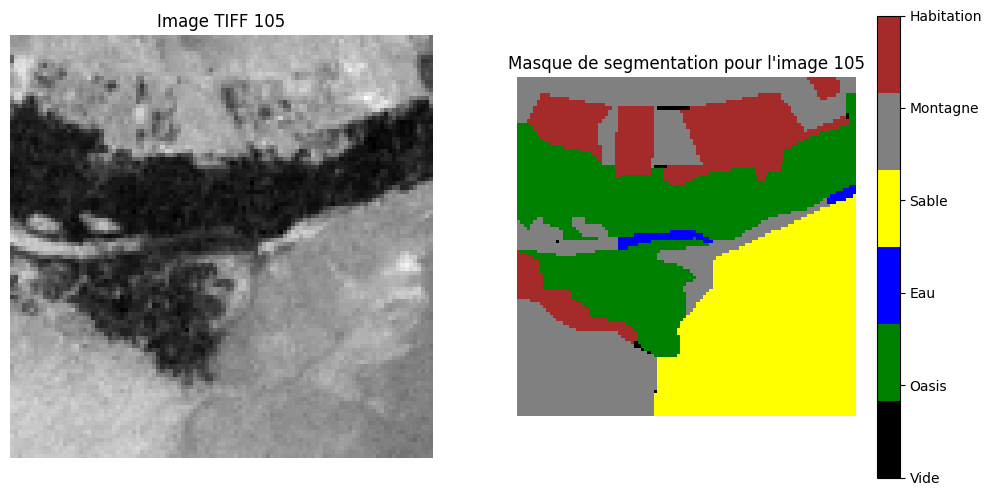

Traitement de l'image TIFF 106...


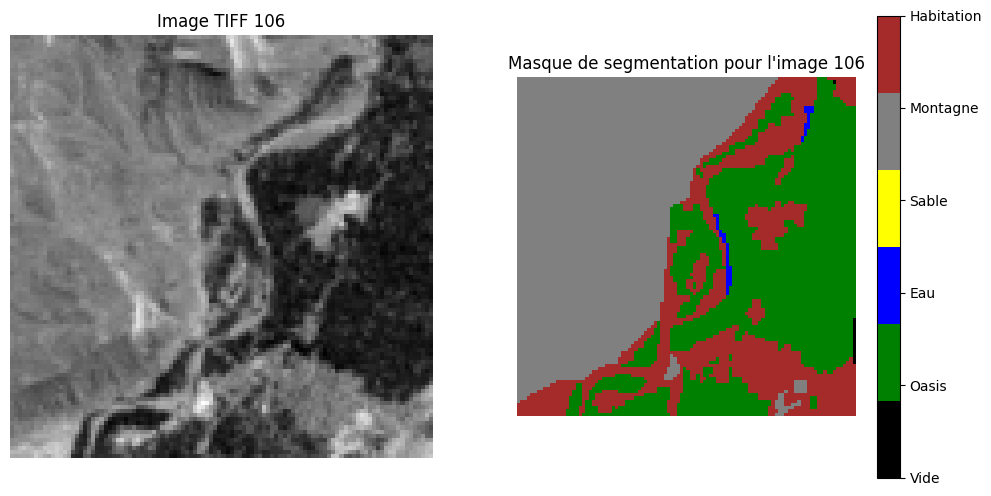

Traitement de l'image TIFF 107...


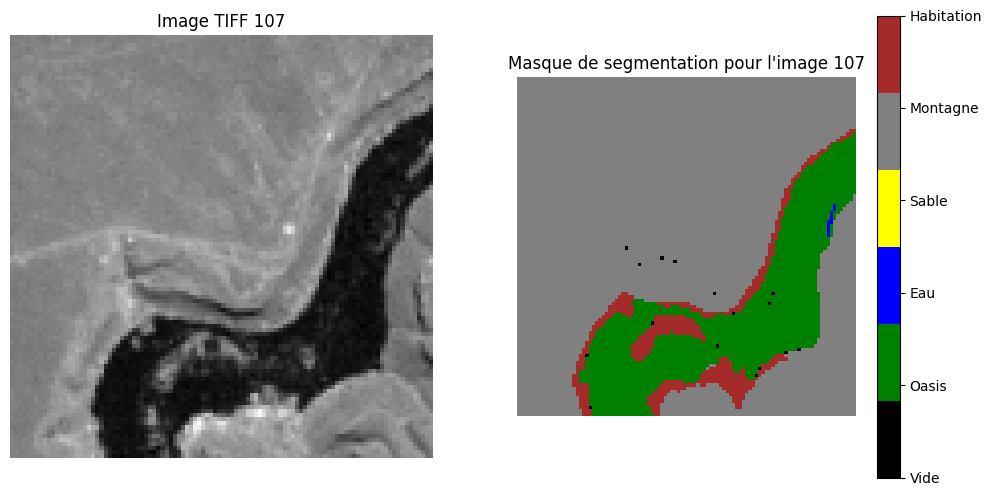

Traitement de l'image TIFF 108...


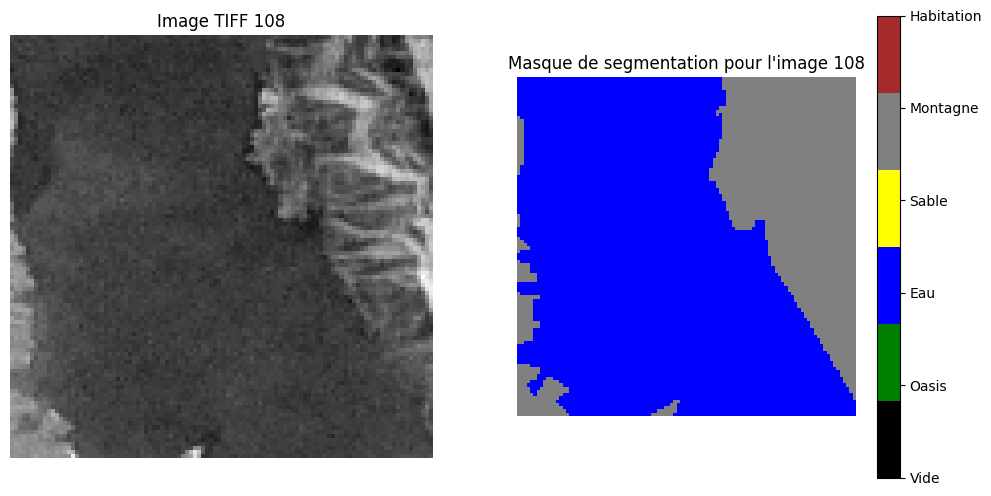

In [ ]:
# Liste pour stocker les masques générés
image_label = []
image_label = affichage_mask(geo_dfs, raster_data, paired_files, image_label)

In [ ]:
def somme_pixels_par_classe(image_label):
    """
    Calcule la somme totale des pixels par classe pour tous les masques dans une liste d'images

    """
    total_distribution = {}

    for mask in image_label:
        classes, counts = np.unique(mask, return_counts=True)

        for cls, count in zip(classes, counts):
            if cls in total_distribution:
                total_distribution[cls] += count
            else:
                total_distribution[cls] = count

    return total_distribution

In [ ]:
def afficher_repartition(total_distribution):
    """
    Affiche la répartition des pixels par classe sous forme de camembert

    """
    # Classes et leurs noms
    class_names = {0: 'Vide', 1: 'Oasis', 2: 'Eau', 3: 'Sable', 4: 'Montagne', 5: 'Habitation'}

    # Préparer les données pour le camembert
    labels = []
    sizes = []

    for cls in range(len(class_names)):
        labels.append(class_names.get(cls, f'Classe {cls}'))
        sizes.append(total_distribution.get(cls, 0))

    # Afficher le camembert
    plt.figure(figsize=(8, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.axis('equal')  # Pour un cercle
    plt.title('Répartition des pixels par classe')
    plt.show()
    print(total_distribution)

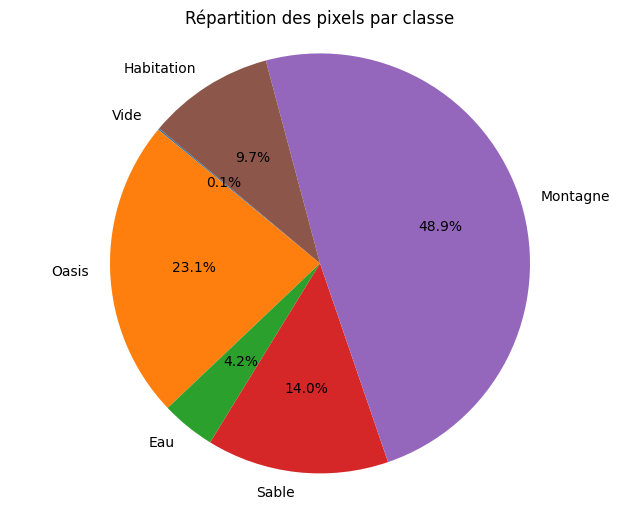

{0: 1314, 1: 269586, 3: 163722, 4: 571242, 5: 113700, 2: 48564}


In [ ]:
somme_pixels = somme_pixels_par_classe(image_label)
afficher_repartition(somme_pixels)

In [ ]:
def dimension_image(paired_files):
  # Boucle sur chaque fichier TIFF dans les paires de fichiers pour redimensionner et stocker les données
  for tif_file, _ in paired_files:  # On n'utilise que le fichier TIFF pour cette partie
      with rasterio.open(tif_file) as dataset:
          # Lire toutes les bandes de l'image
          image_data_x = dataset.read()

          # Transposer les dimensions pour avoir (hauteur, largeur, bandes)
          image_resized_x = np.transpose(image_data_x, (1, 2, 0))

          # Ajouter l'image redimensionnée à la liste
          X_resized.append(image_resized_x)

  # Affichage pour vérifier le nombre d'images redimensionnées chargées
  print(f"Nombre d'images redimensionnées chargées : {len(X_resized)}")
  return X_resized

In [ ]:
X_resized = []
X_resized = dimension_image(paired_files)

Nombre d'images redimensionnées chargées : 108


In [ ]:
def conv_numpy(X,Y):
  X_resized_array = np.array(X)
  print("X_resized_array.shape :",X_resized_array.shape)
  Y_resized = np.array(Y)
  print("Y_resized_array.shape :",Y_resized.shape)
  unique_elements = np.unique(Y_resized)
  print("unique_elements :",unique_elements)
  return X_resized_array, Y_resized,unique_elements

In [ ]:
X_resized_array, Y_resized,unique_elements = conv_numpy(X_resized,image_label)

X_resized_array.shape : (108, 104, 104, 7)
Y_resized_array.shape : (108, 104, 104)
unique_elements : [0 1 2 3 4 5]


In [ ]:
def normalisation(X):
  mean = np.mean(X)
  std = np.std(X)
  X_norm = (X - mean) / std
  return X_norm

In [ ]:
X_resized = normalisation(X_resized)

In [ ]:
def creation_dataset(X_resized,Y_resized):
  # Calcul des tailles
  num_samples = X_resized.shape[0]
  num_validation_samples = int(num_samples * validation_split)
  num_training_samples = num_samples - num_validation_samples

  # Création des indices et mélange
  indices = np.arange(num_samples)
  np.random.shuffle(indices)

  train_indices = indices[:num_training_samples]
  val_indices = indices[num_training_samples:]

  # Création des ensembles d'entraînement et de validation
  X_train = X_resized[train_indices]
  Y_train = Y_resized[train_indices]

  X_val = X_resized[val_indices]
  Y_val = Y_resized[val_indices]

  # Création des datasets TensorFlow
  train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
  train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

  val_dataset = tf.data.Dataset.from_tensor_slices((X_val, Y_val))
  val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
  for images, masks in train_dataset.take(1):
    print(f"Train batch shape: {images.shape}, {masks.shape}")

  for images, masks in val_dataset.take(1):
    print(f"Validation batch shape: {images.shape}, {masks.shape}")

  return train_dataset, val_dataset

In [ ]:
train_dataset, val_dataset = creation_dataset(X_resized,Y_resized)

Train batch shape: (15, 104, 104, 7), (15, 104, 104)
Validation batch shape: (12, 104, 104, 7), (12, 104, 104)


## MODELE UNET

In [ ]:
def model_unet(input_size, num_classes):
    inputs = Input(input_size)

    # Encodeur
    conv1 = Conv2D(nb_filtre_1, kernel_1, activation='relu', padding='same', kernel_initializer=HeNormal())(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = Conv2D(nb_filtre_1, kernel_1, activation='relu', padding='same', kernel_initializer=HeNormal())(conv1)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(nb_filtre_2, kernel_2, activation='relu', padding='same', kernel_initializer=HeNormal())(pool1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Conv2D(nb_filtre_2, kernel_2, activation='relu', padding='same', kernel_initializer=HeNormal())(conv2)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(nb_filtre_3, kernel_3, activation='relu', padding='same', kernel_initializer=HeNormal())(pool2)
    conv3 = BatchNormalization()(conv3)
    conv3 = Conv2D(nb_filtre_3, kernel_3, activation='relu', padding='same', kernel_initializer=HeNormal())(conv3)
    conv3 = BatchNormalization()(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    convb = Conv2D(nb_filtre_4, kernel_4, activation='relu', padding='same', kernel_initializer=HeNormal())(pool3)
    convb = BatchNormalization()(convb)
    convb = Conv2D(nb_filtre_4, kernel_4, activation='relu', padding='same', kernel_initializer=HeNormal())(convb)
    convb = BatchNormalization()(convb)

    # Decodeur
    up4 = Conv2DTranspose(nb_filtre_3, (2, 2), strides=(2, 2), padding='same', kernel_initializer=HeNormal())(convb)
    merge4 = concatenate([conv3, up4], axis=3)

    # Appliquer le bloc d'attention
    #attention4 = AttentionBlock(256)([conv3, up4])
    conv4 = Conv2D(nb_filtre_3, kernel_3, activation='relu', padding='same', kernel_initializer=HeNormal())(merge4)
    conv4 = BatchNormalization()(conv4)
    conv4 = Conv2D(nb_filtre_3, kernel_3, activation='relu', padding='same', kernel_initializer=HeNormal())(conv4)
    conv4 = BatchNormalization()(conv4)

    up5 = Conv2DTranspose(nb_filtre_2, (2, 2), strides=(2, 2), padding='same', kernel_initializer=HeNormal())(conv4)
    merge5 = concatenate([conv2, up5], axis=3)

    # Appliquer le bloc d'attention
    #attention5 = AttentionBlock(128)([conv2, up5])
    conv5 = Conv2D(nb_filtre_2, kernel_2, activation='relu', padding='same', kernel_initializer=HeNormal())(merge5)
    conv5 = BatchNormalization()(conv5)
    conv5 = Conv2D(nb_filtre_2, kernel_2, activation='relu', padding='same', kernel_initializer=HeNormal())(conv5)
    conv5 = BatchNormalization()(conv5)

    up6 = Conv2DTranspose(nb_filtre_1, (2, 2), strides=(2, 2), padding='same', kernel_initializer=HeNormal())(conv5)
    merge6 = concatenate([conv1, up6], axis=3)

    # Appliquer le bloc d'attention
    #attention6 = AttentionBlock(64)([conv1, up6])
    conv6 = Conv2D(nb_filtre_1, kernel_1, activation='relu', padding='same', kernel_initializer=HeNormal())(merge6)
    conv6 = BatchNormalization()(conv6)
    conv6 = Conv2D(nb_filtre_1, kernel_1, activation='relu', padding='same', kernel_initializer=HeNormal())(conv6)
    conv6 = BatchNormalization()(conv6)

    output = Conv2D(num_classes, 1, activation='softmax', kernel_initializer=HeNormal())(conv6)

    # Créer le modèle
    model = Model(inputs, output)
    return model

In [ ]:
unet = model_unet(input_size, num_classes)

In [ ]:
def masked_sparse_categorical_crossentropy(y_true, y_pred):
    """
    Calculer la perte sparse_categorical_crossentropy en ignorant la classe 0 (pixels non labélisés)
    """
    # Créer un masque pour les pixels non labélisés (classe 0)
    mask = tf.not_equal(y_true, 0)

    # Appliquer le masque à y_true et y_pred
    y_true_masked = tf.boolean_mask(y_true, mask)
    y_pred_masked = tf.boolean_mask(y_pred, mask)

    # Calculer la perte sparse_categorical_crossentropy
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true_masked, y_pred_masked)

    # Calculer la moyenne de la perte
    return tf.reduce_mean(loss)

Definition de l'IoU par classe, pour suivre la métrique avec le déséquilibre des classes

In [ ]:
class IoUPerClassMetric(tf.keras.metrics.Metric):
    def __init__(self, num_classes, ignore_class=None, name="iou_per_class", **kwargs):
        super(IoUPerClassMetric, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.ignore_class = ignore_class if ignore_class is not None else []
        self.confusion_matrix = self.add_weight(
            shape=(num_classes, num_classes), initializer="zeros", dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(tf.argmax(y_pred, axis=-1), [-1])
        mask = tf.reduce_all([tf.not_equal(y_true, c) for c in self.ignore_class], axis=0)
        y_true = tf.boolean_mask(y_true, mask)
        y_pred = tf.boolean_mask(y_pred, mask)
        confusion = tf.math.confusion_matrix(y_true, y_pred, num_classes=self.num_classes)
        self.confusion_matrix.assign_add(tf.cast(confusion, tf.float32))

    def result(self):
        intersection = tf.linalg.diag_part(self.confusion_matrix)
        union = (
            tf.reduce_sum(self.confusion_matrix, axis=0)
            + tf.reduce_sum(self.confusion_matrix, axis=1)
            - intersection
        )
        iou_per_class = tf.math.divide_no_nan(intersection, union)
        return iou_per_class

    def reset_states(self):
        self.confusion_matrix.assign(tf.zeros_like(self.confusion_matrix))

    def get_config(self):
        # Ajoutez les paramètres nécessaires pour recréer l'objet
        config = super(IoUPerClassMetric, self).get_config()
        config.update({
            "num_classes": self.num_classes,
            "ignore_class": self.ignore_class,
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Recréez l'objet à partir de la configuration
        return cls(**config)


In [ ]:
class IoUCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        iou_values = logs.get('iou_per_class')
        if iou_values is not None:
            print(f"\nEpoch {epoch + 1} IoU per class: {iou_values.numpy()}")


In [ ]:
mean_iou = tf.keras.metrics.MeanIoU(num_classes=num_classes, ignore_class=[0], sparse_y_true=True, sparse_y_pred=False, name='mean_iou')
iou_per_class = IoUPerClassMetric(num_classes=num_classes, ignore_class=[0])
unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_sparse_categorical_crossentropy,
    metrics=[
        'accuracy',
        mean_iou,
        iou_per_class
    ]
)

In [ ]:
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 104, 104, 7)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 104, 104, 64)   │         11,264 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 104, 104, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 104, 104, 64)   │        102,464 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 104, 104, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 52, 52, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 52, 52, 128)    │        204,928 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 52, 52, 128)    │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 52, 52, 128)    │        409,728 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 52, 52, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 26, 26, 128)    │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 26, 26, 256)    │        819,456 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 26, 26, 256)    │          1,024 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 26, 26, 256)    │      1,638,656 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 26, 26, 256)    │          1,024 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2      

 Total params: 20,170,246 (76.94 MB)

 Trainable params: 20,164,614 (76.92 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [ ]:
history = unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=150,
    callbacks=[IoUCallback()],
)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9926 - iou_per_class: 0.8199 - loss: 0.0228 - mean_iou: 0.9839   
Epoch 1 IoU per class: [0.         0.9834885  0.98980564 0.99314475 0.9871888  0.92933124]
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.9922 - iou_per_class: 0.8192 - loss: 0.0240 - mean_iou: 0.9830 - val_accuracy: 0.9352 - val_iou_per_class: 0.5571 - val_loss: 0.3421 - val_mean_iou: 0.6685
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9769 - iou_per_class: 0.7878 - loss: 0.0746 - mean_iou: 0.9454
Epoch 2 IoU per class: [0.        0.9603877 0.9724476 0.9849429 0.9716178 0.8601984]
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.9770 - iou_per_class: 0.7883 - loss: 0.0739 - mean_iou: 0.9459 - val_accuracy: 0.9445 - val_iou_per_class: 0.5853 - val_loss: 0.2791 - val_mean_iou: 0.7023
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9734 - iou_per_class: 0.7799 - loss: 0.0807 - mean_iou: 0.9358
Epoch 3 IoU per class: [

## AFFICHAGE DES COURBES D'ENTRAINEMENTS

In [ ]:
def plot_training_history(history, num_classes):
    """
    Tracer les métriques d'entraînement et de validation, ainsi que l'IoU par classe.
    :param history: l'historique de l'entraînement (history).
    :param num_classes: nombre total de classes (utilisé pour IoU par classe).
    """
    plt.figure(figsize=(20, 10))

    # Graphique 1 : Perte
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Perte (train)', color='blue')
    plt.plot(history.history['val_loss'], label='Perte (validation)', color='orange')
    plt.title('Perte au fil des époques')
    plt.xlabel('Époque')
    plt.ylabel('Perte')
    plt.legend()

    # Graphique 2 : Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy (train)', color='blue')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)', color='orange')
    plt.title('Accuracy au fil des époques')
    plt.xlabel('Époque')
    plt.ylabel('Accuracy')
    plt.legend()

    # Graphique 3 : Mean IoU
    plt.subplot(2, 2, 3)
    plt.plot(history.history['mean_iou'], label='Mean IoU (train)', color='blue')
    plt.plot(history.history['val_mean_iou'], label='Mean IoU (validation)', color='orange')
    plt.title('Mean IoU au fil des époques')
    plt.xlabel('Époque')
    plt.ylabel('Mean IoU')
    plt.legend()

    # Graphique 4 : IoU par classe
    plt.subplot(2, 2, 4)
    iou_per_class_train = history.history.get('iou_per_class', None)
    iou_per_class_val = history.history.get('val_iou_per_class', None)

    if iou_per_class_train and iou_per_class_val:
        epochs = range(len(iou_per_class_train))
        colors = plt.cm.get_cmap('tab10', num_classes).colors  # Palette avec une couleur par classe

        for class_idx in range(num_classes):
            # Récupérer les IoU pour cette classe (train et val)
            train_class_iou = [epoch[class_idx] for epoch in iou_per_class_train]
            val_class_iou = [epoch[class_idx] for epoch in iou_per_class_val]

            # Tracer les courbes avec une couleur spécifique pour chaque classe
            plt.plot(epochs, train_class_iou, label=f'Classe {class_idx} (train)', color=colors[class_idx], linestyle='-')
            plt.plot(epochs, val_class_iou, label=f'Classe {class_idx} (validation)', color=colors[class_idx], linestyle='--')

        plt.title('IoU par classe au fil des époques')
        plt.xlabel('Époque')
        plt.ylabel('IoU')
        plt.legend()

    plt.tight_layout()
    plt.show()


<ipython-input-69-ff4984a2af3a>:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes).colors  # Palette avec une couleur par classe


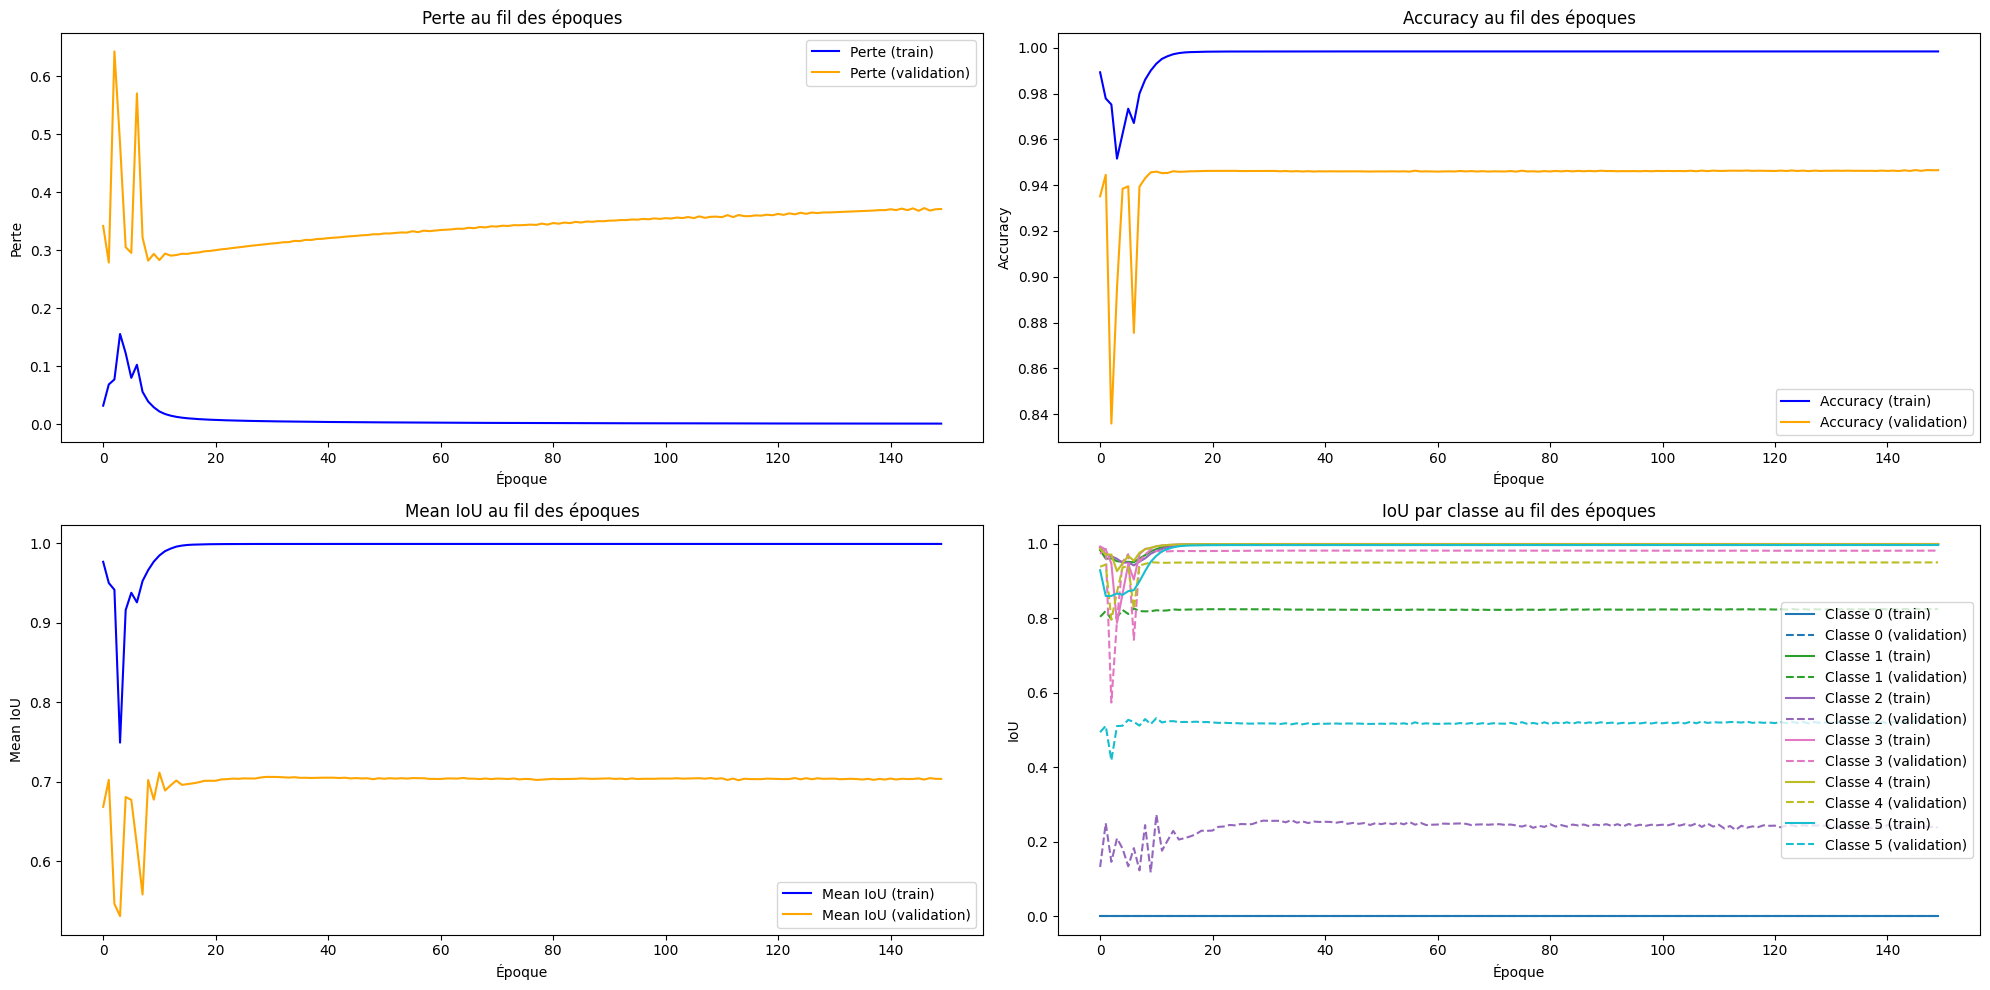

In [ ]:
plot_training_history(history, num_classes=num_classes)

In [ ]:
def plot_training_history(history):
    # Tracer la perte
    plt.figure(figsize=(18, 5))

    # Sous-figure pour la perte
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Perte (train)')
    plt.plot(history.history['val_loss'], label='Perte (validation)')
    plt.title('Perte au fil des époques')
    plt.xlabel('Époque')
    plt.ylabel('Perte')
    plt.legend()

    # Sous-figure pour l'IoU
    plt.subplot(1, 3, 2)
    plt.plot(history.history['mean_iou'], label='IoU (train)', linestyle='--')
    plt.plot(history.history['val_mean_iou'], label='IoU (validation)', linestyle='--')
    plt.title('IoU au fil des époques')
    plt.xlabel('Époque')
    plt.ylabel('IoU')
    plt.legend()

    # Sous-figure pour l'accuracy
    plt.subplot(1, 3, 3)
    plt.plot(history.history['accuracy'], label='Accuracy (train)')
    plt.plot(history.history['val_accuracy'], label='Accuracy (validation)')
    plt.title('Accuracy au fil des époques')
    plt.xlabel('Époque')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

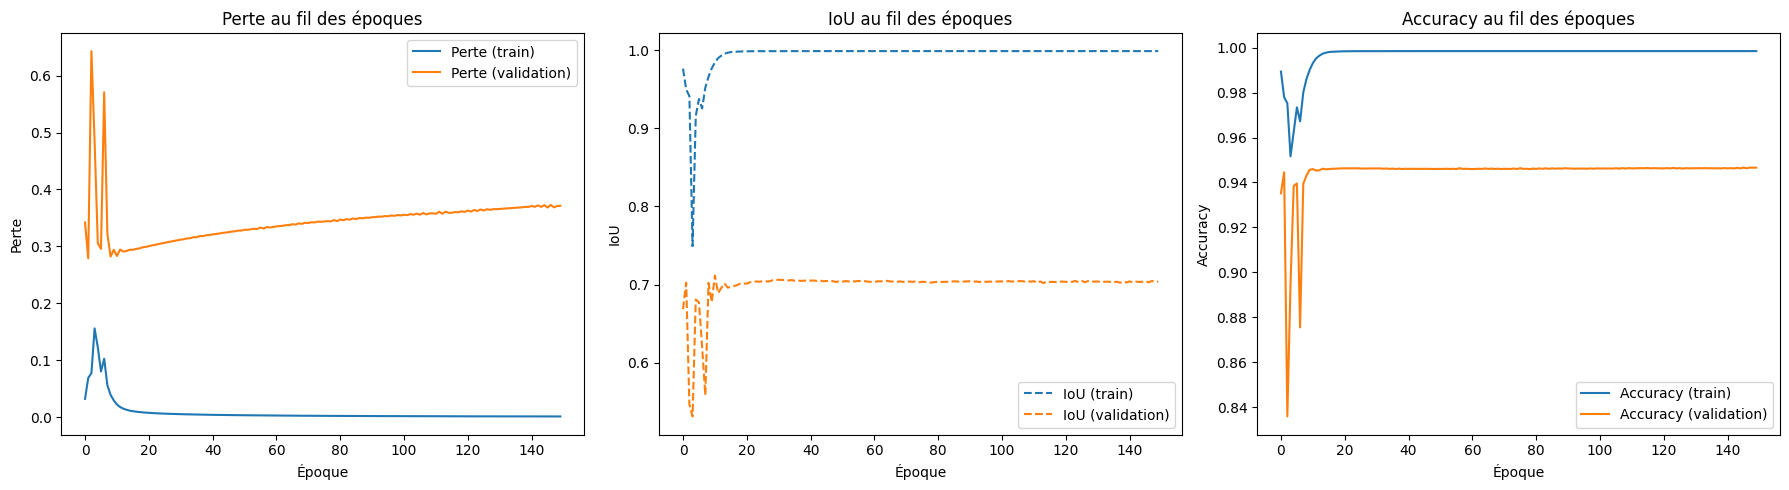

In [ ]:
plot_training_history(history)

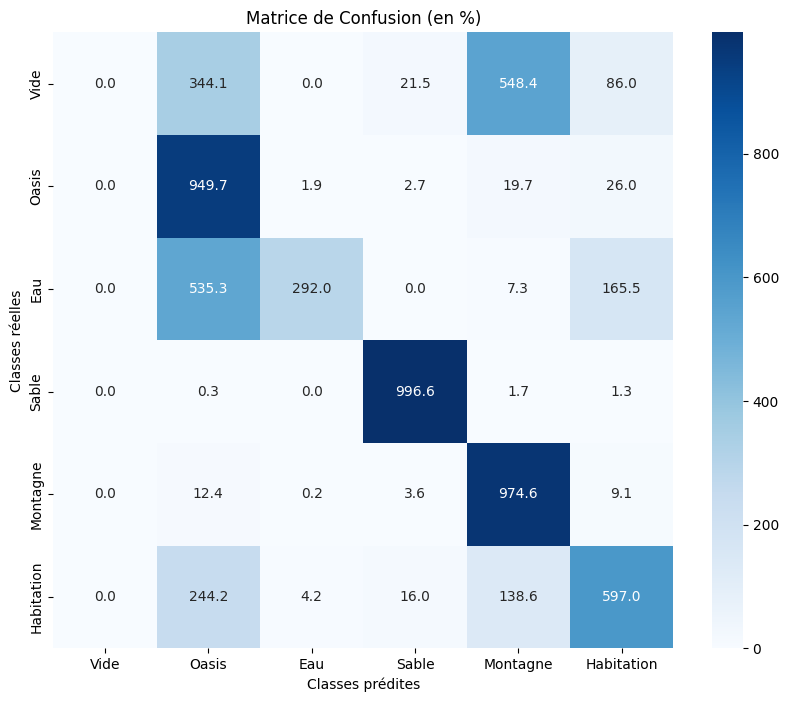

In [ ]:
def afficher_matrice_confusion_pourcentage(val_dataset, model, num_classes, class_names):
    """
    Affiche la matrice de confusion en pourcentage (échelle 0-100) pour un modèle UNet.

    :param val_dataset: Dataset de validation contenant des images et des masques.
    :param model: Modèle UNet pré-entraîné.
    :param num_classes: Nombre total de classes.
    :param class_names: Liste des noms des classes (pour l'affichage).
    """
    y_true = []
    y_pred = []

    for x_batch, y_batch in val_dataset:
        for image, true_mask in zip(x_batch, y_batch):
            # Ajouter une dimension pour le batch
            image = tf.expand_dims(image, axis=0)

            # Obtenir la prédiction
            prediction = model.predict(image, verbose=0)
            predicted_mask = np.argmax(prediction, axis=-1).squeeze()  # Classes prédites

            # Ajouter les valeurs à la liste
            y_true.extend(true_mask.numpy().flatten())  # Masque réel aplati
            y_pred.extend(predicted_mask.flatten())    # Masque prédit aplati

    # Calculer la matrice de confusion
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

    # Normaliser la matrice (ligne par ligne) et convertir en pourcentage
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_percentage = np.nan_to_num(cm_normalized * 1000)  # En pourcentage, gérer les NaN

    # Affichage de la matrice en pourcentage avec seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_percentage, annot=True, fmt=".1f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, cbar=True
    )
    plt.xlabel("Classes prédites")
    plt.ylabel("Classes réelles")
    plt.title("Matrice de Confusion (en %)")
    plt.show()




afficher_matrice_confusion_pourcentage(val_dataset, unet,6,['Vide', 'Oasis', 'Eau', 'Sable', 'Montagne', 'Habitation'])


##PREDICTION ET VISUALISATION

Prediction sur le dataset de validation

In [ ]:
def afficher_predictions(val_dataset, model, bands):
    """
    Affiche les prédictions d'un modèle UNet pour l'ensemble de validation

    """
    for x_batch, y_batch in val_dataset:  # Prendre un batch du dataset
        for image, true_mask in zip(x_batch, y_batch):
            # Vérifier que l'image a la bonne forme
            if image.shape[-1] == 7:  # S'assurer que l'image a 7 bandes
                # Étape 1 : Prédiction avec le modèle UNet
                image = tf.expand_dims(image, axis=0)  # Ajouter une dimension pour le batch
                prediction = model.predict(image)  # Prédiction
                plan_occupation = np.argmax(prediction, axis=-1)  # Obtenir les classes prédites
                plan_occupation = np.squeeze(plan_occupation)  # Supprimer les dimensions inutiles
                true_mask = np.squeeze(true_mask.numpy())  # S'assurer que le masque est dans le bon format

                # Étape 2 : Afficher l'image d'entrée, le masque réel et le plan d'occupation
                plt.figure(figsize=(18, 6))

                # Affichage de l'image d'entrée (sélectionner les bandes spécifiques)
                img_rgb = image[0, :, :, :].numpy()[:, :, bands]  # Sélectionner les 3 bandes pour l'affichage
                img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())  # Normaliser pour [0, 1]

                plt.subplot(1, 3, 1)
                plt.imshow(img_rgb)  # Afficher l'image d'entrée
                plt.title('Image d\'entrée')
                plt.axis('off')

                # Affichage du masque réel
                plt.subplot(1, 3, 2)
                im_true = plt.imshow(true_mask, cmap=cmap, vmin=0, vmax=vmax)  # Afficher le masque réel
                plt.title('Masque Réel')
                plt.axis('off')

                # Affichage du plan d'occupation
                plt.subplot(1, 3, 3)
                im_pred = plt.imshow(plan_occupation, cmap=cmap, vmin=0, vmax=vmax)  # Afficher la carte de prédiction
                plt.title('Prédictions de plan d\'occupation')
                plt.axis('off')

                # Ajouter une barre de couleurs pour voir les classes dans les labels
                cbar = plt.colorbar(im_pred, ax=plt.gca(), ticks=ticks)
                cbar.ax.set_yticklabels(echelle)

                plt.tight_layout()
                plt.show()

In [ ]:
bands = (4,3,5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


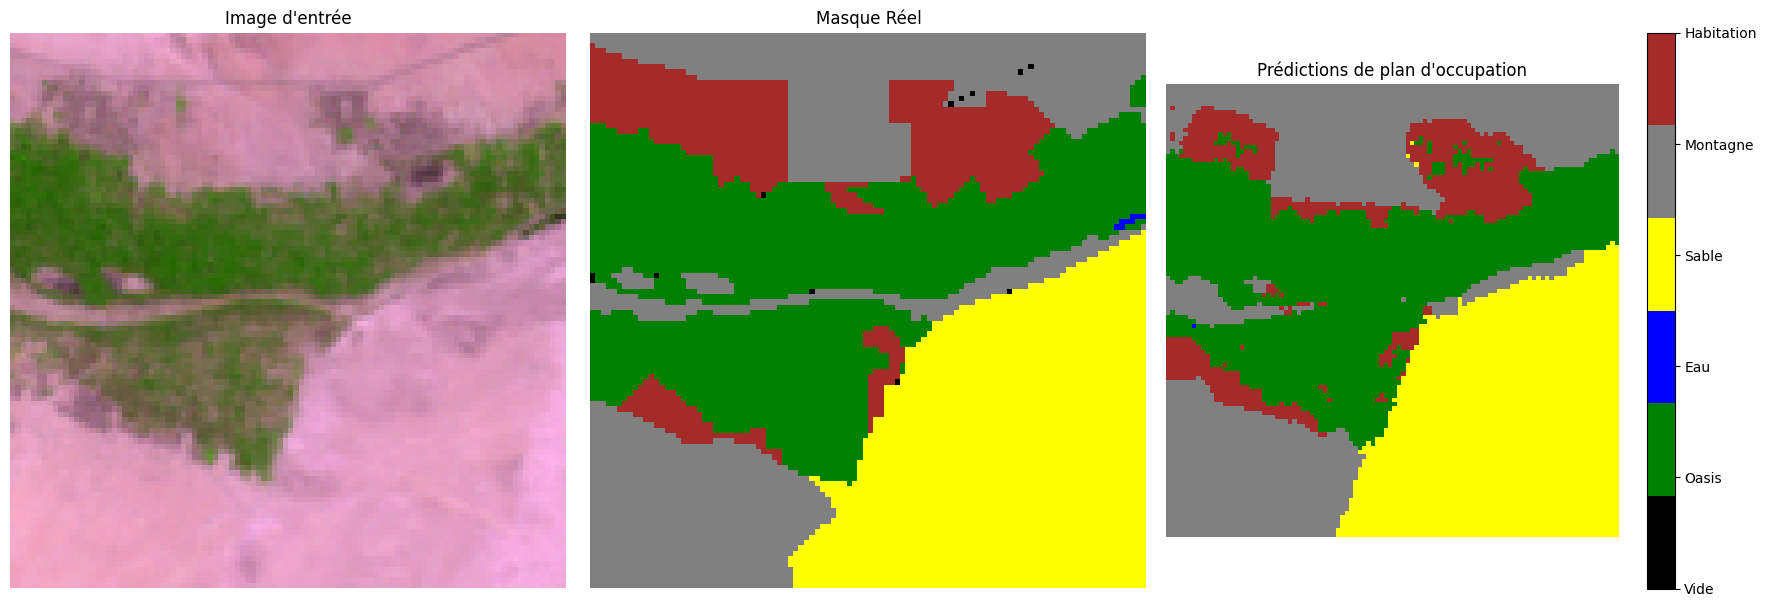

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


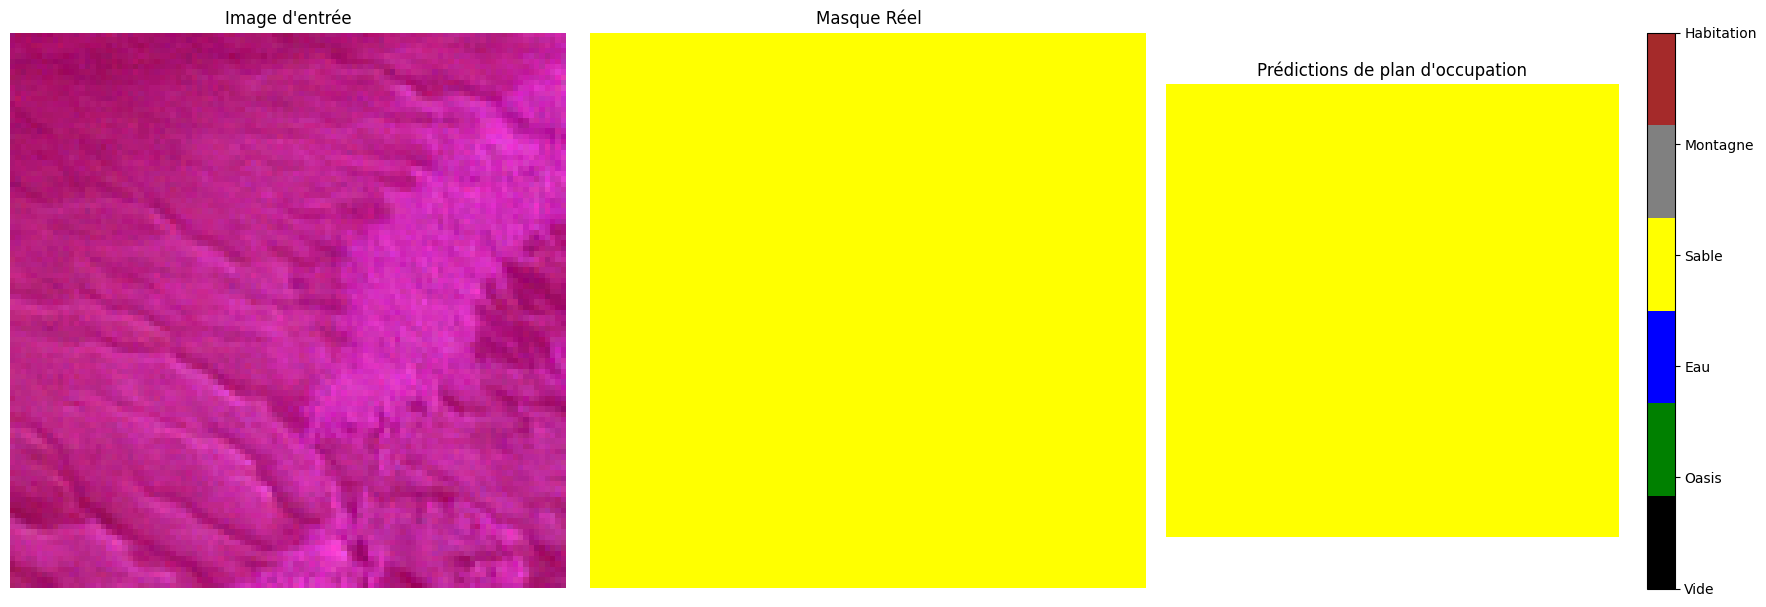

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


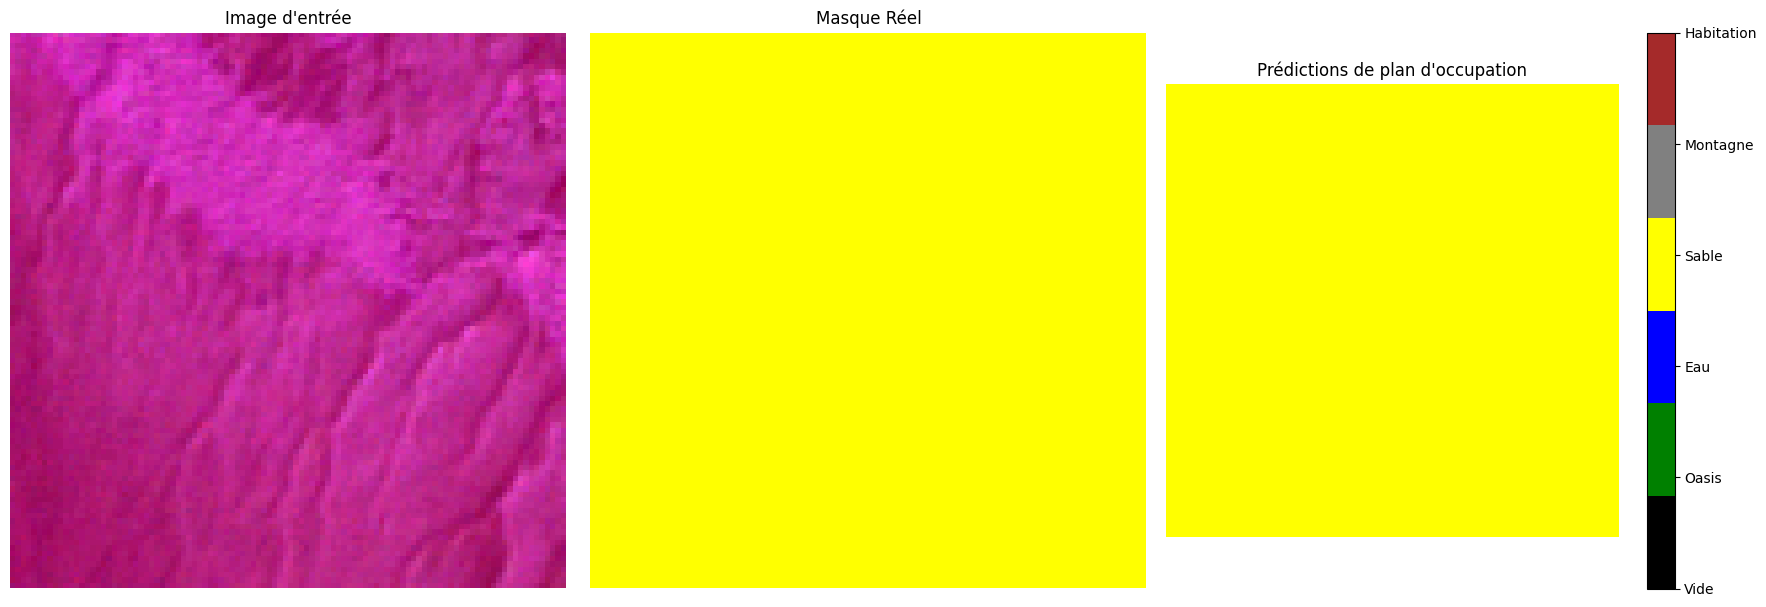

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


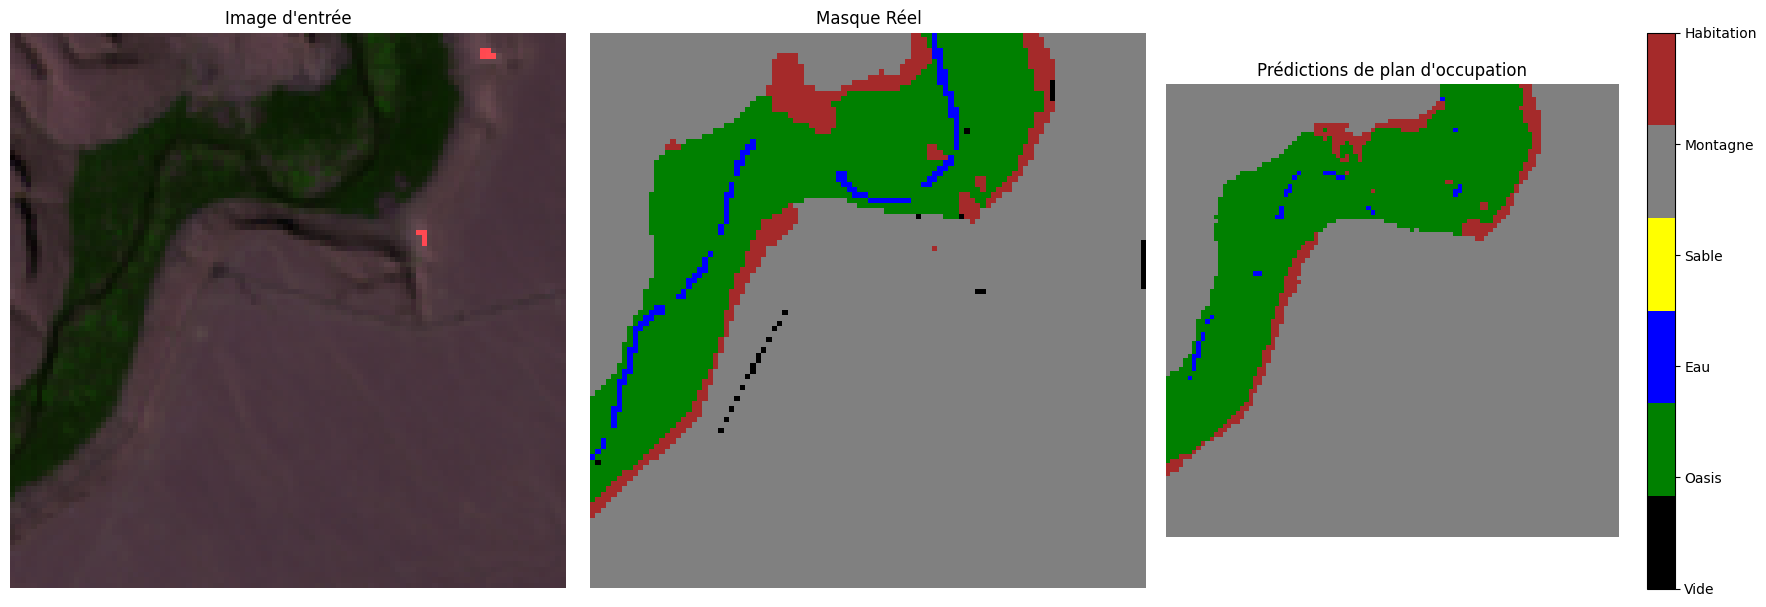

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


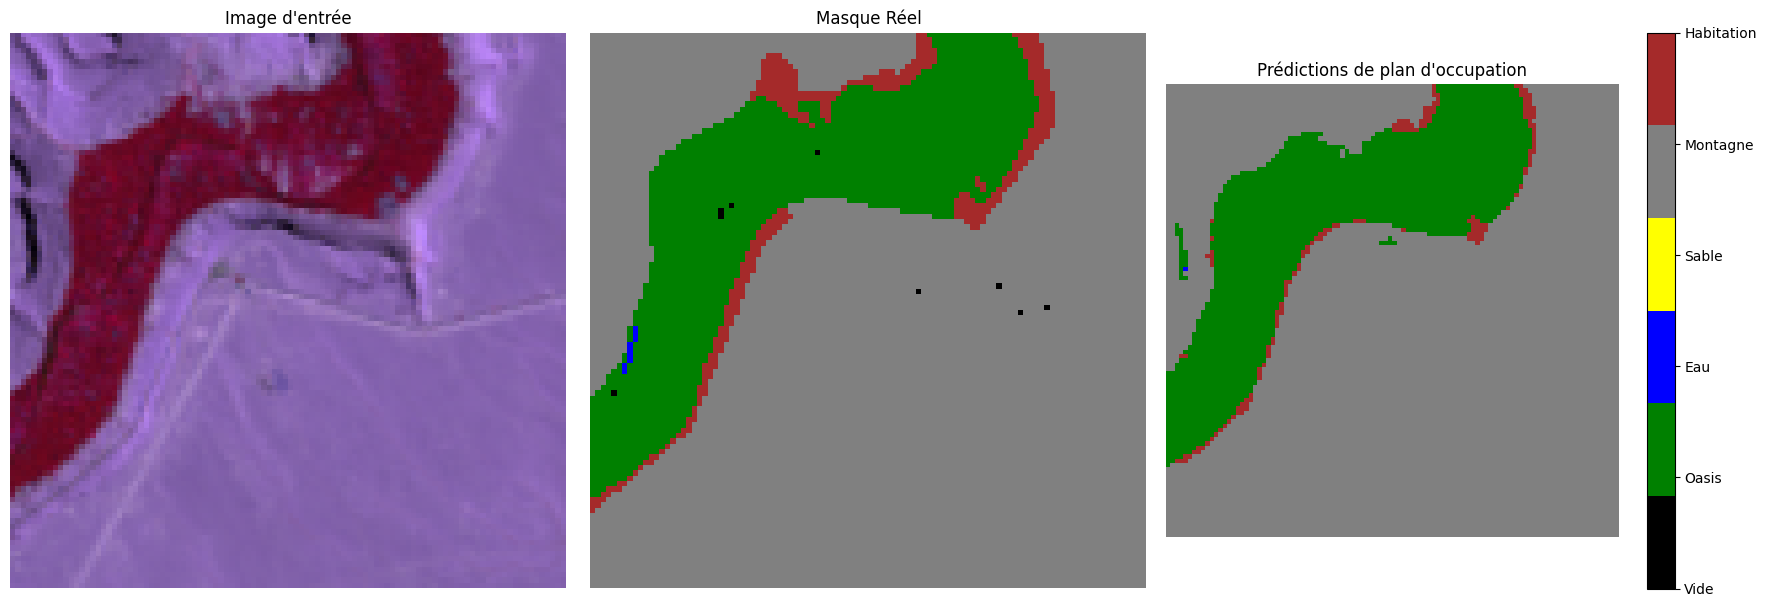

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


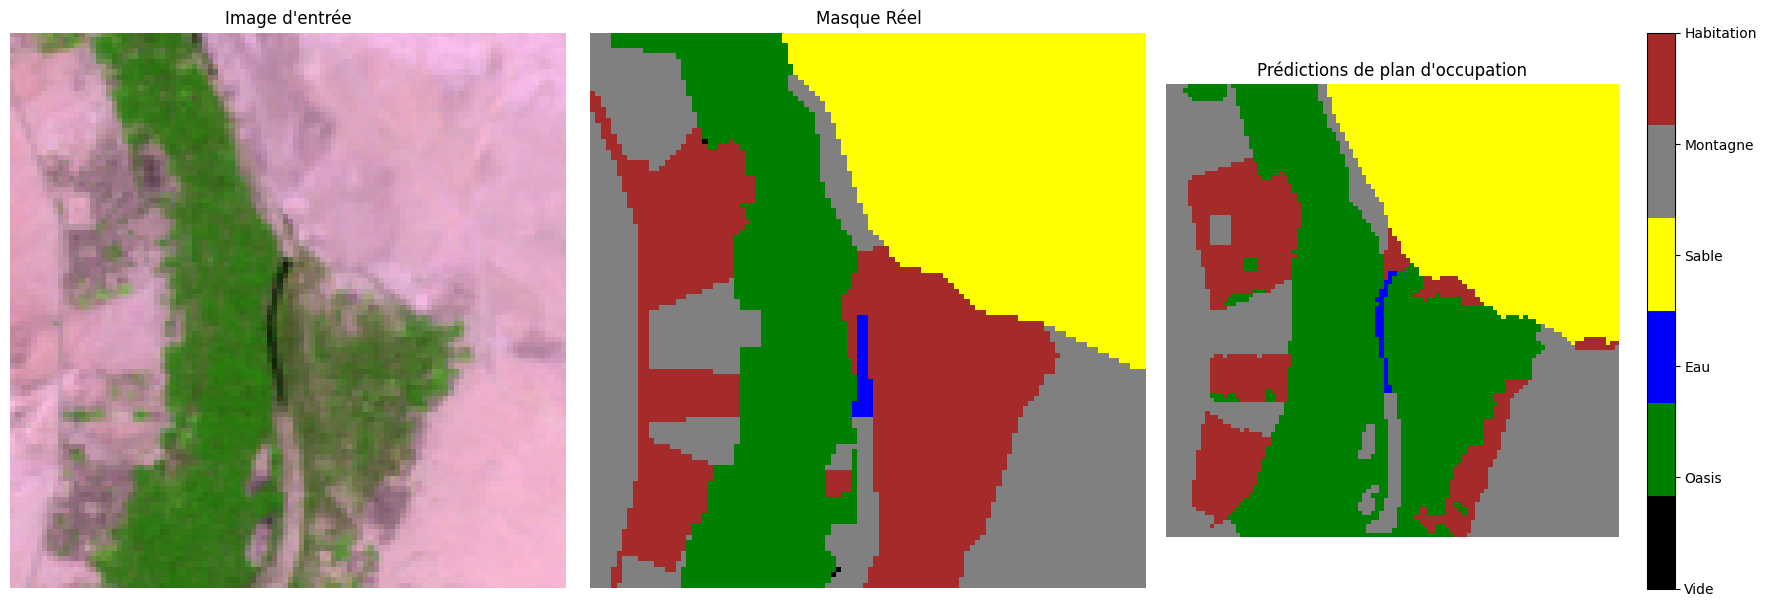

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


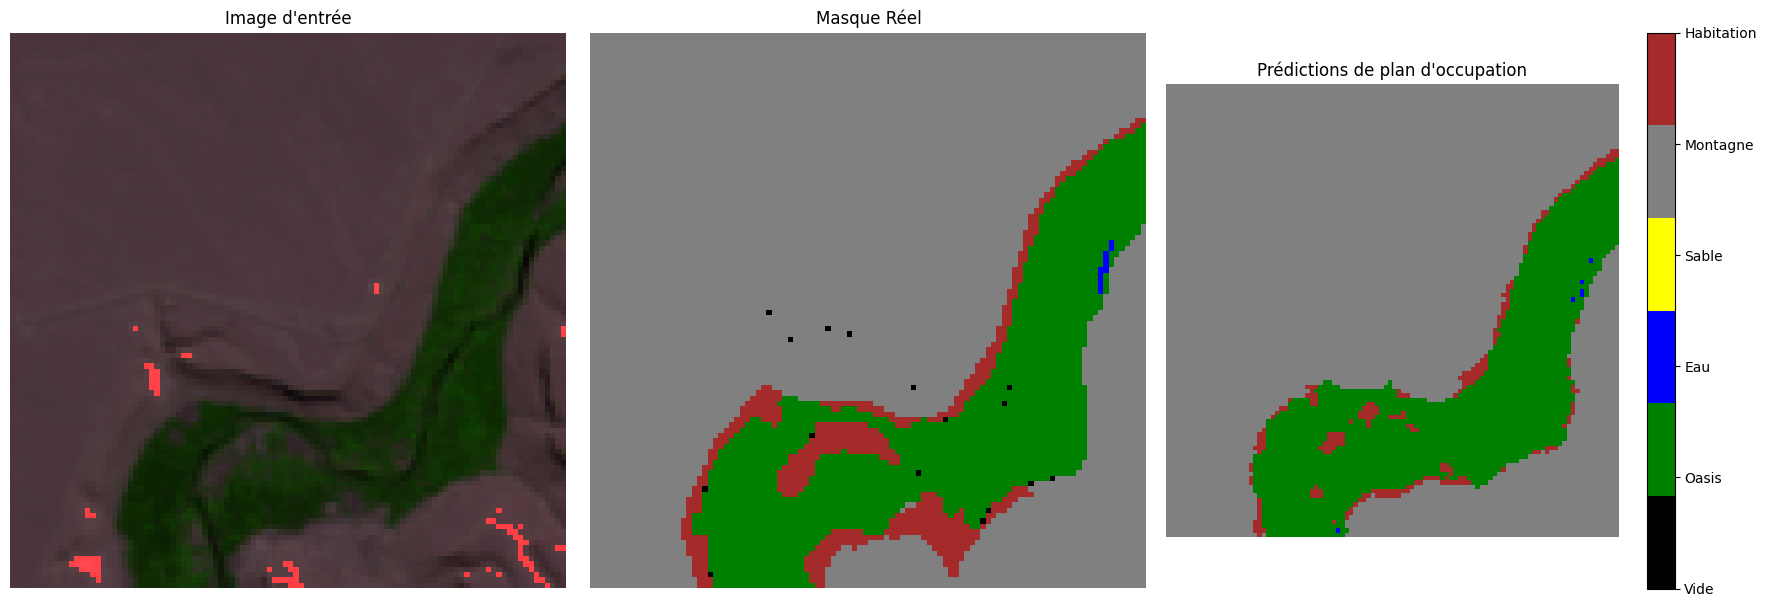

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


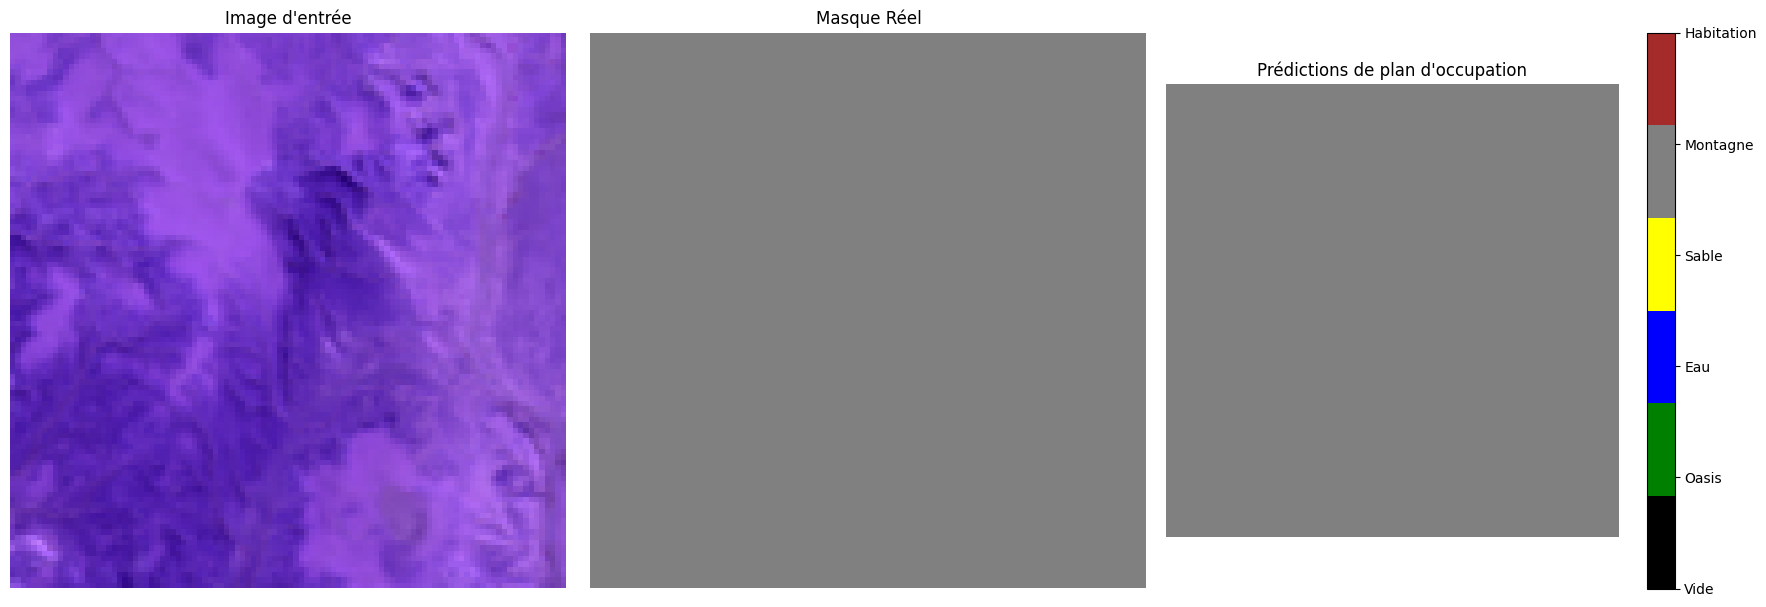

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


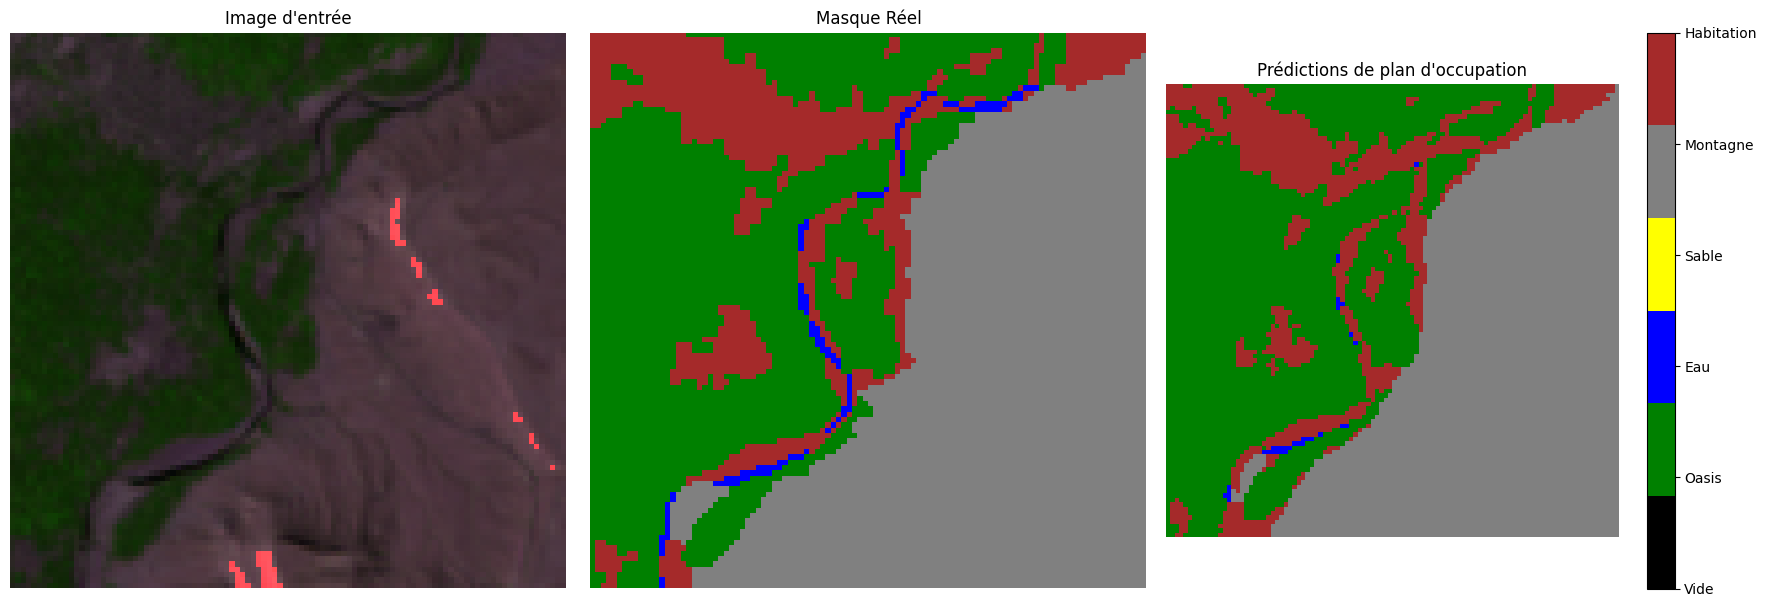

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


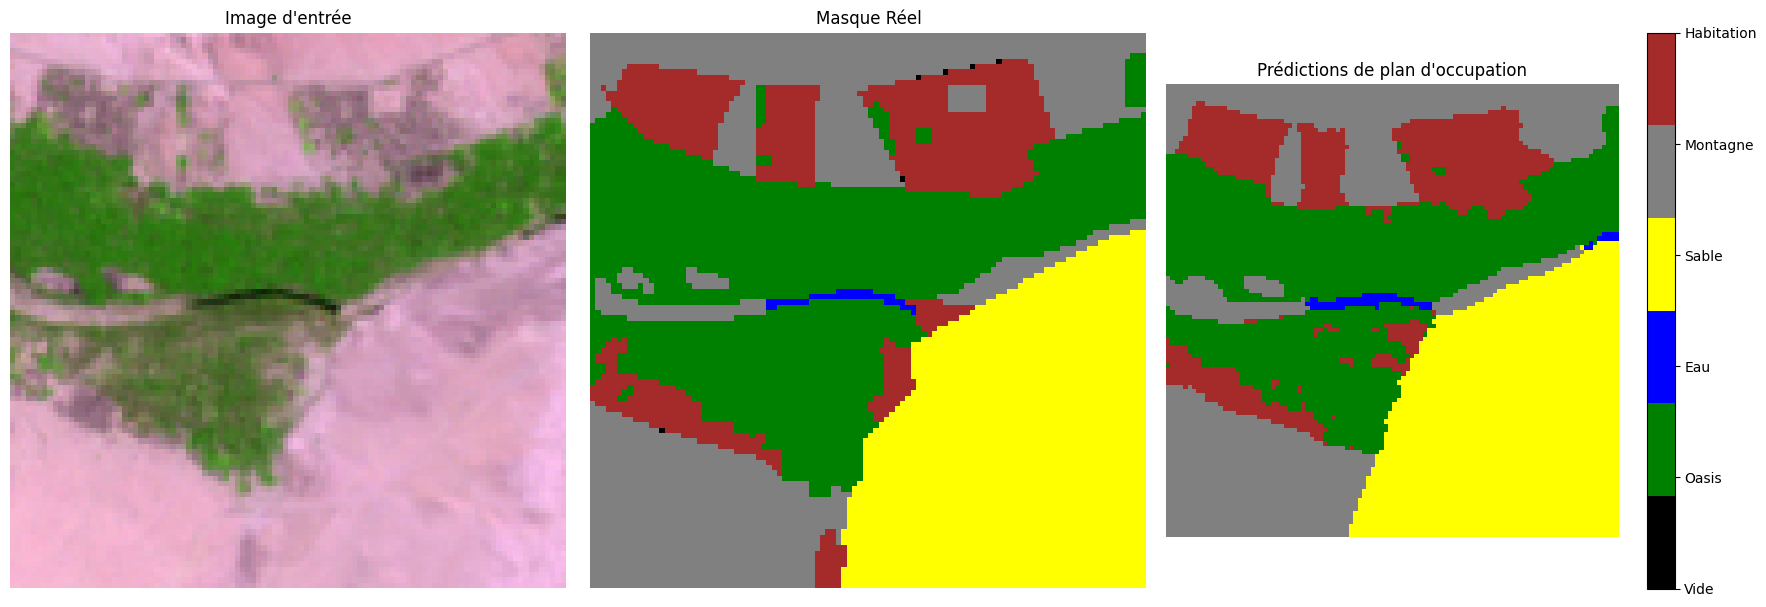

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


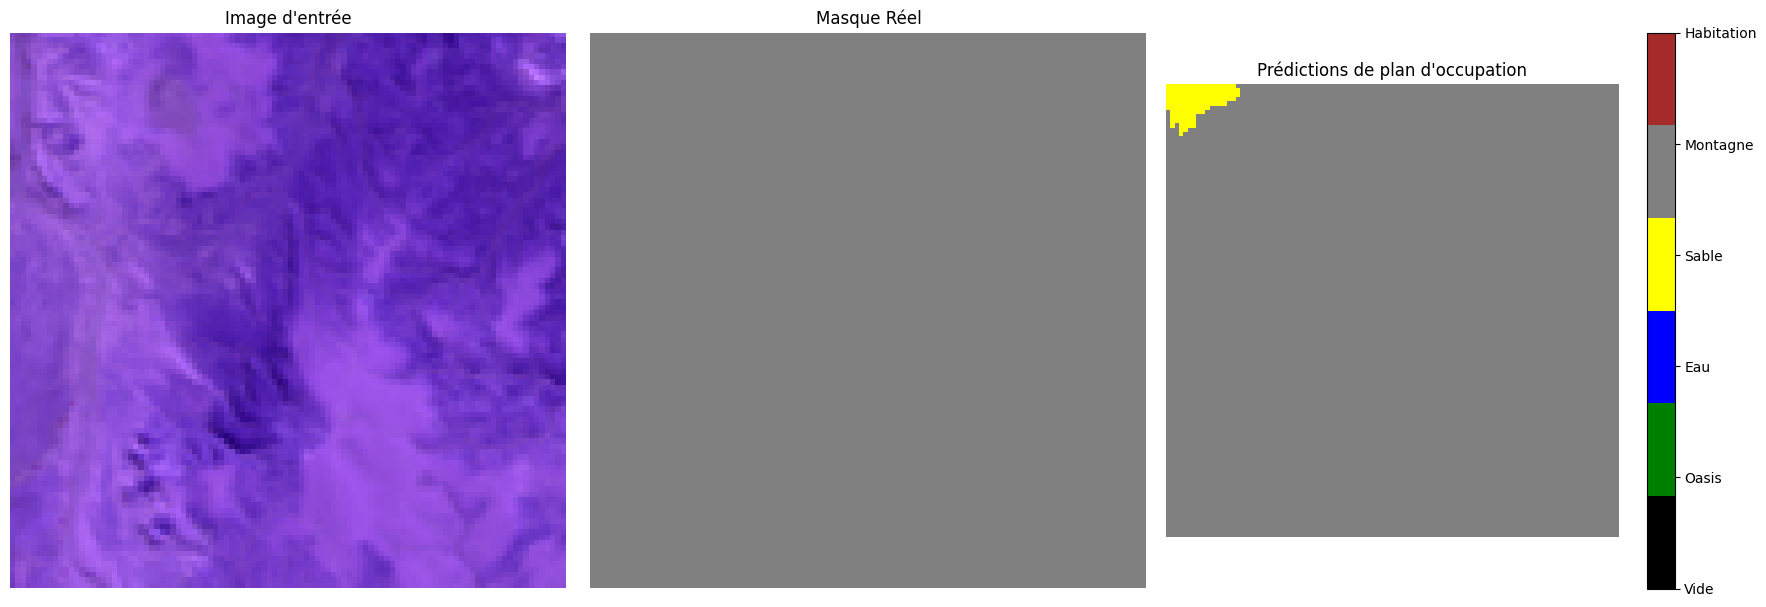

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


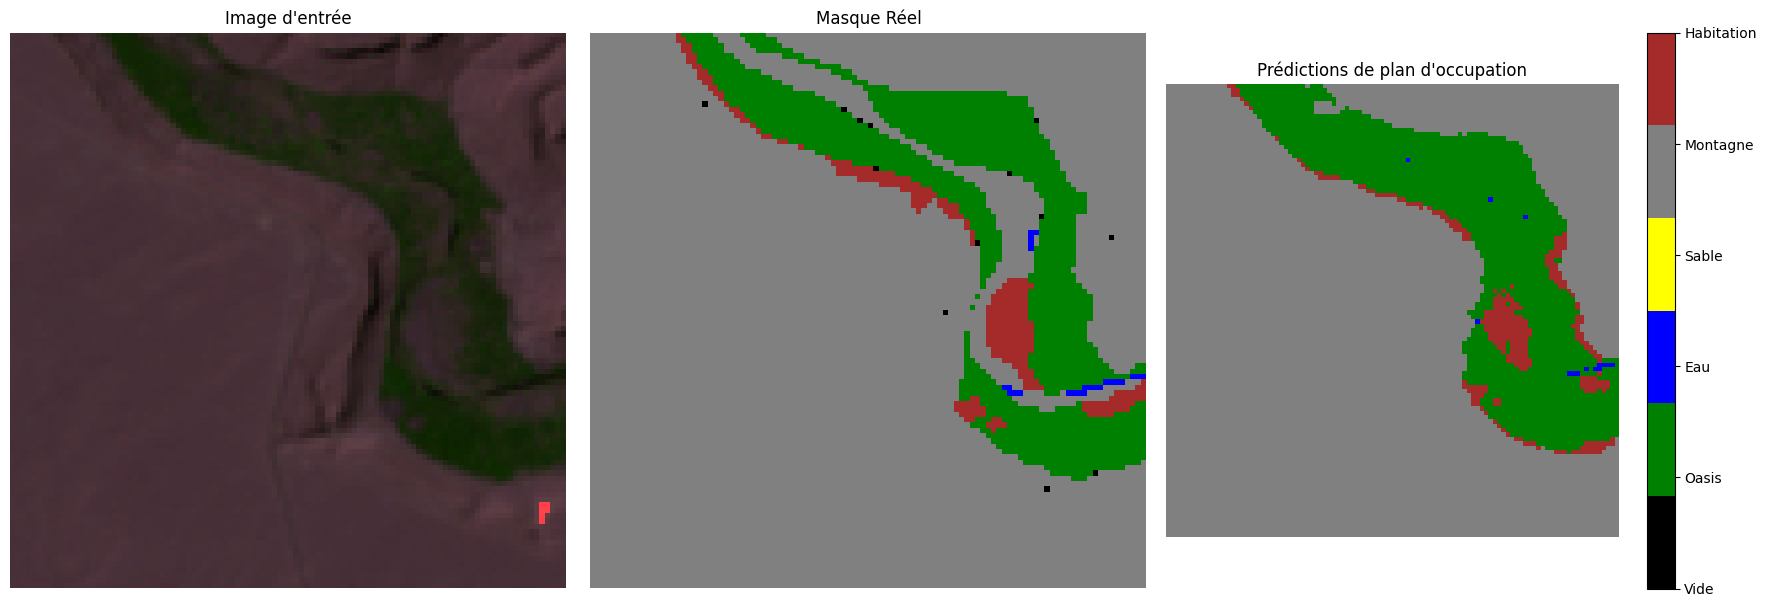

In [ ]:
afficher_predictions(val_dataset, unet,bands)

##PREDICTION SUR UNE IMAGE COMPLETE

In [ ]:
path_out = [os.path.join('..', 'data', 'image_prediction_final_unet.tif')]

with rasterio.open(path_out) as src:
  image = src.read()
image.shape

(7, 1034, 904)

### Transformation de l'image et découpage en plusieurs petites images au format de celles d'entrainement du modele

In [ ]:
height, width = image.shape[1], image.shape[2]
div = 104
pad_height = (div - height % div) % div
pad_width = (div - width % div) % div
padding_height = (pad_height // 2, pad_height - pad_height // 2)
padding_width = (pad_width // 2, pad_width - pad_width // 2)
stacked_bands_padded = np.pad(image, [(0, 0), (padding_height[0], padding_height[1]), (padding_width[0], padding_width[1])], mode='edge')
stacked_bands_padded.shape
height_new, width_new = stacked_bands_padded.shape[1], stacked_bands_padded.shape[2]
print(height_new, width_new)

1040 936


In [ ]:
def split_multiband_image_into_tiles(image, tile_size=104):
    # Extraire les dimensions de l'image
    bands, height, width = image.shape

    # Liste pour stocker les sous-images de 104x104 pour les 7 bandes
    tiles = []

    # Parcourir l'image en hauteur et largeur par intervalles de tile_size
    for i in range(0, height, tile_size):
        for j in range(0, width, tile_size):
            # Découper une sous-image de 104x104 pour toutes les bandes
            tile = image[:, i:i+tile_size, j:j+tile_size]
            # Ajouter la sous-image à la liste seulement si elle est exactement 104x104
            if tile.shape[1] == tile_size and tile.shape[2] == tile_size:
                tiles.append(tile)

    return tiles

# Exemple d'utilisation
tiles = split_multiband_image_into_tiles(stacked_bands_padded)

# Vérification
print("Nombre de sous-images découpées :", len(tiles))
print("Dimensions d'une sous-image (bands, height, width) :", tiles[0].shape if tiles else "Aucune sous-image")


Nombre de sous-images découpées : 90
Dimensions d'une sous-image (bands, height, width) : (7, 104, 104)


In [ ]:
def predict_on_tile(tile, model):
    tile_input = np.transpose(tile,(1,2,0))
    tile_input = np.expand_dims(tile_input, axis=0)

    # Normalization using mean and standard deviation
    '''mean = np.mean(tile_input)
    std = np.std(tile_input)
    tile_input = (tile_input - mean) / std  # Center and reduce the data'''
    tile_input = normalisation(tile_input)

    print("normaliser", tile_input.shape) # Print the shape after normalization

    prediction = model.predict(tile_input)
    prediction = prediction.squeeze() # Remove unnecessary dimensions

    return prediction

In [ ]:
# Dimensions de l'image d'origine après padding
tile_size = 104

# Créer un tableau pour stocker l'image reconstruite
reconstructed_image = np.zeros((height_new, width_new))

# Initialiser la position de la sous-image dans la liste `tiles`
index = 0
image_cut = []
label_cut = []

# Parcourir la hauteur et la largeur par intervalles de `tile_size`
for i in range(0, height_new, tile_size):
    for j in range(0, width_new, tile_size):
        # Récupérer la prédiction de la sous-image courante
        tile_prediction = predict_on_tile(tiles[index], unet)
        print('prediction N°',index,'/',len(tiles))
        tile_prediction = np.argmax(tile_prediction, axis=-1)  # Obtenir les classes prédites
        tile_prediction=tile_prediction.squeeze()
        image_cut.append(tiles[index])
        label_cut.append(tile_prediction)
        print(tile_prediction.shape)
        # Placer la prédiction à la bonne position dans l'image reconstruite
        reconstructed_image[ i:i+tile_size, j:j+tile_size] = tile_prediction # Suppression de la dimension lot si ajoutée

        # Passer à la sous-image suivante
        index += 1

# Vérification des dimensions de l'image reconstruite
print("Dimensions de l'image reconstruite :", reconstructed_image.shape)


normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
prediction N° 0 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction N° 1 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
prediction N° 2 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
prediction N° 3 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
prediction N° 4 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
prediction N° 5 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
prediction N° 6 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction N° 7 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
prediction N° 8 / 90
(104, 104)
normaliser (1, 104, 104, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
prediction N° 9 / 90
(104, 104)
normaliser (1, 104, 

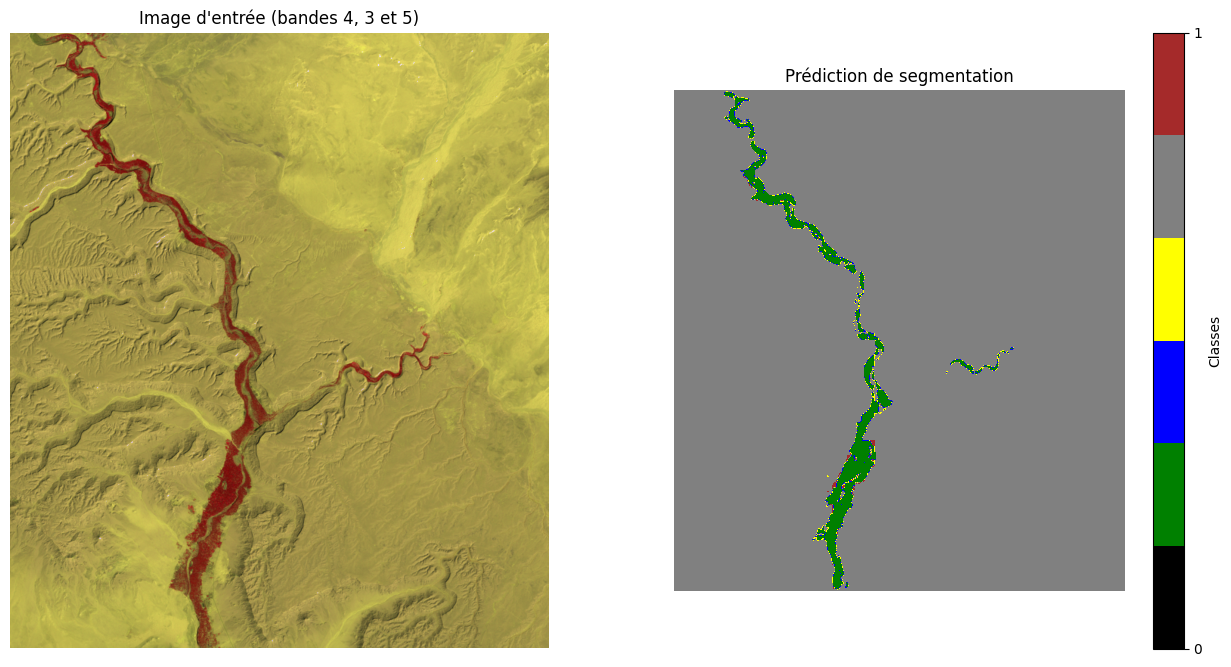

In [ ]:
# Charger l'image et sélectionner les canaux spécifiés
with rasterio.open(path_out) as src:
    # Lire les bandes spécifiées par bands_list
    image = src.read(list(bands))  # Lire les bandes spécifiées dans la liste

# Transposer l'image pour avoir la forme (hauteur, largeur, canaux)
image = np.transpose(image, (1, 2, 0))  # Permuter les dimensions pour (hauteur, largeur, 3)

# Normaliser chaque bande individuellement selon son propre maximum
image_normalized = np.zeros_like(image, dtype=np.float32)

# Parcourir chaque bande et normaliser
for i in range(image.shape[-1]):  # pour chaque bande
    image_normalized[:, :, i] = (image[:, :, i] - image[:, :, i].min()) / (image[:, :, i].max() - image[:, :, i].min())

# Affichage de l'image d'entrée normalisée
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Afficher l'image d'entrée en RGB (avec bandes 4, 3, 5)
axes[0].imshow(image_normalized)  # Affichage de l'image d'entrée avec la normalisation appliquée
axes[0].set_title("Image d'entrée (bandes 4, 3 et 5)")
axes[0].axis('off')

# Afficher l'image reconstruite avec la colormap des classes
axes[1].imshow(reconstructed_image, cmap=cmap, vmin=0, vmax=vmax)  # Affichage de la prédiction
axes[1].set_title("Prédiction de segmentation")
axes[1].axis('off')

# Ajouter une barre de couleurs pour la segmentation
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes[1], ticks=ticks, label='Classes')

plt.show()

In [ ]:
# Enregistrer le modèle
unet.save('/content/drive/MyDrive/projets/projet IA/UNET_PERSONNALISE.keras', save_format="keras")